<style>
.cours-hero {padding: 1.15rem 1.3rem; border-left: 6px solid #1f4e79; background: #f3f7fb; margin: .5rem 0 1rem 0;}
.objectif {padding: .8rem 1rem; border-left: 5px solid #2f855a; background: #f2fbf6; margin: .7rem 0;}
.attention {padding: .8rem 1rem; border-left: 5px solid #b7791f; background: #fffaf0; margin: .7rem 0;}
.oral {padding: .8rem 1rem; border-left: 5px solid #6b46c1; background: #faf5ff; margin: .7rem 0;}
.exercice {padding: .8rem 1rem; border-left: 5px solid #c53030; background: #fff5f5; margin: .7rem 0;}
.petit {font-size: .92em; color: #4a5568;}
</style>

<div class="cours-hero">

# Carnet d’apprentissage — Inférence causale

**Projet étudié :** effet d’une session durant le weekend, plutôt qu’en semaine, sur la probabilité de transaction  
**Finalité :** comprendre le projet en profondeur, l’expliquer clairement et le défendre lorsque les questions sortent du script

</div>

**Édition progressive :** étape 9  
**Bloc actuellement ouvert :** module 10 — présentation complète et défense orale  
**Prochain bloc prévu :** simulations de jury et révisions ciblées

> Ce notebook est un espace d’apprentissage. Il ne modifie pas le projet déjà soumis.


## Comment travailler avec ce carnet

Ce cours n’est pas destiné à être seulement lu. Pour chaque notion, nous suivrons le même cycle :

1. **Comprendre sans jargon.** Construire une image mentale correcte.
2. **Relier au projet.** Identifier la variable, le chiffre, la figure ou le choix méthodologique concerné.
3. **Récupérer de mémoire.** Fermer les notes et répondre avec ses propres mots.
4. **Défendre oralement.** Répondre en 20 secondes, puis en 60 secondes si le jury insiste.
5. **Corriger précisément.** Distinguer une imprécision de vocabulaire d’une véritable erreur de raisonnement.

### Structure recommandée pour une réponse de soutenance

<div class="oral">

**Définition simple → Application au projet → Chiffre ou élément concret → Limite**

Cette structure sera abrégée **D–A–C–L** dans le carnet.

</div>

### Échelle personnelle de maîtrise

| Niveau | Ce que je suis capable de faire |
|---:|---|
| 0 | Je ne reconnais pas encore la notion. |
| 1 | Je la reconnais lorsqu’on me l’explique. |
| 2 | Je peux la définir avec mes mots. |
| 3 | Je peux l’appliquer correctement au projet. |
| 4 | Je peux la défendre face à une objection imprévue. |

**Règle importante :** une notion n’est pas maîtrisée parce qu’une explication « paraît claire ». Elle est maîtrisée lorsqu’on peut la reconstruire sans regarder.

### Rappel Jupyter pour débuter

- Cliquer dans une cellule puis utiliser **Maj + Entrée** pour l’exécuter et passer à la suivante.
- Le symbole `[*]` signifie qu’une cellule est en cours d’exécution ; un nombre comme `[3]` indique qu’elle est terminée.
- Exécuter les cellules dans l’ordre. Si les résultats deviennent incohérents : **Kernel → Restart Kernel and Run All Cells**.
- Les cellules intitulées « ✍️ Ma réponse » sont des cellules Markdown : double-cliquer pour écrire, puis **Maj + Entrée** pour afficher proprement le texte.


## Carte complète du parcours

| Module | Question centrale | État |
|---:|---|---|
| 0 | Quelle histoire générale raconte le projet ? | Socle acquis — à réviser |
| 1 | Comment lire correctement les taux, différences et intervalles ? | Consolidation espacée |
| 2 | Quelle quantité causale voulons-nous réellement estimer ? | Socle initial — niveau 2/4 |
| 3 | Comment distinguer confondeur, médiateur, collider et variable post-exposition ? | Socle corrigé — rappel actif |
| 4 | Que représentent le DAG, la porte arrière et les hypothèses d’identification ? | Socle initial — niveau 2/4 |
| 5 | Pourquoi restreindre à `SpecialDay=0` et comment comprendre la positivité ? | Correction ciblée — à mémoriser |
| 6 | Comment fonctionnent la standardisation, l’IPW, l’AIPW et le cross-fitting ? | Cours lu — exercice à faire |
| 7 | Comment interpréter score de propension, poids, ESS et SMD ? | Correction SMD lue — rappel actif |
| 8 | Que font FCI et le PAG, et que ne prouvent-ils pas ? | Première tentative — niveau 1,5/4 |
| 9 | Comment défendre résultats, robustesse, E-value, limites et reproductibilité ? | Exercice en cours |
| 10 | Comment présenter chaque diapositive et répondre au contre-interrogatoire ? | **À travailler maintenant** |

<div class="attention">

Les modules sont développés progressivement. En mode accéléré, les points encore fragiles restent visibles et sont repris par de courts rappels, sans bloquer toute la progression.

</div>


## Tableau de progression

À mettre à jour après chaque séance.

| Date | Module | Niveau avant | Niveau après | Point encore fragile | Prochaine action |
|---|---:|---:|---:|---|---|
| _À remplir_ | 0–1 | 0 | _/4_ | _À remplir_ | Répondre aux exercices sans notes |

### Nombres d’ancrage à connaître à la fin du parcours

`12 330` · `11 079` · `8 371 / 2 708` · `18,06 / 16,03` · `+2,03` · `+1,51 [−0,18 ; 3,19]` · `0,268 → 0,040` · `E-value 1,41`

Ils seront appris progressivement avec leur **signification**, jamais comme une suite de nombres isolés.


# Module 0 — Comprendre l’histoire générale du projet

<div class="objectif">

**Objectif de maîtrise :** raconter en une minute ce que le projet cherche à faire, sans formules et sans le confondre avec un projet de prédiction.

**Prérequis :** aucun.

</div>


## Diagnostic initial — répondre avant le cours

Pour chaque affirmation, écrire **Vrai**, **Faux** ou **Je ne sais pas**, puis une justification d’une phrase. Le but n’est pas d’obtenir une bonne note : il s’agit de conserver une trace de ton intuition de départ.

1. Le fichier CSV contient un identifiant permettant de vérifier que chaque visiteur n’apparaît qu’une fois.
2. Selon la documentation UCI, le jeu a été construit de sorte que chaque session appartienne à un utilisateur différent pendant la période d’un an.
3. `Revenue` mesure le montant d’argent gagné pendant la session.
4. Comme le taux de transaction est plus élevé le weekend, le weekend cause davantage d’achats.
5. Une hausse de 1,5 point de pourcentage signifie toujours une hausse relative de 1,5 %.
6. Si un intervalle de confiance contient zéro, cela prouve que l’effet est exactement nul.
7. Pour supprimer les biais, il suffit d’ajuster sur toutes les variables qui prédisent bien `Revenue`.
8. L’AIPW élimine aussi la confusion causée par des variables qui ne figurent pas dans les données.
9. Si FCI ne place pas d’arête entre `Weekend` et `Revenue`, cela prouve l’absence d’effet causal.


### ✍️ Mes réponses au diagnostic

> Double-cliquer dans cette cellule pour la modifier. Ne pas effacer tes premières réponses après correction : ajoute plutôt une seconde formulation afin de voir ta progression.

| Nº | Vrai / Faux / ? | Ma justification initiale | Correction ultérieure |
|---:|---|---|---|
| 1 | _À remplir_ | _À remplir_ | |
| 2 | _À remplir_ | _À remplir_ | |
| 3 | _À remplir_ | _À remplir_ | |
| 4 | _À remplir_ | _À remplir_ | |
| 5 | _À remplir_ | _À remplir_ | |
| 6 | _À remplir_ | _À remplir_ | |
| 7 | _À remplir_ | _À remplir_ | |
| 8 | _À remplir_ | _À remplir_ | |
| 9 | _À remplir_ | _À remplir_ | |


<details>
<summary><strong>Corrigé du diagnostic — ouvrir après avoir répondu aux neuf affirmations</strong></summary>

1. **Faux.** Le CSV ne fournit aucun identifiant de visiteur.
2. **Vrai selon la provenance déclarée.** La documentation UCI indique que le jeu a été constitué avec une session par utilisateur distinct pendant l’année. Cette propriété vient de la documentation; elle n’est pas vérifiable directement dans le CSV anonymisé.
3. **Faux.** `Revenue` est un indicateur binaire de transaction, pas un montant.
4. **Faux.** Un taux plus élevé établit une association descriptive, pas sa cause.
5. **Faux.** Un point de pourcentage est une différence absolue; un pourcentage relatif utilise un taux de référence.
6. **Faux.** L’intervalle contenant zéro n’établit pas un effet exactement nul; il indique que zéro reste compatible avec les données et la procédure.
7. **Faux.** Le rôle temporel et causal d’une variable compte davantage que son pouvoir prédictif.
8. **Faux.** L’AIPW ne corrige pas un confondeur non mesuré.
9. **Faux.** Un PAG exploratoire sans adjacence ne prouve ni un ATE nul ni l’absence d’effet indirect.

</details>


## 0.1 Prédire n’est pas expliquer causalement

Deux questions peuvent utiliser les mêmes données tout en étant profondément différentes.

**Question prédictive**  
« À partir de ce que l’on observe pendant la navigation, quelles sessions termineront par une transaction ? »

**Question causale**  
« Pour des sessions comparables, que changerait le fait qu’elles aient lieu le weekend plutôt qu’en semaine ? »

Un excellent prédicteur n’est pas automatiquement une bonne variable d’ajustement causal. Par exemple, `PageValues` peut fortement prédire `Revenue`, mais elle est dérivée des valeurs des pages visitées et son statut temporel par rapport à la transaction courante est incertain. Elle est donc exclue conservativement de l’ajustement.

<div class="attention">

**Phrase à éviter :** « Le projet cherche à prédire si un client va acheter. »  
**Formulation correcte :** « Le projet cherche à estimer un contraste moyen de probabilité de transaction entre weekend et semaine, sous des hypothèses causales. »

</div>


## 0.2 Le fil narratif en six étapes

1. Nous observons une différence de taux de transaction entre weekend et semaine.
2. Les deux groupes n’ont pas été constitués par randomisation.
3. Nous formulons une comparaison hypothétique suffisamment précise.
4. Nous utilisons les connaissances du domaine et un DAG pour choisir les variables d’ajustement.
5. Nous estimons un contraste ajusté et examinons les diagnostics.
6. Nous concluons prudemment, car l’incertitude et les variables non observées demeurent.

Ce fil sera enrichi dans les modules suivants. Pour le moment, il faut surtout comprendre pourquoi l’étape 2 empêche de passer directement de l’observation à une conclusion causale.


## 0.3 Ouvrir les données sans se perdre dans le code

Les prochaines cellules servent à relier le cours au fichier réellement soumis. Il n’est pas encore nécessaire de comprendre chaque instruction Python.

**À observer lors de l’exécution :**

- le chemin du fichier utilisé ;
- ses dimensions ;
- l’absence d’identifiant de client ;
- la nature booléenne de `Weekend` et `Revenue`.


In [8]:
from pathlib import Path
import base64
import hashlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

NOM_DONNEES = Path("02_data/raw/online_shoppers_intention.csv")

def trouver_racine() -> Path:
    '''Trouver la racine du projet même si Jupyter a été lancé depuis un sous-dossier.'''
    candidats = [Path.cwd(), *Path.cwd().parents]
    for candidat in candidats:
        if (candidat / NOM_DONNEES).is_file():
            return candidat
    raise FileNotFoundError(
        "Impossible de trouver 02_data/raw/online_shoppers_intention.csv. "
        "Lancer Jupyter depuis le dossier rendu_final ou l'un de ses sous-dossiers."
    )

RACINE = trouver_racine()
CHEMIN_DONNEES = RACINE / NOM_DONNEES
CHEMIN_ESTIMATIONS = RACINE / "04_outputs/tableaux/02_estimations_principales.csv"

print(f"Racine détectée : {RACINE}")
print(f"Données utilisées : {CHEMIN_DONNEES}")


Racine détectée : c:\Users\Tazi\Desktop\School\PIF6004\projet_inference_causale_online_shoppers
Données utilisées : c:\Users\Tazi\Desktop\School\PIF6004\projet_inference_causale_online_shoppers\02_data\raw\online_shoppers_intention.csv


In [2]:
EMPREINTE_ATTENDUE = "b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9"
empreinte_observee = hashlib.sha256(CHEMIN_DONNEES.read_bytes()).hexdigest()
assert empreinte_observee == EMPREINTE_ATTENDUE, "Le fichier CSV n'est pas la copie validée."

donnees = pd.read_csv(CHEMIN_DONNEES)
assert donnees.shape == (12_330, 18)

print(f"Empreinte vérifiée : {empreinte_observee[:16]}…")
print(f"Dimensions : {donnees.shape[0]:,} sessions × {donnees.shape[1]} variables".replace(",", " "))
print(f"Colonnes : {', '.join(donnees.columns)}")


Empreinte vérifiée : b3055ee355f59134…
Dimensions : 12 330 sessions × 18 variables
Colonnes : Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend, Revenue


In [3]:
apercu_variables = pd.DataFrame(
    {
        "Variable": ["Weekend", "Revenue", "SpecialDay"],
        "Type Python": [str(donnees[c].dtype) for c in ["Weekend", "Revenue", "SpecialDay"]],
        "Interprétation": [
            "Exposition calendaire : weekend ou semaine",
            "Résultat binaire : transaction ou non",
            "Proximité d'un jour commercial spécial",
        ],
    }
)
display(apercu_variables)

colonnes_identifiantes = [
    c for c in donnees.columns
    if any(mot in c.casefold() for mot in ("client", "customer", "user", "session_id", "id_session"))
]
print("Colonnes pouvant identifier un client ou une session :", colonnes_identifiantes or "aucune")


,Variable,Type Python,Interprétation
0,Weekend,bool,Exposition calendaire : weekend ou semaine
1,Revenue,bool,Résultat binaire : transaction ou non
2,SpecialDay,float64,Proximité d'un jour commercial spécial


Colonnes pouvant identifier un client ou une session : aucune


### Ce que ces cellules permettent déjà d’affirmer

- Une ligne correspond à une **session observée**.
- Selon la [documentation UCI](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset), le jeu a été construit de sorte que chaque session appartienne à un utilisateur différent pendant l’année.
- Le CSV anonymisé ne contient toutefois aucun identifiant permettant de vérifier directement cette propriété.
- `Weekend` est l’exposition calendaire étudiée.
- `Revenue` indique si la session se termine par une transaction ; ce n’est pas un montant d’argent.
- Le titre original du jeu de données parle d’« intention d’achat », mais notre résultat analysé est bien une transaction binaire observée.

<div class="attention">

**Point à préciser dans la présentation finale :** la formule « une session = un utilisateur » résume la méthode de construction déclarée par UCI. À l’oral, la formulation rigoureuse sera : « l’unité d’analyse est la session; selon la documentation UCI, chaque session correspond à un utilisateur distinct pendant l’année, mais le CSV ne fournit pas d’identifiant permettant de le contrôler directement ». Nous reprendrons ce point lors du module 10.

</div>


## Exercice 0A — Reconstruire l’histoire sans notes

<div class="exercice">

Les six étapes suivantes ont été mélangées. Remets-les dans un ordre logique, puis raconte le projet à voix haute en **60 secondes maximum**.

- A. Estimer un contraste ajusté et vérifier les diagnostics.
- B. Constater que les groupes ne sont pas randomisés.
- C. Conclure prudemment à cause de l’incertitude et des causes absentes.
- D. Observer une différence de taux.
- E. Définir une comparaison hypothétique.
- F. Choisir les variables d’ajustement à partir d’un raisonnement causal.

Ne cherche pas encore à utiliser les mots *estimand*, *positivité* ou *AIPW*. Une histoire simple et correcte vaut mieux qu’un vocabulaire technique mal maîtrisé.

</div>


### ✍️ Ma réponse à l’exercice 0Ao

**Ordre proposé :** _F-B-E-A-D-C_  

**Mon explication écrite avant de la dire à voix haute : Je n'etait pas sur de ce qui etait demande et je suis honettement assez perdu donc j'y etais alle principalement au feeling**

_À remplir en cinq ou six phrases._

**Durée de ma réponse orale :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


<details>
<summary><strong>Corrigé de l’exercice 0A — ouvrir après la tentative orale</strong></summary>

Ordre logique : **D → B → E → F → A → C**.

- On part de l’écart descriptif.
- On reconnaît que les groupes n’ont pas été randomisés.
- On précise alors la comparaison hypothétique recherchée.
- On choisit l’ajustement à partir d’hypothèses causales.
- On estime et diagnostique.
- On termine par une conclusion proportionnée aux hypothèses et à l’incertitude.

Une autre narration peut être acceptable si elle conserve ces dépendances logiques et ne transforme pas l’association initiale en preuve causale.

</details>


## Point de passage du module 0

Avant de considérer ce module comme acquis, je dois pouvoir :

- [x] expliquer pourquoi le projet n’est pas principalement un projet de prédiction ;
- [x] dire qu’une ligne représente une session et non nécessairement un client ;
- [x] identifier `Weekend` et `Revenue` sans les confondre ;
- [x] raconter les six étapes générales en moins de 60 secondes ;
- [x] terminer ma réponse par une limite au lieu de suraffirmer la causalité.

**Niveau actuel estimé :** 2/4


# Module 1 — Proportions, points de pourcentage, association et incertitude

<div class="objectif">

**Objectif de maîtrise :** interpréter correctement les chiffres essentiels du projet et expliquer pourquoi une différence observée n’est pas automatiquement un effet causal.

**Prérequis :** savoir diviser deux nombres et calculer une différence.

</div>


## 1.1 Pourquoi la moyenne de `Revenue` est un taux de transaction

Notons $Y_i=Revenue_i$ l’indicateur associé à la session $i$. Il ne peut prendre que deux valeurs :

$$
Y_i =
\begin{cases}
1 & \text{si la session } i \text{ se termine par une transaction},\\
0 & \text{sinon.}
\end{cases}
$$

La somme de cette variable compte les transactions. Sa moyenne est donc :

$$
\bar{Y}=\frac{\text{nombre de transactions}}{\text{nombre de sessions}},
$$

c’est-à-dire une **proportion** ou un **risque observé**.


In [4]:
population_principale = donnees.loc[donnees["SpecialDay"].eq(0)].copy()

resume_observe = (
    population_principale
    .groupby("Weekend", observed=True)["Revenue"]
    .agg(Sessions="size", Transactions="sum", Taux="mean")
    .rename(index={False: "Semaine", True: "Weekend"})
)
resume_observe["Taux (%)"] = 100 * resume_observe["Taux"]
resume_observe = resume_observe[["Sessions", "Transactions", "Taux (%)"]]

display(
    resume_observe.style.format(
        {"Sessions": "{:,.0f}", "Transactions": "{:,.0f}", "Taux (%)": "{:.2f} %"}
    )
)
print(f"Taille de la population principale : {len(population_principale):,}".replace(",", " "))


,Sessions,Transactions,Taux (%)
Weekend,,,
Semaine,"8,371","1,342",16.03 %
Weekend,"2,708",489,18.06 %


Taille de la population principale : 11 079


Les calculs essentiels sont :

$$
\frac{489}{2708}=18{,}06\% \quad \text{(weekend)}
$$

$$
\frac{1342}{8371}=16{,}03\% \quad \text{(semaine)}
$$

Il s’agit de deux **taux observés** dans deux groupes différents. À ce stade, nous n’avons encore défini ni comparaison contrefactuelle, ni estimand, ni stratégie d’identification.


### Trois paires de taux à ne jamais mélanger

| Niveau d’analyse | Semaine | Weekend | Signification |
|---|---:|---:|---|
| Échantillon complet | 14,89 % | 17,40 % | Description des 12 330 sessions |
| Population `SpecialDay=0` | 16,03 % | 18,06 % | Description brute des 11 079 sessions principales |
| Moyennes de résultats potentiels estimées par AIPW | 16,16 % | 17,67 % | Résultats ajustés sous les hypothèses de l’analyse |

Les deux premières lignes sont des moyennes réellement observées dans des populations différentes. La troisième provient d’un estimateur interprétable causalement si les hypothèses d’identification sont valides; elle sera expliquée beaucoup plus tard. Lors d’une question orale, toujours annoncer **de quelle population et de quel type de moyenne il s’agit**.


## 1.2 Point de pourcentage et variation relative

Supposons qu’un taux passe de 16 % à 18 %.

- La différence absolue est de **2 points de pourcentage**.
- La variation relative est $(18-16)/16=12{,}5\%$.

Ce sont deux manières différentes de décrire le même écart. Il faut toujours annoncer l’échelle utilisée.

Dans le projet, la différence brute vaut environ :

$$
18{,}06\%-16{,}03\%=2{,}03\text{ points de pourcentage}.
$$

<div class="attention">

**Erreur fréquente :** « le weekend augmente les achats de 2,03 % ».  
Cette phrase mélange l’échelle, suppose déjà la causalité et ne précise pas la population.

</div>


In [5]:
risque_semaine = population_principale.loc[~population_principale["Weekend"], "Revenue"].mean()
risque_weekend = population_principale.loc[population_principale["Weekend"], "Revenue"].mean()

difference_points = 100 * (risque_weekend - risque_semaine)
variation_relative = 100 * (risque_weekend / risque_semaine - 1)
difference_pour_1000 = 1000 * (risque_weekend - risque_semaine)

print(f"Taux semaine : {100 * risque_semaine:.3f} %")
print(f"Taux weekend : {100 * risque_weekend:.3f} %")
print(f"Différence absolue : {difference_points:.3f} points de pourcentage")
print(f"Variation relative brute : {variation_relative:.2f} %")
print(f"Écart descriptif pour 1 000 sessions : {difference_pour_1000:.1f} transactions")


Taux semaine : 16.032 %
Taux weekend : 18.058 %
Différence absolue : 2.026 points de pourcentage
Variation relative brute : 12.64 %
Écart descriptif pour 1 000 sessions : 20.3 transactions


## 1.3 Une différence observée peut provenir de la composition des groupes

Imaginons un mécanisme fictif précis : une **campagne promotionnelle préexistante** pousse davantage d’utilisateurs à visiter durant le weekend et augmente aussi leur probabilité de transaction, tandis que le weekend lui-même n’a **aucun effet à campagne fixée**.

- sans promotion, le taux est toujours de 10 % ;
- avec promotion, le taux est toujours de 30 % ;
- la campagne crée davantage de sessions de weekend que de semaine.

La cellule suivante montre que le taux global du weekend peut alors être supérieur même si les taux sont identiques à l’intérieur de chaque niveau de promotion.


In [6]:
exemple_promotion = pd.DataFrame(
    [
        ["Semaine", "Sans promotion", 800, 80],
        ["Semaine", "Avec promotion", 200, 60],
        ["Weekend", "Sans promotion", 400, 40],
        ["Weekend", "Avec promotion", 600, 180],
    ],
    columns=["Moment", "Promotion", "Sessions", "Transactions"],
)
exemple_promotion["Taux (%)"] = 100 * exemple_promotion["Transactions"] / exemple_promotion["Sessions"]

taux_globaux = (
    exemple_promotion.groupby("Moment")[["Sessions", "Transactions"]]
    .sum()
    .assign(**{"Taux global (%)": lambda d: 100 * d["Transactions"] / d["Sessions"]})
)

display(exemple_promotion)
display(taux_globaux)
print("Dans chaque niveau de promotion : mêmes taux en semaine et le weekend.")
print("Au total : 14 % en semaine contre 22 % le weekend, soit +8 points.")


,Moment,Promotion,Sessions,Transactions,Taux (%)
0,Semaine,Sans promotion,800,80,10.000
1,Semaine,Avec promotion,200,60,30.000
2,Weekend,Sans promotion,400,40,10.000
3,Weekend,Avec promotion,600,180,30.000


,Sessions,Transactions,Taux global (%)
Moment,,,
Semaine,1000,140,14.000
Weekend,1000,220,22.000


Dans chaque niveau de promotion : mêmes taux en semaine et le weekend.
Au total : 14 % en semaine contre 22 % le weekend, soit +8 points.


### Le raisonnement important

Dans cette histoire fictive explicitement posée, la campagne est une **cause commune** du moment observé et de la transaction : `Campagne → Weekend` et `Campagne → Revenue`. La différence globale ne représente donc pas un effet du weekend.

Dans le vrai projet, les prix, promotions, campagnes et intentions préalables sont des causes communes non mesurées plausibles. Le produit consulté et l’heure exacte ont un statut temporel plus ambigu : ils pourraient faire partie du contexte pré-session, de la version précise de l’exposition ou de mécanismes postérieurs. Nous ne savons donc pas si ces facteurs expliquent une partie ou la totalité de l’écart observé.

> **Association :** les sessions de weekend ont un taux observé plus élevé.  
> **Causalité :** le déplacement hypothétique d’une session vers le weekend modifierait son résultat.

La première phrase compare des groupes réellement observés. La seconde compare deux situations hypothétiques et exige des hypothèses supplémentaires.


## 1.4 Comprendre un intervalle de confiance sans le surinterpréter

### 1. L’image mentale : une estimation centrale et une marge d’incertitude

Nous ne disposons que d’un nombre fini de sessions. Si nous répétions le même processus de collecte et d’analyse avec d’autres sessions comparables, nous n’obtiendrions pas exactement le même résultat.

- L’**estimation ponctuelle** est le nombre central produit par les données : notre meilleure estimation avec cette méthode.
- L’**intervalle de confiance** décrit la précision statistique autour de ce nombre. Un intervalle étroit indique davantage de précision qu’un intervalle large, toutes choses égales par ailleurs.

<div class="objectif">

**Image mentale :** le point est notre meilleure estimation; l’intervalle montre la marge d’incertitude statistique autour de ce point à cause de l’information limitée contenue dans l’échantillon.

L’intervalle concerne une **quantité moyenne**. Il ne décrit pas toutes les réactions individuelles des sessions.

</div>

### 2. Application exacte au projet

Dans la population principale `SpecialDay=0`, deux résultats doivent rester séparés :

| Résultat | Ce qui est comparé | Estimation | IC à 95 % | Zéro est-il inclus ? |
|---|---|---:|---:|---:|
| Différence **brute** | Les groupes weekend et semaine réellement observés | `+2,026` points | `[0,378 ; 3,674]` | Non |
| Estimation **AIPW principale** | Une différence weekend–semaine après ajustement | `+1,506` point | `[−0,176 ; 3,188]` | Oui |

La différence brute vient des taux observés de **18,06 % le weekend** et **16,03 % en semaine**. L’estimation AIPW n’est pas un troisième taux observé : c’est un **contraste ajusté**. Nous apprendrons son calcul au module 6.

Pour 1 000 sessions de la population cible, l’estimation AIPW se traduit ainsi, **si les hypothèses causales sont valides** :

- estimation centrale : environ **15 transactions supplémentaires pour 1 000 sessions**;
- borne basse : environ **2 transactions de moins pour 1 000**;
- borne haute : environ **32 transactions supplémentaires pour 1 000**.

Ce n’est pas la prédiction de ce qui arrivera exactement aux 1 000 prochaines sessions. C’est une traduction de la différence moyenne estimée.

### 3. Lire la notation et les trois nombres

L’écriture `+1,506 [−0,176 ; 3,188]` contient trois informations différentes :

- `+1,506` est l’**estimation ponctuelle**;
- `−0,176` est la **borne basse** de l’intervalle;
- `3,188` est la **borne haute** de l’intervalle.

Ici, la distance entre le point et chaque borne vaut environ `1,682` point :

- `1,506 − 1,682 ≈ −0,176`;
- `1,506 + 1,682 ≈ 3,188`.

Tu n’as pas encore besoin de savoir comment cette marge a été calculée. Pour interpréter l’intervalle, commence par repérer le point central, les deux bornes et la position de zéro.

### 4. Pourquoi la présence de zéro est importante

Une différence de zéro correspond à **aucune différence moyenne** entre les deux situations comparées.

- Si tout l’intervalle est supérieur à zéro, les données et la méthode indiquent une différence statistique positive. Cela ne prouve pas, à lui seul, une cause.
- Si l’intervalle traverse zéro, une absence de différence moyenne reste compatible avec les données. Des valeurs négatives et positives peuvent aussi rester compatibles.
- Si tout l’intervalle est inférieur à zéro, les données et la méthode indiquent une différence statistique négative.

Ainsi, l’intervalle AIPW contenant zéro **ne prouve pas que l’effet vaut exactement zéro**. Il signifie que les données ne permettent pas d’écarter cette possibilité. Inversement, l’intervalle brut excluant zéro montre une association statistique, pas automatiquement un effet causal.

### 5. Que signifie réellement « 95 % » ?

Imaginons que nous puissions répéter un grand nombre de fois le même processus de collecte et d’analyse. Chaque répétition donnerait un intervalle légèrement différent. Si la procédure statistique et ses hypothèses sont valides, environ **95 % de ces intervalles** couvriraient la vraie quantité moyenne ciblée.

> **Formulation prudente :** « L’intervalle regroupe les valeurs raisonnablement compatibles avec les données et la procédure d’estimation. »

**Il ne faut pas dire :** « Il y a 95 % de probabilité que le véritable effet soit dans cet intervalle. » Dans l’interprétation fréquentiste, une fois notre intervalle calculé, ses bornes sont fixes; le niveau de 95 % décrit la fiabilité de la procédure répétée.

### 6. Ce que l’intervalle mesure — et ce qu’il ne mesure pas

| Question | Exemple dans le projet | L’IC habituel la traite-t-il ? |
|---|---|---:|
| Le résultat varierait-il avec un autre échantillon ? | Nous n’avons qu’un nombre fini de sessions. | Oui, selon la méthode utilisée. |
| Des causes importantes sont-elles absentes des données ? | Prix, promotions ou intentions préalables pourraient manquer. | Non. |
| La comparaison causale et la population ont-elles été correctement définies ? | Choix des variables, restriction à `SpecialDay=0`, définition de `Weekend`. | Non. |

<div class="attention">

Un appareil mal calibré peut donner des mesures très stables mais systématiquement fausses. De même, un intervalle étroit peut entourer une estimation biaisée. **Précision statistique et validité causale ne sont pas la même chose.**

</div>

<details>
<summary><strong>Vocabulaire pour plus tard — inutile à mémoriser maintenant</strong></summary>

- **Confusion non mesurée :** des causes communes de `Weekend` et `Revenue` ne figurent pas dans les données.
- **DAG :** un schéma représentant nos hypothèses sur les relations causales.
- **Identification :** les conditions permettant de relier la question causale aux données observées.
- **Estimand :** la quantité précise que nous cherchons à estimer.

L’intervalle AIPW décrit principalement l’incertitude d’échantillonnage autour de la quantité estimée sous ces choix et hypothèses; il ne garantit pas que ces choix soient corrects.

</details>

### 7. Structure D–A–C–L pour une réponse orale

- **Définition simple :** expliquer que l’intervalle décrit l’incertitude statistique autour d’une estimation.
- **Application au projet :** préciser que l’on parle de l’estimation AIPW principale dans la population `SpecialDay=0`.
- **Chiffre concret :** donner `+1,506 [−0,176 ; 3,188]` points et signaler que zéro est inclus.
- **Limite :** ne pas conclure à un effet nul et rappeler que l’intervalle ne couvre pas les causes absentes des données.

**Questions pièges à reconnaître :**

1. « L’intervalle contient zéro, donc vous avez prouvé l’absence d’effet. »
2. « L’intervalle brut exclut zéro, donc le weekend cause davantage d’achats. »
3. « Votre intervalle contient le véritable effet avec 95 % de probabilité. »


## Pause de récupération 1.4 — répondre sans relire la section

<div class="exercice">

1. Avec tes mots, quelle est la différence entre une estimation ponctuelle et un intervalle de confiance ?
2. Que signifie concrètement l’estimation AIPW `+1,506 [−0,176 ; 3,188]` points pour 1 000 sessions, et pourquoi zéro est-il important ?
3. Pourquoi l’intervalle brut `[0,378 ; 3,674]` excluant zéro ne prouve-t-il pas que le weekend cause davantage d’achats ?
4. Réponds à voix haute en 20 secondes : « Votre intervalle principal contient zéro. Votre étude ne montre donc rien, n’est-ce pas ? »

</div>


### ✍️ Mes réponses — pause 1.4

**1. Estimation ponctuelle et intervalle :**  
Alors, quand on parle d'estimation ponctuelle, on parle de la valeur obtenue suite aux différents calculs effectués sur nos données, tandis que l'intervalle ou l'intervalle de confiance ici, nous donne le positionnement de ces données-là dans notre intervalle. Ce qui fait que ça nous permet d'avoir une idée un peu plus claire d'où elles se positionnent, et aussi de la précision de cette valeur obtenue.

**2. Interprétation du résultat AIPW :**  
Alors, je ne saisis pas encore à 100% le principe de l'AIPW, mais concrètement, ce que je pourrais dire sur la valeur obtenue, on a d'abord une estimation, une valeur ponctuelle de 1,506, et on a un intervalle, et le 1,506 est l'écart entre le revenu dans le cas où on est dans un weekend et dans le cas où on n'est pas dans un weekend. Le pourcentage, pas de revenu, la valeur du revenu, on parle de pourcentage ici, et le zéro est très important parce que si, vu qu'on a une valeur négative à gauche de notre intervalle, ça veut dire qu'on a un zéro, et le zéro peut signifier qu'il y a une probabilité ou plutôt une possibilité que la valeur soit, qu'il n'y ait aucun impact, c'est-à-dire qu'il n'y ait aucune différence entre les deux.

**3. Intervalle brut et causalité :**  
Alors, je ne saisis pas encore à 100% le principe de l'AIPW, mais concrètement, ce que je pourrais dire sur la valeur obtenue, on a d'abord une estimation, une valeur ponctuelle de 1,506, et on a un intervalle, et le 1,506 est l'écart entre le revenu dans le cas où on est dans un weekend et dans le cas où on n'est pas dans un weekend. Le pourcentage, pas de revenu, la valeur du revenu, on parle de pourcentage ici, et le zéro est très important parce que si, vu qu'on a une valeur négative à gauche de notre intervalle, ça veut dire qu'on a un zéro, et le zéro peut signifier qu'il y a une probabilité ou plutôt une possibilité que la valeur soit, qu'il n'y ait aucun impact, c'est-à-dire qu'il n'y ait aucune différence entre les deux.

**4. Ma réponse orale de 20 secondes :**  
Bien que notre intervalle contient un zéro, il se trouve à l'extrémité gauche de notre intervalle, donc on ne peut pas exclure la possibilité que notre variable n'a pas d'impact.

**Durée réelle :** Non calcule  
**Endroit où j’ai hésité :**Alors, juste pour information, toutes ces réponses-là n'ont pas été écrites à la main. Ce que je confère pour cette réponse, ce que je compte faire pour la suite, c'est qu'à chaque fois que tu me demandes une réponse orale, je vais aller utiliser un logiciel de text-to-speech. Le seul défaut avec le text-to-speech, c'est qu'il ne prendra pas en compte le temps d'hésitation. Ça veut dire que si j'hésite pendant dix secondes, ça ne va pas être pris en compte. Si je bégaye, il ne va pas inclure les bégaiements, il va juste prendre ce que je dis et il va le polir. C'est tout, mais il ne va rien y ajouter.
Et concernant l'hésitation, j'ai hésité un peu partout, surtout parce que je suis toujours pas familier avec ces informations-là. Mais je sens que je suis beaucoup, beaucoup plus à l'aise que je l'étais au début.


<details>
<summary><strong>Corrigé de la pause 1.4 — ouvrir après la tentative orale</strong></summary>

1. L’estimation ponctuelle est le nombre central obtenu avec les données et la méthode. L’intervalle décrit l’imprécision statistique autour de ce nombre.
2. Sous les hypothèses causales, le point correspond à environ **15 transactions supplémentaires pour 1 000 sessions**. L’intervalle va approximativement de **−2 à +32 transactions pour 1 000**. Comme il contient zéro, une absence de différence moyenne reste compatible avec les données; cela ne prouve pas que la différence vaut exactement zéro.
3. L’intervalle brut traite l’incertitude statistique de l’association observée. Il ne rend pas les groupes randomisés et ne supprime ni la confusion ni les autres biais possibles.
4. Une réponse D–A–C–L possible en 20 secondes serait :

> « Un intervalle de confiance décrit l’incertitude statistique. L’AIPW estime +1,506 point, avec un intervalle de −0,176 à 3,188. Comme zéro est inclus, nous n’écartons pas l’absence d’effet moyen; cet intervalle ne couvre toutefois pas la confusion non mesurée. »

</details>


,Méthode,Estimation (points),IC 95 % bas,IC 95 % haut
0,Brute,2.026,0.378,3.674
1,Standardisation,1.384,-0.317,2.984
2,IPW,1.444,-0.256,3.143
3,AIPW,1.506,-0.176,3.188



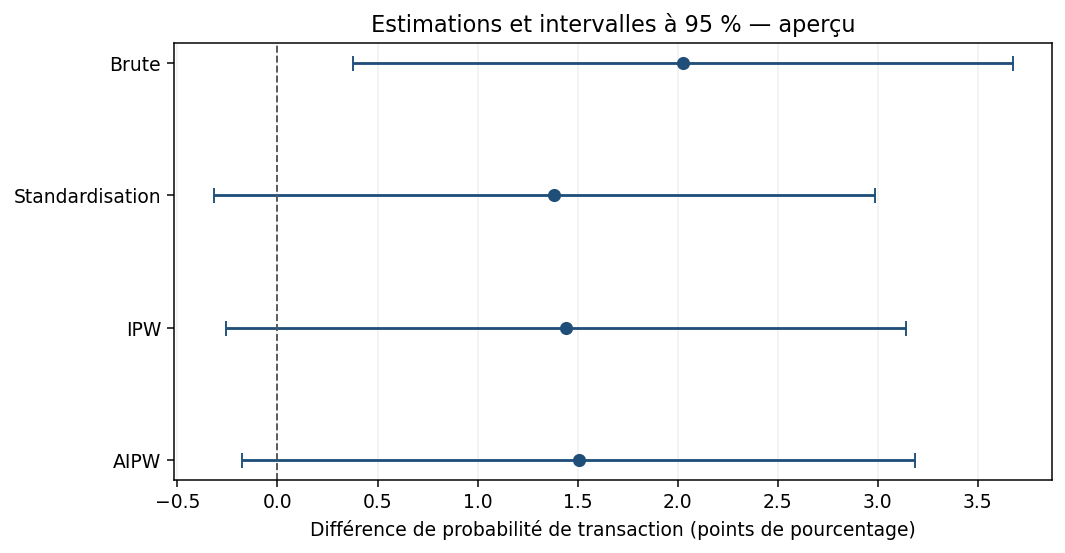

In [7]:
estimations = pd.read_csv(CHEMIN_ESTIMATIONS)
affichage_estimations = estimations.copy()
for colonne in ["Estimation (points)", "IC 95 % bas", "IC 95 % haut"]:
    affichage_estimations[colonne] = affichage_estimations[colonne].round(3)
display(affichage_estimations)

fig, ax = plt.subplots(figsize=(8, 4.2))
positions = np.arange(len(estimations))
centres = estimations["Estimation (points)"].to_numpy()
erreurs = np.vstack(
    [
        centres - estimations["IC 95 % bas"].to_numpy(),
        estimations["IC 95 % haut"].to_numpy() - centres,
    ]
)
ax.errorbar(centres, positions, xerr=erreurs, fmt="o", capsize=4, color="#1f4e79")
ax.axvline(0, color="#555555", linestyle="--", linewidth=1)
ax.set_yticks(positions, estimations["Méthode"])
ax.invert_yaxis()
ax.set_xlabel("Différence de probabilité de transaction (points de pourcentage)")
ax.set_title("Estimations et intervalles à 95 % — aperçu")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
tampon = io.BytesIO()
fig.savefig(tampon, format="png", dpi=135, bbox_inches="tight")
image_base64 = base64.b64encode(tampon.getvalue()).decode("ascii")
texte_alternatif = (
    "Graphique en points montrant les estimations brute, standardisée, IPW et AIPW "
    "avec leurs intervalles à 95 %. Les trois intervalles ajustés traversent zéro."
)
display(
    HTML(
        f'<figure><img src="data:image/png;base64,{image_base64}" alt="{texte_alternatif}" '
        'style="max-width:100%;height:auto">'
        '<figcaption>Aperçu des quatre estimations et de leurs intervalles à 95 %.</figcaption></figure>'
    )
)
plt.close(fig)


<div class="attention">

Le graphique précédent est seulement un **aperçu**. Nous n’avons pas encore appris pourquoi les méthodes ajustées diffèrent ni pourquoi l’AIPW a été choisie comme analyse principale. Ces questions seront traitées après les modules sur l’identification, le score de propension et les modèles de nuisance.

</div>


## Exercice 1A — Calculs et langage

<div class="exercice">

Répondre sans copier les formulations du cours.

1. Refaire manuellement les calculs `489 / 2 708` et `1 342 / 8 371`.
2. Comparer **+1,506 point** à **+1,506 % relativement au risque de semaine AIPW de 16,16 %**.
3. Si les hypothèses causales sont valides, traduire l’estimation AIPW de `+1,506 point` pour 1 000 sessions de la population cible.
4. Sous les mêmes hypothèses, traduire l’intervalle `[−0,176 ; 3,188]` en nombre approximatif de transactions pour 1 000 sessions de la population cible.
5. Pourquoi l’intervalle brut excluant zéro ne suffit-il pas à prouver un effet causal ?
6. Dans l’exemple fictif, comment une campagne qui provoque davantage de visites le weekend et augmente aussi la transaction produit-elle un écart global de 8 points alors que le weekend n’a aucun effet à campagne fixée ?

</div>


### ✍️ Mes réponses à l’exercice 1A

**1. Mes calculs :**  
_À remplir_

**2. Point de pourcentage contre pourcentage relatif :**  
_À remplir_

**3. Traduction pour 1 000 sessions :**  
_À remplir_

**4. Traduction de l’intervalle :**  
_À remplir_

**5. Significativité brute contre causalité :**  
_À remplir_

**6. Exemple des promotions :**  
_À remplir_


<details>
<summary><strong>Corrigé de l’exercice 1A — ouvrir après avoir tout calculé</strong></summary>

1. $489/2708=18{,}058\%$ et $1342/8371=16{,}032\%$, donc l’écart brut vaut $2{,}026$ points.
2. `+1,506 point` est une différence absolue. Relativement au risque de semaine AIPW de 16,16 %, cela représente environ $1{,}506/16{,}16=9{,}32\%$. Une hausse relative de 1,506 % depuis 16,16 % ne vaudrait qu’environ 0,243 point.
3. Sous les hypothèses causales : environ **+15 transactions pour 1 000 sessions** de la population cible.
4. L’intervalle correspond approximativement à **−2 à +32 transactions pour 1 000**. Ce n’est pas une prévision du trafic total.
5. L’IC brut ne traite que l’incertitude d’échantillonnage de l’association brute; il ne supprime pas la confusion ni les autres biais d’identification.
6. La campagne est plus fréquente parmi les sessions de weekend et augmente la transaction. Elle modifie donc la composition des groupes. Les taux conditionnels restent 10 % sans campagne et 30 % avec campagne dans les deux moments, mais le mélange global donne 14 % contre 22 %.

</details>


## Exercice 1B — Corriger des affirmations de jury

Pour chaque affirmation, indiquer précisément ce qui est incorrect, puis proposer une meilleure formulation.

1. « Vous avez prouvé que le weekend augmente les achats de 2,03 %. »
2. « Comme l’intervalle AIPW contient zéro, votre étude prouve qu’il n’y a aucun effet. »
3. « L’association brute est statistiquement significative, donc les variables de confusion ne posent plus de problème. »
4. « `Revenue` est le chiffre d’affaires généré par chaque client. »


### ✍️ Mes corrections — exercice 1B

**Affirmation 1 :**  
On a a prouve une augmenbtation de 2 point ce qui pourrait se traduire par 20 achats suplementaire sur 1000 transactions

**Affirmation 2 :**  
Pas necessairement veut juste dire qu'on ne peut pas definitivement exclure la possibilite qu'elle n'aurait pas d'impact

**Affirmation 3 :**  
Elle est certe significative mais pas definitive on ne peut donc pas encore oomettre les variables de confusion

**Affirmation 4 :**  
Non c'est un bool qui definit si la transaction a aboutit a un achat ou non


<details>
<summary><strong>Corrigé de l’exercice 1B — ouvrir après avoir réécrit les quatre phrases</strong></summary>

1. **Problèmes :** causalité affirmée, mauvaise unité, population absente.  
   **Correction :** « Dans la population `SpecialDay=0`, le taux observé est supérieur de 2,03 points de pourcentage le weekend; cet écart brut ne prouve pas un effet causal. »
2. **Problème :** absence de preuve confondue avec preuve d’absence.  
   **Correction :** « L’intervalle principal contient zéro; les données ne permettent pas d’écarter l’absence d’effet moyen, sans prouver que l’effet vaut exactement zéro. »
3. **Problème :** la significativité ne règle pas l’identification.  
   **Correction :** « L’écart brut est statistiquement différent de zéro selon son IC, mais peut encore refléter la confusion et d’autres biais. »
4. **Problèmes :** `Revenue` n’est ni un montant ni une mesure par client.  
   **Correction :** « `Revenue` indique si une session s’est terminée par une transaction. »

</details>


## Exercice oral 1C — Deux niveaux de réponse

### Question du jury

> « Le taux est plus élevé le weekend. Pourquoi ne concluez-vous pas directement que le weekend augmente les transactions ? »

Préparer deux réponses :

- une réponse de **20 secondes**, sans jargon inutile ;
- une réponse de **60 secondes**, structurée en D–A–C–L.

### ✍️ Ma réponse de 20 secondes

Il ne peut pas arriver à cette conclusion parce que malgré le fait que les transactions factuellement augmentent le week-end, on doit déterminer si c'est dû à d'autres variables externes et ou bien s'il y a vraiment une vraie corrélation entre le fait que les consommateurs ont tendance à acheter plus souvent le week-end ou non.

### ✍️ Ma réponse de 60 secondes

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle :** _À remplir_  
**Question de relance que je redoute :** _À remplir_


<details>
<summary><strong>Ouvrir seulement après avoir formulé une première réponse orale</strong></summary>

Une réponse possible de 20 secondes serait :

> « Nous observons 18,06 % de transactions le weekend contre 16,03 % en semaine, soit +2,03 points. Mais les groupes n’ont pas été randomisés et peuvent différer par leur composition ou par des causes non mesurées. Cette différence est donc descriptive ; une interprétation causale exige un ajustement et des hypothèses supplémentaires. »

Cette réponse est bonne parce qu’elle contient un résultat, le problème méthodologique et la limite, sans prétendre que l’ajustement réglera nécessairement tout.

</details>


## Point de passage du module 1

Je peux passer au module 2 lorsque je suis capable de :

- [ ] recalculer les deux taux observés sans regarder le rapport ;
- [ ] distinguer point de pourcentage et variation relative ;
- [ ] traduire une différence de risque en transactions pour 1 000 sessions ;
- [ ] expliquer pourquoi « statistiquement différent de zéro » ne signifie pas « causal » ;
- [ ] expliquer pourquoi un intervalle contenant zéro ne prouve pas un effet exactement nul ;
- [ ] répondre en 20 secondes à la question orale 1C ;
- [ ] citer au moins deux causes non mesurées plausibles sans affirmer qu’elles existent avec certitude.

**Niveau actuel estimé :** _/4_

<div class="oral">

**Formule de sécurité à l’oral :**  
« Le point estimé est positif, mais son interprétation dépend de la population, de l’échelle, de l’incertitude et des hypothèses causales. »

</div>


## Glossaire vivant — version actuelle

| Terme | Définition à ce stade |
|---|---|
| Unité d’analyse | Élément représenté par une observation : ici, une session de navigation. |
| Exposition | Variable dont on cherche à comprendre le contraste causal : ici, `Weekend`. |
| Résultat | Variable que l’exposition pourrait modifier : ici, `Revenue`, indicateur de transaction. |
| Proportion | Nombre de succès divisé par le nombre total d’observations. |
| Point de pourcentage | Différence absolue entre deux proportions exprimées en pourcentage. |
| Variation relative | Différence divisée par la valeur de référence. |
| Association | Différence ou relation observée entre des groupes. |
| Causalité | Changement du résultat qui surviendrait si l’on modifiait l’exposition dans une comparaison hypothétique bien définie. |
| Intervalle de confiance | Intervalle construit par une procédure destinée à quantifier l’incertitude d’échantillonnage. |
| Confusion | Mélange entre le contraste d’intérêt et l’effet de différences de composition ou de causes communes. |

Ce glossaire sera enrichi et parfois précisé. Une définition de début de parcours peut être correcte sans être encore complète.


## Journal de questions

Noter ici toute question, même si elle semble élémentaire. Une hésitation clairement formulée est un outil d’apprentissage.

| Question | Ma réponse actuelle | Ce qui reste flou | Réponse consolidée plus tard |
|---|---|---|---|
| _À remplir_ | _À remplir_ | _À remplir_ | |


# Passage en mode accéléré

Le module 1 n’est pas considéré comme parfaitement maîtrisé : les calculs de 1A et la réponse orale longue de 1C restent à consolider. Comme le temps est limité, ces points ne bloquent plus l’ouverture du module suivant.

La nouvelle stratégie est :

1. conserver toutes les premières réponses, même imparfaites;
2. avancer sur une seule idée causale centrale à la fois;
3. faire un exercice essentiel et une réponse orale courte par module;
4. réactiver plus tard les notions fragiles dans les questions de jury.

> **Priorité actuelle :** comprendre exactement quelle comparaison causale le projet cherche à estimer.


# Module 2 — Résultats potentiels, contrefactuel, intervention et estimand

<div class="objectif">

**Objectif de maîtrise :** expliquer pourquoi une question causale compare deux résultats possibles pour une même unité, puis énoncer précisément la quantité moyenne recherchée dans le projet.

**Prérequis minimal :** `Weekend` est l’exposition; `Revenue` indique si une session s’est terminée par une transaction.

</div>

### Parcours express

À la fin de ce module, quatre idées doivent pouvoir être dites sans notes :

1. une session possède conceptuellement un résultat sous weekend et un résultat sous semaine;
2. un seul des deux est observé; l’autre est contrefactuel;
3. le projet vise une **moyenne** dans la population `SpecialDay=0`;
4. l’estimand, l’estimateur et l’estimation sont trois choses différentes.

Temps cible pour un premier passage : **20 à 30 minutes**, exercice et réponse orale compris.


## 2.1 L’intuition : deux films possibles pour une même session

Imaginons une session précise avant qu’elle ait lieu. Nous voudrions pouvoir regarder deux films parallèles :

- **film 1 :** cette session a lieu durant le weekend; se termine-t-elle par une transaction ?
- **film 0 :** cette même session a lieu en semaine; se termine-t-elle par une transaction ?

La différence entre les deux films représenterait l’effet du weekend pour cette session. Mais dans la réalité, la session n’a lieu qu’une seule fois : nous ne voyons qu’un film.

Le film non observé est appelé le **contrefactuel** : ce qui se serait produit sous l’autre condition.

<div class="attention">

Le mot **potentiel** ne signifie pas « prédit par un modèle » ou « probable ». Il désigne le résultat conceptuel correspondant à une situation hypothétique précise.

</div>


## 2.2 Le vocabulaire et les mathématiques minimales

Pour la session $i$ :

- $T_i=1$ signifie que la session a réellement lieu durant le weekend;
- $T_i=0$ signifie qu’elle a réellement lieu en semaine;
- $Y_i(1)$ est le résultat potentiel de cette session sous weekend;
- $Y_i(0)$ est son résultat potentiel sous semaine;
- $Y_i$ est le résultat réellement observé dans `Revenue`.

| Situation réellement observée | Résultat que nous voyons | Résultat manquant |
|---|---|---|
| Session de weekend terminée par un achat | $Y_i(1)=1$ | $Y_i(0)=?$ |
| Session de semaine sans achat | $Y_i(0)=0$ | $Y_i(1)=?$ |

La relation entre l’exposition et le résultat observé s’écrit :

$$
Y_i=T_iY_i(1)+(1-T_i)Y_i(0).
$$

Cette formule dit simplement : si $T_i=1$, nous observons $Y_i(1)$; si $T_i=0$, nous observons $Y_i(0)$. Elle ne permet jamais d’observer les deux résultats pour la même session.

L’effet individuel conceptuel serait $Y_i(1)-Y_i(0)$. Comme un des deux termes manque toujours, cet effet individuel n’est pas directement observable. C’est le **problème fondamental de l’inférence causale**.


## 2.3 Pourquoi les deux groupes observés ne résolvent pas le problème

On pourrait proposer de remplacer le résultat manquant d’une session de weekend par le résultat d’une autre session de semaine. Le problème est que ces deux sessions peuvent différer par le mois, le type de visiteur, la campagne, le prix, le produit recherché ou l’intention d’achat.

| Comparaison | Ce qu’elle oppose | Statut |
|---|---|---|
| Différence brute | Des sessions de weekend observées et d’autres sessions de semaine observées | Association descriptive |
| Comparaison causale recherchée | La même population cible sous weekend puis sous semaine | Contraste contrefactuel |

Les autres sessions nous aident à reconstruire une **moyenne** sous des hypothèses causales; elles ne deviennent jamais le contrefactuel exact d’une session donnée.

> Les taux bruts `18,06 %` et `16,03 %` décrivent les deux groupes observés. Ils ne sont pas, à eux seuls, les deux résultats potentiels moyens.


## 2.4 Quelle intervention correspond à `Weekend` ?

Une question causale demande d’imaginer une modification de l’exposition. Ici, l’idée est :

> Pour les sessions de la population cible, que deviendrait en moyenne la probabilité de transaction si leur contexte temporel correspondait au weekend plutôt qu’à la semaine ?

`Weekend` n’est toutefois pas un médicament que l’on peut administrer avec un bouton. Déplacer le moment d’une session pourrait aussi modifier les promotions, le trafic, les horaires disponibles, le comportement du visiteur ou même l’existence de la session. Plusieurs versions du « weekend » sont possibles.

La **consistance** exige que l’intervention hypothétique soit suffisamment bien définie pour relier les résultats potentiels aux sessions réellement observées. Dans ce projet, cette condition est une hypothèse raisonnable de travail, mais aussi une limite à reconnaître.

L’analyse principale restreint la population aux sessions `SpecialDay=0`. Cela précise **à qui** s’applique la question; la raison liée au recouvrement et à la positivité sera étudiée au module 5.


## 2.5 L’estimand principal du projet

Comme nous ne pouvons pas observer l’effet individuel de chaque session, nous ciblons une moyenne :

$$
\tau_0=E\left[Y(1)-Y(0)\mid SpecialDay=0\right].
$$

Lecture morceau par morceau :

- $Y(1)-Y(0)$ : différence entre weekend et semaine pour une même unité conceptuelle;
- $E[\cdot]$ : moyenne de ces différences;
- $SpecialDay=0$ : population cible limitée aux sessions hors proximité d’un jour commercial spécial.

Comme `Revenue` vaut 0 ou 1, $\tau_0$ est une **différence moyenne de probabilité de transaction**, exprimable en points de pourcentage.

### Ne pas confondre la cible, l’outil et le résultat

| Élément | Question simple | Dans le projet |
|---|---|---|
| **Estimand** | Que voulons-nous connaître ? | $\tau_0$, l’effet moyen dans `SpecialDay=0` |
| **Estimateur** | Quelle règle de calcul utilisons-nous ? | Standardisation, IPW ou principalement AIPW |
| **Estimation** | Quel nombre avons-nous obtenu ? | AIPW : `+1,506` point, IC 95 % `[−0,176 ; 3,188]` |

<div class="attention">

L’estimand existe avant le calcul. Changer d’estimateur ne change pas la question visée; cela change la manière d’essayer d’y répondre. Le nombre `+1,506` est une estimation incertaine de la cible, pas la définition de la cible.

</div>


## 2.6 ATE, ATT, CATE et effet individuel — repères seulement

Le mot historique **traitement** désigne ici l’exposition `Weekend`; il ne s’agit pas d’un traitement médical.

| Terme | Population concernée | Est-ce la cible principale ? |
|---|---|---:|
| **ATE** — effet moyen | Toutes les unités de la population cible | **Oui**, conditionnellement à `SpecialDay=0` |
| **ATT** — effet moyen chez les exposés | Sessions réellement observées le weekend | Non |
| **CATE** — effet moyen conditionnel | Un sous-groupe défini, par exemple un type de visiteur | Non dans l’analyse principale |
| **Effet individuel** | Une session précise | Non observable directement |

À retenir maintenant : le projet vise un **ATE dans la population `SpecialDay=0`**. Un effet moyen positif ne signifierait pas que chaque session bénéficie du weekend de la même manière.


## Exercice 2A — Le minimum essentiel sans notes

<div class="exercice">

1. Une session réellement observée le weekend se termine par une transaction. Quel résultat potentiel observons-nous et quel résultat reste contrefactuel ?
2. Pourquoi une session de semaine prise au hasard ne constitue-t-elle pas automatiquement le contrefactuel exact de cette session de weekend ?
3. Traduis avec tes mots $\tau_0=E[Y(1)-Y(0)\mid SpecialDay=0]$.
4. Dans le projet, donne un exemple d’estimand, d’estimateur et d’estimation.

</div>


### ✍️ Mes réponses à l’exercice 2A

**1. Résultat observé et contrefactuel :**  
On obesrve alors Yi(1)=1 et son contrefactuel serait Yi(0)=? dont on ne connait pas la valeur mais qui n'est pas necessairement egal a 0

**2. Pourquoi une autre session ne suffit pas :**  
Parcequ'elle ne remplira jamais les meme condditions et ce qu'on chereche quand on parle de contrefactuel c'est les memes exact circonstances sauf pour la variabnle observe qui est weekend ici

**3. Traduction de l’estimand :**  
On cherche la moyenne de la meme situation dans une weekend ou non en prenant seulement en compte celle ou ce n'est pas du tout un special day

**4. Estimand, estimateur et estimation :**  
Estimand l'effect du weeekend ou non sur t0
Estimateur AIPW
Estimation +1.506 points


<details>
<summary><strong>Corrigé de l’exercice 2A — ouvrir après la tentative</strong></summary>

1. Puisque la session a lieu le weekend et se termine par une transaction, nous observons $Y_i(1)=1$. Son résultat sous semaine, $Y_i(0)$, reste contrefactuel et inconnu; il ne vaut pas automatiquement zéro.
2. L’autre session peut différer par de nombreuses caractéristiques. Elle fournit de l’information pour une comparaison moyenne sous hypothèses, mais elle n’est pas la même unité dans l’autre situation.
3. $\tau_0$ est la différence moyenne de probabilité de transaction si les sessions de la population `SpecialDay=0` avaient lieu le weekend plutôt qu’en semaine.
4. L’estimand est $\tau_0$; l’AIPW est l’estimateur principal; `+1,506 [−0,176 ; 3,188]` points est l’estimation avec son intervalle.

</details>


## Exercice oral 2B — Quel est votre estimand ?

### Question du jury

> « Quelle est exactement votre question causale, et pourquoi parlez-vous de contrefactuel ? »

### ✍️ Ma réponse de 20 secondes

Alors, ma question causale est d'observer l'impact direct sur les achats qui sont faits dans des sessions en week-end et hors week-end, en isolant seulement les sessions qui sont faites où le CTA était égal à zéro.

### ✍️ Ma réponse de 60 secondes — D–A–C–L
N'a pas ete capable d'y repondre
- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_

<p class="petit">La dictée vocale peut conserver le contenu, mais la durée doit être mesurée séparément afin d’inclure les hésitations.</p>


<details>
<summary><strong>Réponses orales possibles et questions pièges — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « Nous ciblons la différence moyenne de probabilité d’achat si les sessions `SpecialDay=0` avaient lieu le weekend plutôt qu’en semaine. Pour chaque session, une seule situation est observée; l’autre est contrefactuelle. Nous estimons donc cette moyenne sous des hypothèses causales. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** un estimand est la quantité causale précise que l’étude cherche à connaître.
- **Application :** nous comparons la même population de sessions sous deux contextes hypothétiques, weekend et semaine, à l’aide des résultats potentiels $Y(1)$ et $Y(0)$.
- **Chiffre concret :** la population cible contient `11 079` sessions `SpecialDay=0`; l’AIPW estime le contraste à `+1,506` point avec un IC 95 % `[−0,176 ; 3,188]`.
- **Limite :** une session n’est observée que sous une condition, `Weekend` possède plusieurs versions possibles et l’interprétation causale dépend d’hypothèses non entièrement vérifiables.

### Questions pièges

1. **« Pourquoi ne mesurez-vous pas directement les deux résultats de chaque session ? »** Parce qu’une même session n’est observée qu’une fois; l’autre résultat est contrefactuel.
2. **« Un ATE positif signifie-t-il que toutes les sessions achètent davantage ? »** Non. Il s’agit d’une moyenne, compatible avec des effets individuels différents.
3. **« Weekend n’est pas un bouton manipulable; votre question est-elle vraiment causale ? »** Elle exige une intervention hypothétique suffisamment définie; l’ambiguïté des versions du weekend est une limite réelle.
4. **« Votre estimand vaut donc +1,506 point ? »** Non. L’estimand est la cible; `+1,506` est une estimation obtenue avec l’AIPW.

</details>


## Point de passage du module 2

Je peux considérer le socle du module acquis lorsque je suis capable de :

- [x] définir résultat potentiel et contrefactuel avec mes mots;
- [x] identifier, pour une session donnée, le résultat observé et celui qui manque;
- [x] expliquer le problème fondamental de l’inférence causale;
- [ ] énoncer l’estimand principal et sa population cible;
- [ ] distinguer estimand, estimateur et estimation;
- [ ] répondre en 20 secondes à la question orale 2B et citer une limite.

**Niveau actuel estimé :** 2/4

**Point encore fragile :** formuler précisément l’estimand, distinguer la cible du symbole $\tau_0$, puis produire la réponse orale 2B.

> En mode accéléré, une première réponse imparfaite est corrigée sans bloquer tout le parcours. Les cases ne sont toutefois cochées que lorsque l’idée correspondante a réellement été reconstruite.


# Transition vers le module 3 — raisonner dans le temps

Le socle du module 2 est suffisant pour avancer. Les trois repères à conserver sont :

1. pour une même session, un seul résultat potentiel est observé;
2. l’estimand est l’effet moyen de `Weekend` dans la population `SpecialDay=0`;
3. l’AIPW est un estimateur, tandis que `+1,506` point est une estimation.

Nous allons maintenant décider quelles variables peuvent rendre la comparaison plus juste et lesquelles risquent au contraire de la déformer.


# Module 3 — Temporalité, confondeurs, médiateurs, colliders et variables post-exposition

<div class="objectif">

**Objectif de maîtrise :** déterminer le rôle causal plausible d’une variable avant de décider de l’utiliser pour l’ajustement.

**Question de sécurité :** cette variable existait-elle avant `Weekend`, ou pourrait-elle être une conséquence du moment de la session ?

</div>

### Parcours express

À la fin du module, il faut surtout savoir :

1. reconnaître les trois formes de flèches confondeur, médiateur et collider;
2. expliquer pourquoi une variable très prédictive n’est pas automatiquement une bonne variable d’ajustement;
3. justifier l’exclusion des variables de navigation et de `PageValues`;
4. présenter honnêtement l’ambiguïté de `TrafficType`.

Temps cible pour un premier passage : **25 à 35 minutes**.


## 3.1 Commencer par une ligne du temps

Avant de regarder les corrélations, plaçons les informations dans l’ordre plausible d’une session :

| Moment | Éléments du projet |
|---|---|
| **Avant ou au début de la session** | `Month`, profil du visiteur, région, système, navigateur; `TrafficType` selon l’hypothèse principale |
| **Exposition calendaire** | `Weekend` |
| **Pendant la navigation** | nombres de pages, durées, `BounceRates`, `ExitRates` |
| **Fin de la session** | `Revenue`, indicateur de transaction |
| **Mesure liée à la navigation et à la transaction** | `PageValues` |

La règle la plus sûre pour viser l’**effet total** de `Weekend` est de ne pas ajuster automatiquement sur une variable qui pourrait être causée par `Weekend`.

<div class="attention">

Être mesurée avant le résultat ne suffit pas. Une variable doit aussi avoir le bon rôle causal. Inversement, être pré-exposition ne signifie pas automatiquement qu’il faut l’ajuster.

</div>


## 3.2 Le confondeur : une différence présente au départ

Un **confondeur** est une cause commune plausible de l’exposition et du résultat :

$$
Weekend \leftarrow C \rightarrow Revenue.
$$

Intuition : si certaines caractéristiques rendent à la fois une visite plus probable le weekend et un achat plus probable, la différence brute mélange l’effet éventuel du weekend avec ces différences de départ.

Dans le DAG de travail, l’ajustement principal suppose que les variables suivantes précèdent l’exposition et contribuent à la comparabilité :

- `Month`;
- `VisitorType`;
- `Region`;
- `OperatingSystems`;
- `Browser`;
- `TrafficType`, avec une réserve importante étudiée plus bas.

Les promotions, prix et intentions d’achat préalables pourraient aussi confondre la comparaison, mais ils sont absents du CSV. Un ajustement ne peut pas corriger une variable qui n’a pas été mesurée.


## 3.3 Le médiateur : une étape possible du mécanisme

Un **médiateur** se situe sur un chemin par lequel l’exposition pourrait modifier le résultat :

$$
Weekend \rightarrow M \rightarrow Revenue.
$$

Exemple plausible : le weekend pourrait modifier la manière de naviguer, puis cette navigation pourrait influencer la transaction. Les nombres de pages, les durées, `BounceRates` et `ExitRates` sont donc mesurés trop tard pour être traités sans réflexion comme des confondeurs.

Lorsque la cible est l’**effet total**, ajuster sur un médiateur peut bloquer une partie de l’effet que nous cherchons justement à mesurer. Cela rapproche la question d’un effet direct, qui est un autre estimand et exige d’autres hypothèses.

> À l’oral, éviter de dire que le projet mesure « l’impact direct » : l’analyse principale vise un effet moyen total, sous hypothèses.


## 3.4 Le collider : une conséquence commune sur laquelle il ne faut pas conditionner

Un **collider** est une variable qui reçoit deux flèches :

$$
A \rightarrow K \leftarrow B.
$$

Sans conditionner sur $K$, le chemin entre $A$ et $B$ est fermé. Sélectionner, stratifier ou ajuster sur $K$ peut au contraire créer une association artificielle entre ses causes.

Dans le DAG de travail, `PageValues` reçoit des flèches de la navigation et de `Revenue` :

$$
Navigation \rightarrow PageValues \leftarrow Revenue.
$$

`PageValues` est donc exclue : son statut postérieur, sa construction liée à la valeur transactionnelle et son rôle de collider plausible créent aussi un risque de fuite d’information. Sa forte capacité prédictive ne la rend pas sûre pour l’ajustement causal.


## 3.5 Variable post-exposition : une catégorie temporelle, pas un rôle unique

Une variable **post-exposition** est mesurée après l’exposition ou pourrait être causée par elle. Elle peut être médiatrice, collider, conséquence du résultat ou combinaison de plusieurs rôles.

Avant d’ajouter une variable à l’ajustement, poser les questions dans cet ordre :

1. **Temporalité :** était-elle déterminée avant `Weekend` ?
2. **Cause commune :** pourrait-elle causer à la fois `Weekend` et `Revenue` ? Si oui, c’est une candidate confondeur.
3. **Conséquence :** `Weekend` pourrait-il la modifier ? Si oui, prudence : elle peut être médiatrice ou post-exposition.
4. **Cause commune reçue :** reçoit-elle des flèches de deux variables ? Si oui, elle peut être collider.
5. **Cible :** voulons-nous l’effet total ou un effet direct ? Le projet vise l’effet total.

> **Règle de survie :** on ne choisit jamais un ajustement uniquement parce qu’une variable prédit bien `Revenue`.


## 3.6 Classement retenu dans le projet

| Groupe | Variables | Décision principale | Justification |
|---|---|---|---|
| Exposition | `Weekend` | Ne pas ajuster sur elle comme covariable | C’est la condition comparée |
| Résultat | `Revenue` | Ne pas utiliser comme covariable | C’est l’issue étudiée |
| Pré-session supposées | `Month`, `VisitorType`, `Region`, `OperatingSystems`, `Browser` | Ajuster | Causes de composition plausibles dans le DAG de travail |
| Acquisition ambiguë | `TrafficType` | Ajuster dans l’analyse principale, retirer en sensibilité | Supposée antérieure, mais pourrait être médiatrice |
| Navigation pendant la session | pages, durées, `BounceRates`, `ExitRates` | Exclure | Médiateurs ou variables post-exposition possibles |
| Valeur de page | `PageValues` | Exclure | Liée à la navigation et à la transaction; collider et fuite plausibles |
| Jour commercial spécial | `SpecialDay` | Restreindre à `0` | Défaut de recouvrement étudié au module 5 |
| Non observées | promotions, prix, produit, heure, campagne, intention préalable | Signaler comme limites | Impossible de les ajuster avec le CSV |

L’ensemble d’ajustement principal est donc :

$$
Z=\{Month, VisitorType, Region, OperatingSystems, Browser, TrafficType\}.
$$

Ce classement exprime des **hypothèses causales**, pas des faits démontrés par les données.


## 3.7 Le cas ambigu de `TrafficType`

Dans l’analyse principale, le canal d’acquisition est supposé défini avant l’exposition et susceptible d’influencer à la fois le moment de la visite et l’achat. Sous cette histoire, `TrafficType` est un confondeur à ajuster.

Une autre histoire est plausible : le weekend pourrait modifier le canal par lequel les visiteurs arrivent. `TrafficType` deviendrait alors un médiateur possible, et l’ajuster pourrait retirer une partie de l’effet total.

Le projet présente donc une analyse sans `TrafficType` :

- analyse principale avec `TrafficType` : `+1,506 [−0,176 ; 3,188]` points;
- analyse sans `TrafficType` : `+2,233 [0,535 ; 3,931]` points.

Cette variation montre que le jugement temporel compte. Elle ne prouve pas que l’une des deux histoires est vraie et ne justifie pas de choisir uniquement le résultat le plus favorable.

> **Formulation sûre :** « `TrafficType` est traité comme pré-exposition dans l’analyse principale, mais son statut est ambigu; son retrait constitue donc une analyse de sensibilité substantielle. »


## Exercice 3A — Classer avant d’ajuster

<div class="exercice">

1. Dessine ou décris les flèches caractéristiques d’un confondeur, d’un médiateur et d’un collider.
2. Classe `Month`, `ProductRelated_Duration`, `PageValues` et `TrafficType` selon l’histoire causale du projet, puis indique la décision prise pour chacune.
3. Pourquoi ne faut-il pas ajuster automatiquement sur les variables de navigation, même si elles prédisent très bien `Revenue` ?
4. Pourquoi l’analyse sans `TrafficType` est-elle une analyse de sensibilité importante plutôt qu’un moyen de choisir le résultat préféré ?

</div>


### ✍️ Mes réponses à l’exercice 3A

**1. Les trois formes de flèches :**  
Confondeur x<-c->y / mediateur a->m->y /collider x->c<-y

**2. Classement des quatre variables :**  
MOnth-TrafficType-pageValue-ProductRElated_duration 

**3. Variables de navigation :**  
Car on cherche a etudier l'impact du weekend

**4. Sensibilité sans `TrafficType` :**  
r on estime qu'elle a un impact direct sur le weekend et sur le revenu


<details>
<summary><strong>Corrigé de l’exercice 3A — ouvrir après la tentative</strong></summary>

1. Confondeur : $Weekend \leftarrow C \rightarrow Revenue$. Médiateur : $Weekend \rightarrow M \rightarrow Revenue$. Collider : $A \rightarrow K \leftarrow B$.
2. `Month` est pré-exposition et ajustée; `ProductRelated_Duration` est une navigation post-exposition ou médiatrice possible et exclue; `PageValues` est un collider plausible, présente un risque de fuite et est exclue; `TrafficType` est ambigu, ajusté principalement puis retiré en sensibilité.
3. Elles pourraient être causées par `Weekend`. Les ajuster pourrait bloquer une partie de l’effet total ou ouvrir un chemin par collider. La prédiction du résultat ne suffit pas à justifier causalement l’ajustement.
4. Les deux ordres temporels sont plausibles. Comparer les analyses révèle la dépendance du résultat à cette hypothèse; choisir après coup celle qui donne le résultat souhaité serait une sélection opportuniste.

</details>


## Exercice oral 3B — Pourquoi exclure des variables très prédictives ?

### Question du jury

> « `PageValues` et les variables de navigation prédisent très bien les achats. Pourquoi ne pas les inclure dans l’ajustement ? »

### ✍️ Ma réponse de 20 secondes

Il y a différentes raisons à cela. D'abord, il y a une chance qu'elles influencent directement l'occurrence du weekend, et en parallèle, elles peuvent influencer le résultat final qui est la transaction, tandis que nous, ce qu'on cherche, c'est l'influence du weekend.

### ✍️ Ma réponse de 60 secondes — D–A–C–L

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


## Retour personnalisé — la correction essentielle

### Ce qui est acquis

Les trois formes de flèches de ta réponse 1 sont correctes :

- confondeur : $X \leftarrow C \rightarrow Y$;
- médiateur : $A \rightarrow M \rightarrow Y$;
- collider : $X \rightarrow C \leftarrow Y$.

### Le point à corriger

Dans ta réponse orale, tu proposes que les variables de navigation puissent influencer l’occurrence du weekend. L’ordre temporel plausible est inverse : une fois qu’une session a lieu le samedi ou le dimanche, son nombre de pages ou sa durée ne peut pas la faire devenir une session de weekend.

$$
Weekend \rightarrow Navigation \rightarrow Revenue.
$$

La navigation peut donc être un **médiateur**. L’ajuster risquerait de bloquer une partie de l’effet total de `Weekend` que nous voulons estimer.

| Variable | Rôle retenu ou plausible | Décision |
|---|---|---|
| `Month` | Pré-exposition, confondeur candidat | Ajuster |
| `ProductRelated_Duration` | Navigation post-exposition, médiateur possible | Exclure |
| `PageValues` | Post-exposition, collider et fuite d’information plausibles | Exclure |
| `TrafficType` | Statut ambigu | Ajuster principalement, puis retirer en sensibilité |

Pour `TrafficType`, deux histoires restent possibles : il peut influencer le moment de la visite et l’achat, ou être lui-même influencé par le weekend. L’analyse sans `TrafficType` vérifie la sensibilité du résultat à ce choix; elle ne sert pas à sélectionner le résultat préféré.

### Version corrigée à répéter en 20 secondes

> « Ces variables sont mesurées pendant ou après la session et peuvent être des conséquences du weekend. Les ajuster pourrait bloquer une partie de l’effet total. `PageValues` est aussi liée à la transaction et présente un risque de collider ou de fuite d’information. »

**Phrase minimale à reconstruire sans notes avant le module 4 :** « On exclut la navigation parce qu’elle peut être une conséquence de `Weekend`; l’ajuster pourrait bloquer une partie de l’effet total. »


<details>
<summary><strong>Réponses orales possibles et questions pièges — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « Elles sont mesurées pendant ou après la session et pourraient être causées par `Weekend`. Les ajuster risquerait de bloquer une partie de l’effet total ou d’ouvrir un biais de collider. `PageValues` est aussi liée à la transaction; la prédiction seule ne justifie donc pas l’ajustement causal. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** une variable d’ajustement est choisie pour son rôle causal supposé, pas seulement pour sa capacité prédictive.
- **Application :** les variables de navigation peuvent se situer après `Weekend` et transmettre une partie de son effet; `PageValues` est en plus liée à la navigation et à `Revenue`.
- **Chiffre concret :** l’ensemble principal contient six covariables pré-session supposées. Retirer la plus ambiguë, `TrafficType`, déplace l’AIPW de `+1,506` à `+2,233` points.
- **Limite :** le statut temporel de `TrafficType` et de certains contextes de session n’est pas directement vérifiable dans le CSV; les causes non mesurées restent possibles.

### Questions pièges

1. **« Ajouter toutes les variables ne peut qu’améliorer l’ajustement, non ? »** Non. Un médiateur ou un collider peut introduire un biais ou changer la cible.
2. **« Pourquoi ne pas utiliser `PageValues`, votre meilleur prédicteur ? »** Parce qu’elle est liée à la transaction et située trop tard causalement; elle crée un risque de fuite et de collider.
3. **« Être pré-exposition suffit-il pour être confondeur ? »** Non. Il faut aussi un rôle de cause commune pertinent pour la comparaison.
4. **« Pourquoi conserver `TrafficType` si son statut est ambigu ? »** L’analyse principale explicite l’hypothèse pré-exposition et l’analyse de sensibilité évalue l’autre choix.
5. **« Le CSV prouve-t-il que la navigation est médiatrice ? »** Non. C’est une hypothèse temporelle et causale plausible, pas un fait démontré par la corrélation.

</details>


## Point de passage du module 3

Je peux considérer le socle du module acquis lorsque je suis capable de :

- [ ] placer `Weekend`, les variables de navigation et `Revenue` dans le temps;
- [x] reconnaître les formes confondeur, médiateur et collider;
- [ ] expliquer pourquoi une variable prédictive n’est pas automatiquement ajustable;
- [ ] justifier l’exclusion de la navigation et de `PageValues`;
- [ ] expliquer l’ambiguïté de `TrafficType` et le rôle de l’analyse de sensibilité;
- [ ] répondre en 20 secondes à la question orale 3B et citer une limite.

**Niveau actuel estimé :** **1,5/4** — les formes sont acquises; l’ordre temporel et son application au projet doivent être corrigés avant le DAG.

> **Prochaine action ciblée :** relire le retour personnalisé, puis reconstruire sans notes la phrase minimale sur l’exclusion de la navigation. La réponse de 60 secondes sera reprise lors de la préparation des diapositives.


# Transition vers le module 4 — transformer l’ordre temporel en chemins

La correction essentielle du module 3 est maintenant posée :

$$
Weekend \rightarrow Navigation \rightarrow Revenue.
$$

Nous allons placer cette histoire dans un DAG, distinguer les chemins qui transmettent l’effet de ceux qui faussent la comparaison, puis préciser ce que les données peuvent identifier sous hypothèses.


# Module 4 — DAG, porte arrière et identification

<div class="objectif">

**Objectif de maîtrise :** expliquer comment le DAG conduit à l’ensemble d’ajustement et pourquoi cette stratégie ne transforme pas l’étude observationnelle en expérience.

**Question directrice :** quels chemins faut-il laisser ouverts pour mesurer l’effet, et quels chemins faut-il bloquer pour rendre la comparaison plus juste ?

</div>

### Parcours express

À retenir en priorité :

1. un DAG représente des hypothèses causales, pas un résultat découvert automatiquement;
2. un chemin de porte arrière entre dans `Weekend` par une flèche;
3. l’ensemble $Z$ bloque les chemins observés retenus, pas les causes non mesurées;
4. identifier et estimer sont deux opérations différentes.

Temps cible pour un premier passage : **35 à 45 minutes**.


## 4.1 Le DAG : une carte de l’histoire causale supposée

Un DAG ressemble à un plan de métro : les variables sont des stations et les flèches indiquent dans quel sens une cause pourrait agir. Il sert à voir tous les itinéraires plausibles entre l’exposition et le résultat.

**DAG** signifie *Directed Acyclic Graph*, ou **graphe orienté acyclique** :

- **graphe** : un ensemble de nœuds et de liens;
- **orienté** : chaque flèche possède un sens;
- **acyclique** : on ne peut pas suivre les flèches et revenir à son point de départ.

Une flèche $A \rightarrow B$ signifie : « dans notre modèle de travail, $A$ peut causer directement $B$ ». Elle ne signifie ni que la corrélation suffit, ni que l’effet a été statistiquement démontré. De même, le DAG ne devient pas vrai parce qu’il est bien dessiné : il formalise des connaissances et des hypothèses discutables.

![DAG de travail du projet](04_outputs/figures/02_dag_de_travail.png)

<p class="petit">Cette figure est celle du projet soumis; elle est seulement affichée ici en lecture.</p>


## 4.2 Lire le DAG exact du projet

Le dessin regroupe plusieurs colonnes pour rester lisible :

| Nœud du dessin | Colonnes ou idée correspondante |
|---|---|
| Calendrier | principalement `Month`, dans la population déjà restreinte à `SpecialDay=0` |
| Profil visiteur | `VisitorType`, `Region`, `OperatingSystems`, `Browser` |
| Canal trafic | `TrafficType` |
| Navigation | nombres de pages, durées, `BounceRates`, `ExitRates` |
| Exposition | `Weekend` |
| Résultat | `Revenue` |

Deux chemins transmettent un effet possible et doivent rester ouverts lorsque nous visons l’effet total :

$$Weekend \rightarrow Revenue$$

et

$$Weekend \rightarrow Navigation \rightarrow Revenue.$$

Les nœuds en pointillés — promotions/prix et intention d’achat préalable — représentent des causes plausibles non observées. Leur présence dans le dessin sert précisément à rappeler la fragilité de l’identification.


## 4.3 La porte arrière : un détour qui fausse la comparaison

Un **chemin causal** part de `Weekend` par une flèche sortante. C’est un itinéraire par lequel le weekend pourrait modifier l’achat.

Un **chemin de porte arrière** commence au contraire par une flèche qui **entre** dans `Weekend`. Une cause antérieure crée alors un détour entre `Weekend` et `Revenue` :

$$Weekend \leftarrow Month \rightarrow Revenue.$$

Intuition : si les mois ne sont pas distribués de la même façon entre semaine et weekend et que la saison influence aussi les achats, la différence brute mélange weekend et saison. Ajuster sur `Month` ferme ce détour observé.

Dans le DAG de travail, les principaux détours observés passent par le calendrier, le profil du visiteur et le canal de trafic. Ils motivent l’ajustement, tandis que le chemin via la navigation transmet l’effet total et ne doit pas être fermé.


## 4.4 Quand un chemin est-il ouvert ou fermé ?

| Forme simple | Nom | Sans ajustement | Si l’on conditionne sur la variable centrale |
|---|---|---|---|
| $A \rightarrow M \rightarrow Y$ | Chaîne; $M$ peut être médiateur | Ouvert | Le chemin se ferme |
| $A \leftarrow C \rightarrow Y$ | Fourche; $C$ peut être confondeur | Ouvert | Le chemin se ferme |
| $A \rightarrow K \leftarrow Y$ | Collider | Fermé | Le chemin peut s’ouvrir |

Application directe :

- fermer $Weekend \leftarrow Month \rightarrow Revenue$ est utile;
- fermer $Weekend \rightarrow Navigation \rightarrow Revenue$ retirerait une partie de l’effet total;
- conditionner sur `PageValues` pourrait ouvrir un chemin auparavant fermé, car cette variable reçoit des flèches de la navigation et de `Revenue`.

> Le mot **bloquer** décrit un chemin dans le graphe. Il ne signifie pas supprimer physiquement des observations ni empêcher un achat.


## 4.5 Le critère de porte arrière et l’ensemble $Z$

Pour viser l’effet total, un ensemble d’ajustement de porte arrière doit, dans le DAG retenu :

1. ne pas contenir de conséquence de `Weekend`;
2. bloquer tous les chemins entre `Weekend` et `Revenue` qui commencent par une flèche entrant dans `Weekend`.

Sous la partie **observée** du DAG, l’ensemble principal est :

$$
Z=\{Month, VisitorType, Region, OperatingSystems, Browser, TrafficType\}.
$$

Les cinq premières variables sont considérées comme pré-exposition. `TrafficType` est également traité ainsi dans l’analyse principale, mais son statut ambigu motive l’analyse de sensibilité sans cette variable.

`SpecialDay` ne figure pas dans cet ensemble principal : l’analyse est **restreinte** à `SpecialDay=0`. La raison liée à la positivité sera étudiée au module 5.


## 4.6 De l’intuition à la formule d’identification

Notons $T=Weekend$, $Y=Revenue$ et travaillons dans la population $SpecialDay=0$. Si l’ajustement par $Z$ suffit à rendre les groupes comparables, alors :

$$
P(Y=1\mid do(T=t),SpecialDay=0)
=\sum_z P(Y=1\mid T=t,Z=z,SpecialDay=0)P(Z=z\mid SpecialDay=0).
$$

Le symbole $do(T=t)$ représente une intervention conceptuelle : fixer la condition weekend ou semaine, plutôt que seulement constater le jour observé.

La formule raconte trois opérations simples :

1. former des profils comparables décrits par $Z=z$;
2. estimer, dans chaque profil, la probabilité d’achat sous $T=t$;
3. moyenner ces probabilités selon la composition de la population `SpecialDay=0`, et non selon la composition propre de chaque groupe observé.

Cette égalité est une conclusion **sous hypothèses**. Elle n’est pas garantie par le simple fait d’avoir calculé une régression.


## 4.7 Les hypothèses nécessaires

L’**identification** signifie que la quantité causale peut être reliée à la distribution des données observées. Pour cela, le projet s’appuie sur cinq hypothèses :

| Hypothèse | Intuition | Application ou difficulté dans le projet |
|---|---|---|
| Consistance | La condition comparée doit être assez bien définie | Une « intervention weekend » reste conceptuelle et peut recouvrir plusieurs mécanismes |
| Échangeabilité conditionnelle | À profil $Z$ égal, le groupe observé ne cache plus de différence causale systématique | Les confondeurs non mesurés rendent cette hypothèse forte |
| Positivité | Chaque profil comparé doit pouvoir apparaître en semaine et en weekend | La restriction à `SpecialDay=0` répond à un problème majeur, étudié au module 5 |
| Absence d’interférence | L’exposition d’une session ne change pas le résultat potentiel d’une autre | Hypothèse plausible mais non directement vérifiable |
| Mesure et ordre temporel corrects | Les variables doivent représenter ce que l’on croit et être classées au bon moment | `TrafficType` reste ambigu et le CSV est anonymisé |

L’hypothèse centrale peut s’écrire :

$$
(Y(1),Y(0)) \perp T \mid Z,SpecialDay=0.
$$

Elle signifie qu’après conditionnement sur $Z$, le fait d’observer une session en weekend ou en semaine ne fournit plus d’information sur ses résultats potentiels. Cette hypothèse d’échangeabilité n’est pas testable directement.


## 4.8 Ce que l’ajustement peut bloquer — et ce qu’il ne peut pas bloquer

Le DAG montre volontairement deux niveaux :

| Type de chemin | Exemple | Peut-on le bloquer avec le CSV ? |
|---|---|---|
| Confondeur observé | $Weekend \leftarrow Month \rightarrow Revenue$ | Oui, en ajustant sur `Month` |
| Confondeur supposé observé | détour par `TrafficType` | Oui sous l’hypothèse qu’il précède `Weekend`; sensibilité sinon |
| Confondeur non mesuré | $Weekend \leftarrow Promotions/prix \rightarrow Revenue$ | Non |
| Confondeur non mesuré | $Weekend \leftarrow Intention \rightarrow Revenue$ | Non |

Donc, sous le DAG contenant ces causes latentes, **aucun ensemble entièrement observé ne garantit l’identification**. Le projet peut seulement annoncer une estimation causale exploratoire conditionnelle à l’absence de confusion résiduelle importante.

<div class="attention">

Un bon équilibre des covariables observées ne démontre pas l’échangeabilité : il ne dit rien sur une promotion, un prix ou une intention qui n’a pas été mesuré.

</div>


## 4.9 Ne pas confondre cible, identification, méthode et résultat

| Étape | Question | Dans le projet |
|---|---|---|
| Estimand | Que voulons-nous connaître ? | $E[Y(1)-Y(0)\mid SpecialDay=0]$ |
| Identification | Sous quelles hypothèses cette cible devient-elle calculable avec les observations ? | Porte arrière par $Z$, échangeabilité, positivité, consistance, absence d’interférence |
| Estimateur | Quelle recette statistique utilisons-nous sur l’échantillon ? | Standardisation, IPW et surtout AIPW avec cross-fitting |
| Estimation | Quel nombre la recette produit-elle ici ? | AIPW : `+1,506` point, IC à 95 % `[−0,176 ; 3,188]` |

Un estimateur sophistiqué ne répare pas une identification invalide. L’AIPW peut protéger contre certaines erreurs de modèles observés; elle ne mesure pas une promotion absente du fichier.


## Exercice 4A — Lire les chemins avant de calculer

<div class="exercice">

1. Pour chacun des chemins suivants, indique s’il s’agit d’un chemin causal, d’un chemin de porte arrière ou d’un chemin fermé par collider. Dis ensuite s’il faut le laisser ouvert ou le bloquer pour estimer l’effet total.
   - $Weekend \leftarrow Month \rightarrow Revenue$;
   - $Weekend \rightarrow Navigation \rightarrow Revenue$;
   - $Weekend \rightarrow Navigation \rightarrow PageValues \leftarrow Revenue$.
2. Donne les six variables de l’ensemble $Z$ et explique son rôle en une phrase.
3. Pourquoi le blocage de tous les chemins de porte arrière **observés** ne garantit-il pas un effet causal identifié dans ce projet ?
4. Explique la différence entre identification et estimation avec l’exemple de l’AIPW.

</div>


### ✍️ Mes réponses à l’exercice 4A

**1. Les trois chemins et la décision :**  
1-Chemin causal /2-Chemin porte arriere /3- Chemin ferme

**2. Ensemble $Z$ et rôle :**  
Month,operating system,browser,region,visitor type, trafic type
Son role est determiner les variable de pre exposition

**3. Pourquoi les chemins observés ne suffisent pas :**  
Car on a differentes variable qui ne font pas partie de notre dataset q'on estime avoir une influence sur la probabilite d''achat et l'influence sur le weekend

**4. Identification contre estimation :**  
L'identification a pour but de selectionber les variable qui ont un impact  tandis que l'estimation est le calcul de le reel impact


<details>
<summary><strong>Corrigé de l’exercice 4A — ouvrir après la tentative</strong></summary>

1. Le chemin par `Month` est une porte arrière ouverte : il faut le bloquer. Le chemin par `Navigation` est causal : il faut le laisser ouvert pour l’effet total. Le chemin passant par `PageValues` contient un collider et est fermé sans conditionnement : il ne faut pas ajuster sur `PageValues`, ce qui pourrait l’ouvrir.
2. $Z=\{Month, VisitorType, Region, OperatingSystems, Browser, TrafficType\}$. Il sert à bloquer les chemins de confusion observés retenus dans le DAG.
3. Les promotions, prix et intentions préalables sont absents du CSV. Leurs chemins ne peuvent donc pas être bloqués et l’échangeabilité reste une hypothèse non vérifiable.
4. L’identification justifie, sous hypothèses, le passage de l’effet contrefactuel à une quantité calculable dans les données. L’AIPW est ensuite une recette d’estimation de cette quantité; son résultat numérique ne valide pas les hypothèses.

</details>


## Exercice oral 4B — Le DAG prouve-t-il l’effet causal ?

### Question du jury

> « Puisque votre DAG fournit un ensemble d’ajustement, pouvez-vous maintenant affirmer que l’effet est causal ? »

### ✍️ Ma réponse de 20 secondes

Bien que notre DAG fournisse un ensemble d'ajustements, on ne peut pas affirmer qu'il a un effet causal vu qu'il n'est que le résultat de de nos estimations et de nos observations. Il n'est donc pas concrètement factuel.

### ✍️ Ma réponse de 60 secondes — D–A–C–L

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


## Retour personnalisé — remettre les flèches dans le bon sens

### Ce qui est déjà acquis

- tu as cité correctement les six variables de $Z$;
- tu as reconnu que le troisième chemin est fermé par un collider;
- tu as compris que des variables absentes peuvent influencer à la fois le moment de la session et l’achat;
- ta conclusion orale reste prudente : le DAG ne suffit pas à affirmer un effet causal.

### Correction 1 — les deux premiers chemins étaient inversés

Regarde seulement la flèche placée juste à côté de `Weekend` :

| Chemin | Ce que fait la première flèche | Type et décision |
|---|---|---|
| $Weekend \leftarrow Month \rightarrow Revenue$ | Elle **entre** dans `Weekend` | Porte arrière : à bloquer |
| $Weekend \rightarrow Navigation \rightarrow Revenue$ | Elle **sort** de `Weekend` | Chemin causal : à laisser ouvert pour l’effet total |
| $Weekend \rightarrow Navigation \rightarrow PageValues \leftarrow Revenue$ | Les flèches se rencontrent sur `PageValues` | Chemin fermé par collider : ne pas l’ouvrir en ajustant sur `PageValues` |

> **Mémo express :** flèche qui entre dans `Weekend` = porte arrière; flèche qui sort de `Weekend` = chemin causal possible.

### Correction 2 — le rôle de $Z$

$Z$ ne sert pas à sélectionner toutes les variables qui ont un « impact ». Il contient des variables pré-exposition choisies pour **bloquer les chemins de porte arrière observés** entre `Weekend` et `Revenue`. Une variable prédictive ou influente n’appartient pas automatiquement à $Z$.

### Correction 3 — identification contre estimation

- **Identification :** montrer que, si les hypothèses sont valides, la cible contrefactuelle peut être exprimée avec les données observées.
- **Estimation :** appliquer une méthode à l’échantillon pour obtenir un nombre et son incertitude. Ici, l’AIPW estime `+1,506` point avec l’IC `[−0,176 ; 3,188]`. Ce nombre n’est pas automatiquement « l’impact réel ».

### Correction de la réponse orale

Le DAG n’est pas le résultat des estimations : il est construit à partir de l’ordre temporel et d’hypothèses causales. Le problème est justement que ces hypothèses ne sont pas toutes vérifiables.

> « Non. Le DAG formalise nos hypothèses et conduit à ajuster sur six variables observées, mais il ne prouve pas ces hypothèses. Des promotions, des prix ou l’intention d’achat peuvent rester non mesurés. L’interprétation causale dépend donc d’une absence de confusion résiduelle. »

**À reconstruire une fois sans notes :** « Une porte arrière entre dans `Weekend`; un chemin causal en sort. »


<details>
<summary><strong>Réponses orales possibles et questions pièges — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « Non. Le DAG formalise nos hypothèses et les six covariables bloquent les chemins observés retenus. Mais les promotions, les prix et l’intention préalable ne sont pas mesurés. L’interprétation causale dépend donc d’une absence de confusion résiduelle que les données ne peuvent pas prouver. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** un DAG est une représentation de nos hypothèses causales; il indique quels chemins de confusion devraient être bloqués.
- **Application :** dans ce projet, il conduit à ajuster sur six covariables pré-session supposées et à exclure la navigation et `PageValues` pour conserver l’effet total.
- **Chiffre concret :** dans les 11 079 sessions avec `SpecialDay=0`, l’AIPW vaut `+1,506` point avec un IC à 95 % `[−0,176 ; 3,188]`.
- **Limite :** les promotions, prix et intentions préalables sont absents. L’échangeabilité n’est donc pas vérifiable et l’estimation reste exploratoire sous hypothèses.

### Questions pièges

1. **« Votre DAG a-t-il été prouvé par les données ? »** Non. Il formalise une histoire causale de travail; les données ne suffisent pas à prouver toutes les directions.
2. **« Pourquoi une porte arrière est-elle gênante ? »** Elle relie exposition et résultat par une cause antérieure et mélange l’effet visé avec une différence de composition.
3. **« Après ajustement, vos groupes sont-ils randomisés ? »** Non. Ils sont mieux comparables sur les variables observées, sans garantie pour les variables absentes.
4. **« Une flèche `Weekend` vers `Revenue` prouve-t-elle un effet non nul ? »** Non. La flèche exprime un effet possible dans le modèle; sa taille et son incertitude viennent ensuite de l’estimation.
5. **« Pourquoi ne pas bloquer tous les chemins ? »** Les chemins causaux transmettent l’effet total recherché; seuls les chemins non causaux appropriés doivent être bloqués.
6. **« Si le DAG est faux ? »** L’ensemble d’ajustement peut devenir insuffisant ou nuisible et l’interprétation causale peut échouer.
7. **« L’AIPW résout-elle la confusion non mesurée ? »** Non. Sa double robustesse concerne deux modèles observés, pas les variables absentes.

</details>


## Point de passage du module 4

Je peux considérer le socle du module acquis lorsque je suis capable de :

- [ ] expliquer ce qu’un DAG représente et ce qu’il ne prouve pas;
- [ ] distinguer chemin causal, porte arrière et chemin fermé par collider;
- [x] citer les six variables de $Z$;
- [ ] expliquer que $Z$ bloque les chemins de porte arrière observés;
- [ ] expliquer intuitivement la formule de porte arrière;
- [ ] distinguer estimand, identification, estimateur et estimation;
- [x] reconnaître la menace des variables non mesurées;
- [ ] citer au moins deux hypothèses d’identification;
- [ ] répondre correctement en 20 secondes à la question orale 4B.

**Niveau actuel estimé :** **2/4** — l’ensemble $Z$, le collider et la limite des variables absentes sont repérés; le sens causal des chemins et la distinction identification–estimation viennent d’être corrigés.

> **Prochaine action ciblée :** relire le retour personnalisé et reconstruire une fois le mémo sur les flèches. La réponse de 60 secondes sera reprise avec les diapositives.


# Transition vers le module 5 — une comparaison doit réellement exister

Le module 4 a montré comment bloquer les chemins de porte arrière. Mais même avec le bon ensemble $Z$, il reste une exigence très concrète : pour comparer semaine et weekend dans un contexte donné, il faut avoir observé **les deux** dans ce contexte.

`SpecialDay` fournit dans ce projet l’exemple le plus net d’une comparaison qui manque presque complètement.


# Module 5 — Positivité et restriction à `SpecialDay=0`

<div class="objectif">

**Objectif de soutenance :** justifier en moins de 30 secondes pourquoi la population principale passe de 12 330 à 11 079 sessions.

**Question directrice :** comment estimer une différence weekend–semaine lorsqu’une des deux situations n’existe pas dans certaines valeurs de `SpecialDay` ?

</div>

### Parcours d’urgence — 15 minutes

1. comprendre l’intuition de la positivité;
2. lire les six lignes du tableau de recouvrement;
3. expliquer ce que la restriction résout et ce qu’elle change;
4. répondre à 5A et tenter l’oral de 20 secondes.


## 5.1 Positivité : il faut un adversaire pour faire une comparaison

Imaginons que l’on veuille comparer deux méthodes d’enseignement dans chaque école. Si une école n’utilise **que** la méthode A et jamais la méthode B, ses données ne permettent pas de comparer les deux méthodes dans cette école. Un modèle peut inventer une prédiction pour B, mais cette prédiction repose sur une extrapolation non vérifiable.

Pour notre projet, l’idée est identique : dans les profils ou contextes étudiés, il faut une possibilité réelle d’observer une session en semaine **et** une session en weekend.

> **Question réflexe :** « Où sont les sessions comparables de l’autre groupe ? » S’il n’y en a aucune, la positivité échoue.


## 5.2 Rappel : que mesure `SpecialDay` ?

`SpecialDay` est un score fourni avec le jeu UCI pour représenter la proximité de la visite avec une journée commercialement particulière, comme la Saint-Valentin ou la fête des Mères.

- `0` : la session n’est pas considérée comme proche d’un de ces jours;
- `0,2`, `0,4`, `0,6`, `0,8` : proximité croissante;
- `1` : proximité maximale selon la construction du jeu.

Ce n’est donc ni la date exacte ni un simple indicateur « jour férié oui/non ». C’est une variable de calendrier antérieure à la navigation et au résultat.


## 5.3 Le tableau qui justifie la restriction

| `SpecialDay` | Semaine | Weekend | Diagnostic immédiat |
|---:|---:|---:|---|
| 0,0 | 8 371 | 2 708 | Les deux groupes existent |
| 0,2 | 178 | 0 | Aucun weekend |
| 0,4 | 243 | 0 | Aucun weekend |
| 0,6 | 351 | 0 | Aucun weekend |
| 0,8 | 319 | 6 | Weekend presque absent |
| 1,0 | 0 | 154 | Aucune semaine |

![Taux observés et recouvrement de SpecialDay](04_outputs/figures/01_description_et_recouvrement.png)

Pour les valeurs `0,2`, `0,4`, `0,6` et `1`, une case est exactement vide. À `0,8`, six sessions de weekend seulement devraient représenter la comparaison. Le problème n’est donc pas subtil : certaines situations contrefactuelles n’ont aucun équivalent observé.


## 5.4 Positivité structurelle et positivité pratique

Deux situations doivent être distinguées :

- **violation structurelle :** un groupe est impossible ou totalement absent dans un contexte, comme `SpecialDay=1`, observé uniquement le weekend;
- **violation pratique :** le groupe existe théoriquement, mais avec trop peu d’observations pour soutenir une comparaison stable, comme les 6 weekends à `SpecialDay=0,8`.

Dans les deux cas, une régression ou une pondération devrait extrapoler fortement. Des probabilités d’exposition proches de 0 ou de 1 produisent aussi des poids très élevés et une estimation instable.

<div class="attention">

Ajouter `SpecialDay` au modèle ne crée pas les groupes manquants. Une méthode statistique ne peut pas fabriquer le support que les données ne contiennent pas.

</div>


## 5.5 La décision : restreindre et annoncer une cible plus étroite

L’analyse principale conserve uniquement `SpecialDay=0` :

**12 330 − 1 251 = 11 079 sessions.**

La nouvelle population contient **8 371 sessions de semaine** et **2 708 sessions de weekend**. Les 1 251 autres lignes ne sont pas de « mauvaises données » : elles appartiennent simplement à des contextes où la comparaison principale n’est pas suffisamment soutenue.

La cible devient explicitement :

$$
\tau_0=E[Y(1)-Y(0)\mid SpecialDay=0].
$$

Cette restriction améliore la crédibilité du recouvrement, mais réduit la généralisation : la conclusion principale ne porte pas sur les sessions proches d’un jour commercial spécial.


## 5.6 La formule, traduite en mots

Dans la population retenue, la positivité demande que, pour les profils $Z=z$ réellement étudiés :

$$
0<P(T=1\mid Z=z,SpecialDay=0)<1.
$$

Autrement dit, chaque type de profil doit avoir une probabilité non nulle d’être observé dans les deux groupes.

Ne pas confondre :

- **échangeabilité :** les groupes sont-ils comparables après ajustement ?
- **positivité :** les deux groupes existent-ils pour permettre cette comparaison ?

La positivité est nécessaire, mais elle ne garantit ni l’absence de confusion non mesurée ni la validité du DAG.


## 5.7 Pourquoi ne pas simplement garder toutes les lignes ?

- **Ajuster sur `SpecialDay` :** insuffisant, car plusieurs strates n’ont aucun membre de l’autre groupe.
- **Fusionner arbitrairement les valeurs :** peut masquer l’absence réelle de support et mélange des contextes commerciaux différents.
- **Faire confiance à la régression :** elle produit un nombre, mais celui-ci dépend d’extrapolations non vérifiables.
- **Choisir seulement après avoir vu le résultat :** ce serait une sélection opportuniste. Ici, la restriction est motivée par le tableau de recouvrement.

Une analyse de sensibilité sur les **12 330 sessions**, avec un indicateur de proximité d’un jour spécial, donne une AIPW de `+1,193` point avec l’IC `[−0,392 ; 2,778]`. Elle soutient la même conclusion prudente, mais ne remplace pas la population principale mieux soutenue.


## 5.8 Après la restriction, faut-il encore vérifier le recouvrement ?

Oui. `SpecialDay=0` retire le défaut le plus évident, mais des combinaisons rares de `Month`, profil ou `TrafficType` peuvent encore rendre une exposition presque impossible.

Dans la population restreinte, les scores de propension estimés vont de **0,048 à 0,919**; seules **9 observations** sont hors de l’intervalle `[0,05 ; 0,95]`. C’est rassurant pour le recouvrement mesuré, sans constituer une preuve de positivité parfaite.

Les poids et tailles d’échantillon effectives seront interprétés avec les modules 6–7.


## Exercice 5A — Défendre la restriction

<div class="exercice">

1. Cite deux valeurs de `SpecialDay` pour lesquelles la comparaison est impossible, et explique pourquoi.
2. Pourquoi l’ajout de `SpecialDay` comme simple covariable ne résout-il pas le problème ?
3. Combien de sessions sont conservées, quelle est la population cible, et quelle limite cette restriction crée-t-elle ?
4. En une phrase chacune, distingue positivité et échangeabilité.

</div>


### ✍️ Mes réponses à l’exercice 5A

**1. Deux valeurs et le problème :**  
0,6 et 1,0 car la prenmiere exclut le weekend puis la deuxieme exclut la semaine

**2. Pourquoi l’ajustement seul ne suffit pas :**  
Car ca ne resoud par le probleme de desiquilibre de l'occurence des weekend 

**3. Population cible et limite :**  
11079, la population cible est une qui n'est pas affecte par les SpecialDay 

**4. Positivité contre échangeabilité :**  
Echangeabilite vise a trouver un moyen d'integrer ces donnes tandis que la positivite l'omet


<details>
<summary><strong>Corrigé de l’exercice 5A — ouvrir après la tentative</strong></summary>

1. Par exemple, `SpecialDay=1` n’a aucune session de semaine et `SpecialDay=0,4` aucune session de weekend. Le contraste ne peut pas être appris dans ces strates.
2. Une covariable statistique ne crée pas les observations manquantes. Le modèle devrait extrapoler le résultat du groupe absent.
3. L’analyse conserve 11 079 sessions avec `SpecialDay=0`, dont 8 371 en semaine et 2 708 le weekend. L’estimand ne se généralise pas aux sessions proches des jours spéciaux.
4. La positivité exige l’existence des deux expositions dans les profils comparés. L’échangeabilité exige qu’après ajustement, il ne reste pas de différence causale systématique entre les groupes.

</details>


## Exercice oral 5B — Avez-vous supprimé des données gênantes ?

### Question du jury

> « Vous avez retiré 1 251 sessions. N’est-ce pas une manière de choisir les données qui vous arrangent ? »

### ✍️ Ma réponse de 20 secondes

Bien sûr que ça nous arrange, mais il ne faut pas oublier que le but principal est d'étudier l'effet causal des achats faits en week-end et en semaine, et on ne peut pas omettre l'influence des jours spéciaux sur cette variable et on garde quand meme une qquantite importante de donnes qui devrait etre largement suffisante pour effectuer notre etude

### ✍️ Ma réponse de 60 secondes — D–A–C–L

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


## Retour personnalisé — formulation sûre pour le jury

### Ce qui est acquis

- `SpecialDay=0,6` n’a aucun weekend et `SpecialDay=1` aucune semaine : tes deux exemples sont corrects;
- tu as retenu les **11 079 sessions** et la cible `SpecialDay=0`.

### Trois corrections indispensables

1. Le problème n’est pas seulement un **déséquilibre** : certaines cases sont vides. Le résultat du groupe absent ne peut pas être appris dans ces strates.
2. La population cible est précisément celle des sessions avec `SpecialDay=0`. Évite « non affectées » : le score vaut zéro, mais cela ne prouve pas l’absence de toute influence commerciale. La limite est que le résultat ne se généralise pas aux périodes proches des jours spéciaux.
3. **Positivité :** les deux groupes existent dans les profils comparés. **Échangeabilité :** après ajustement, ils sont comparables causalement sous l’hypothèse d’absence de confusion résiduelle. Aucune des deux notions ne signifie « intégrer » ou « omettre » les lignes.

### Formulation à éviter absolument

> ~~« Bien sûr que ça nous arrange. »~~

Cette phrase laisse entendre que les données ont été retirées pour obtenir le résultat souhaité. Le nombre de lignes restantes n’est pas non plus la justification principale : un grand échantillon peut conserver une comparaison impossible.

### Réponse sûre en 20 secondes

> « Non. La restriction vient du recouvrement, pas du résultat : certaines valeurs de `SpecialDay` n’existent que dans un groupe. Les conserver forcerait une extrapolation. Nous annonçons donc une cible plus étroite de 11 079 sessions, qui exclut les périodes proches des jours spéciaux. »

**Mémo :** positivité = les deux groupes existent; échangeabilité = les deux groupes sont comparables.


<details>
<summary><strong>Réponses orales possibles et questions pièges — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « Non. La restriction est décidée à partir du recouvrement : plusieurs valeurs de `SpecialDay` n’existent que dans un groupe, et `0,8` ne compte que six weekends. Nous évitons donc une extrapolation non soutenue et annonçons une cible plus étroite de 11 079 sessions. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** la positivité exige que les deux expositions existent dans les profils que l’on compare.
- **Application :** certaines valeurs de `SpecialDay` apparaissent seulement en semaine ou seulement le weekend; les conserver forcerait le modèle à extrapoler.
- **Chiffre concret :** 1 251 sessions sont hors support principal; la cible retenue contient 11 079 sessions, soit 8 371 en semaine et 2 708 le weekend.
- **Limite :** l’effet estimé concerne uniquement `SpecialDay=0` et ne se généralise pas automatiquement aux périodes proches des jours commerciaux spéciaux.

### Questions pièges

1. **« Pourquoi ne pas simplement contrôler `SpecialDay` dans la régression ? »** Parce qu’un ajustement ne crée pas le groupe absent dans une strate.
2. **« Six weekends à `0,8`, ce n’est pas zéro. »** Exact, mais le support est extrêmement faible et conduirait à une comparaison instable : c’est un problème de positivité pratique.
3. **« La restriction rend-elle les groupes randomisés ? »** Non. Elle améliore le support; l’échangeabilité et les autres hypothèses restent nécessaires.
4. **« Avez-vous choisi `SpecialDay=0` parce que le résultat y était favorable ? »** Non. Le choix est motivé par le tableau de recouvrement, avant l’interprétation du résultat.
5. **« Pourquoi montrer une analyse sur la population complète ? »** Comme sensibilité. Elle donne `+1,193 [−0,392 ; 2,778]`, mais repose davantage sur la modélisation dans les zones sans support.
6. **« La positivité est-elle maintenant prouvée ? »** Non. Le défaut le plus évident est retiré et les scores sont rassurants, mais la positivité reste une hypothèse évaluée par diagnostics.

</details>


## Point de passage du module 5

Pour la soutenance, je dois pouvoir :

- [ ] définir intuitivement la positivité;
- [x] citer au moins deux cases problématiques du tableau;
- [ ] expliquer pourquoi un modèle ne remplace pas les observations absentes;
- [ ] citer `12 330`, `1 251`, `11 079`, `8 371` et `2 708` sans les mélanger;
- [x] identifier la population cible `SpecialDay=0`;
- [ ] expliquer que cette restriction limite la généralisation;
- [ ] distinguer positivité et échangeabilité;
- [ ] répondre en 20 secondes à la question orale 5B.

**Niveau actuel estimé :** **1,5/4** — les cases impossibles et la cible sont repérées; la justification par le support et la différence positivité–échangeabilité viennent d’être corrigées.

> **À mémoriser avant le jury :** « positivité = les deux groupes existent; échangeabilité = ils sont comparables ». Ne rédige pas les 60 secondes.


# Transition vers les modules 6–7 — de la comparaison possible au calcul

La restriction à `SpecialDay=0` définit une population où la comparaison possède un meilleur support. Il faut maintenant comprendre comment les méthodes ajustent les différences observées dans cette population et comment nous vérifions qu’elles ne reposent pas sur quelques sessions extrêmes.


# Module 6 — Standardisation, IPW, AIPW et cross-fitting

<div class="objectif">

**Objectif de soutenance :** expliquer intuitivement les trois méthodes ajustées et défendre le choix de l’AIPW comme résultat principal.

**Question directrice :** comment passer de la différence brute à une estimation ajustée, et pourquoi combiner modèle du résultat et modèle de l’exposition ?

</div>

### Parcours condensé — 25 minutes

Comprendre l’intuition de chaque méthode et préparer la réponse orale. Les formules sont présentes pour reconnaître le vocabulaire, **pas pour être récitées**. Le module 7 traitera séparément les diagnostics.


## 6.1 Les quatre comparaisons du projet

| Méthode | Question intuitive | Ce qu’elle utilise |
|---|---|---|
| Différence brute | Les taux observés diffèrent-ils ? | Aucun ajustement |
| Standardisation | Que prédirait-on si chaque session était placée une fois en weekend et une fois en semaine ? | Modèle du résultat |
| IPW | Comment repondérer les sessions pour équilibrer les profils observés ? | Modèle de l’exposition, donc score de propension |
| AIPW | Peut-on combiner les prédictions du résultat et une correction par les poids ? | Les deux modèles |

La différence brute décrit l’échantillon. Les trois méthodes ajustées tentent d’estimer le même estimand causal sous les hypothèses vues aux modules 4–5. Elles changent la **méthode de calcul**, pas la question causale.


## 6.2 Standardisation : prédire deux scénarios pour chaque session

On ajuste un modèle de `Revenue` avec `Weekend` et $Z$. Pour chacune des 11 079 sessions, on conserve le même profil et on demande deux prédictions :

- probabilité d’achat si `Weekend=1`, notée $\hat m_1(Z_i)$;
- probabilité d’achat si `Weekend=0`, notée $\hat m_0(Z_i)$.

On moyenne ensuite les différences :

$$
\hat\tau_{std}=\frac{1}{n}\sum_{i=1}^n[\hat m_1(Z_i)-\hat m_0(Z_i)].
$$

Intuition : le modèle crée deux scénarios prédits pour les **mêmes profils**, ce qui évite de comparer directement deux groupes de composition différente.

Résultat du projet : **`+1,384` point**, IC à 95 % **`[−0,317 ; 2,984]`**, l’intervalle étant obtenu par 500 réplications bootstrap.


## 6.3 Score de propension : probabilité du groupe, pas de l’achat

Le **score de propension** est :

$$e(Z)=P(T=1\mid Z),$$

c’est-à-dire la probabilité estimée qu’une session soit observée le weekend compte tenu des six covariables. Ce n’est **pas** la probabilité de transaction.

Dans le projet, une régression logistique prédit `Weekend` à partir de `Month`, `VisitorType`, `Region`, `OperatingSystems`, `Browser` et `TrafficType`. Les catégories sont encodées en indicatrices et les modalités comptant moins de 20 observations sont regroupées.

Intuition : le score résume à quel point l’exposition réellement observée était attendue pour ce profil. Une session observée dans un groupe peu probable apporte une information rare et reçoit davantage de poids.


## 6.4 IPW : donner plus de poids aux profils sous-représentés

L’**IPW** (*Inverse Probability Weighting*) pondère une session de weekend approximativement par $1/e(Z)$ et une session de semaine par $1/[1-e(Z)]$.

Exemple intuitif : si un profil n’a que 10 % de probabilité d’apparaître le weekend mais qu’une session de ce profil est effectivement observée le weekend, elle reçoit un poids important pour représenter les profils semblables rarement exposés ainsi.

Le projet utilise une version de Hájek : les poids sont normalisés dans chaque groupe avant de comparer les moyennes pondérées. Pour les diagnostics, les poids sont stabilisés par la proportion globale de semaine et de weekend afin de réduire leur variabilité.

Résultat IPW : **`+1,444` point**, IC à 95 % **`[−0,256 ; 3,143]`**.

<div class="attention">

Un score proche de 0 ou de 1 crée un très grand poids. C’est pourquoi positivité, distribution des scores, poids maximaux et ESS doivent être contrôlés.

</div>


## 6.5 AIPW : prédiction plus correction pondérée

L’**AIPW** (*Augmented Inverse Probability Weighting*) commence comme la standardisation, avec la différence de prédictions $\hat m_1(Z_i)-\hat m_0(Z_i)$. Elle ajoute ensuite une correction fondée sur l’écart entre le résultat observé et la prédiction, pondéré par le score de propension.

$$
\hat\tau_{AIPW}=\frac{1}{n}\sum_i\left[\hat m_1(Z_i)-\hat m_0(Z_i)
+\frac{T_i(Y_i-\hat m_1(Z_i))}{\hat e(Z_i)}
-\frac{(1-T_i)(Y_i-\hat m_0(Z_i))}{1-\hat e(Z_i)}\right].
$$

En mots : **prédire les deux scénarios, puis corriger les erreurs de prédiction avec l’information apportée par les poids**.

Résultat principal : **`+1,506` point**, IC à 95 % **`[−0,176 ; 3,188]`**. L’intervalle contient zéro.


## 6.6 Double robustesse : une protection statistique, pas deux preuves

L’AIPW est dite **doublement robuste** parce que, sous les hypothèses d’identification et des conditions techniques usuelles, elle reste cohérente si :

- le modèle du résultat est correctement spécifié, même si celui du traitement ne l’est pas; **ou**
- le modèle du traitement est correctement spécifié, même si celui du résultat ne l’est pas.

Cela ne signifie pas qu’elle est « deux fois plus fiable », que les deux modèles peuvent être faux, ni qu’elle corrige :

- un confondeur non mesuré;
- une violation de positivité;
- un mauvais ordre temporel ou un mauvais DAG;
- une exposition ou un résultat mal définis.

> **Phrase sûre :** « La double robustesse protège contre la mauvaise spécification d’un des deux modèles de nuisance, pas contre une mauvaise stratégie causale. »


## 6.7 Cross-fitting : ne pas faire prédire une observation par le modèle qui l’a apprise

Les modèles du traitement $\hat e$ et du résultat $\hat m$ sont appelés **modèles de nuisance** : ils sont nécessaires au calcul, mais ne sont pas la cible finale.

Le projet applique un **cross-fitting en cinq plis** :

1. les données sont divisées en cinq parties;
2. les modèles sont entraînés sur quatre parties;
3. ils prédisent la cinquième partie, qu’ils n’ont pas vue;
4. l’opération est répétée jusqu’à obtenir une prédiction hors échantillon pour chaque session.

Cela limite le biais de surapprentissage des modèles de nuisance. Le cross-fitting ne crée pas de nouvelles données, ne corrige pas les confondeurs absents et ne remplace pas les hypothèses d’identification.


## 6.8 Comparer les quatre résultats sans les mélanger

| Méthode | Estimation en points | IC à 95 % |
|---|---:|---:|
| Différence brute | `+2,026` | `[0,378 ; 3,674]` |
| Standardisation | `+1,384` | `[−0,317 ; 2,984]` |
| IPW | `+1,444` | `[−0,256 ; 3,143]` |
| AIPW principale | `+1,506` | `[−0,176 ; 3,188]` |

L’AIPW estime des moyennes de résultats potentiels de **17,67 % sous weekend** et **16,16 % sous semaine**. Ce ne sont pas les taux bruts observés de 18,06 % et 16,03 %.

Les trois méthodes ajustées sont proches, entre `+1,384` et `+1,506` point. Cette convergence est rassurante sur les modèles observés, mais l’IC principal contient zéro et les hypothèses causales restent nécessaires.


## Exercice 6A — Expliquer l’estimation sans réciter les formules

<div class="exercice">

1. Explique en une phrase la standardisation, l’IPW et l’AIPW.
2. Que représente le score de propension, et pourquoi intervient-il dans l’IPW ?
3. Que signifie réellement la double robustesse, et contre quoi ne protège-t-elle pas ?
4. Explique le cross-fitting en cinq plis avec tes propres mots.
5. Donne le résultat AIPW, son intervalle et la conclusion correcte.

</div>


### ✍️ Mes réponses à l’exercice 6A

**1. Les trois méthodes :**  
L'IPW (inverse probabilty weighing) est une methode qui attribue un poids a chaque transaction en fonction de la probabilte de son occurence en weekend ou non en fonction des autres variebles predefinis, donnant ainsi aux transaction moin probale un poids plus important
Tanmdis que l'AIPW est une version plus avance qui est cense etre doublement robuste  contre les mauivaise specifiaction d'un des deux modeles elle n'est pas deux fois plus juste
Par contre aucune des deux modeles ne protege d'une mauvaise startegie causale

**2. Score de propension dans l’IPW :**  
Il nous est utile a determiner le poids de la transaction

**3. Double robustesse et limite :**  
PAs sur de la signification mais elle ne protege d'une mauvaise startegie causale

**4. Cross-fitting :**  
Le cross fiting est le fait d'entrainer un modele sur un groupe de donner puis d'etudier sa precision quand applique a ces meme donnes

**5. Résultat et conclusion :**  
+1,506 avec un IC [−0,176 ; 3,188] il reste la methode la plus fiable et robuste pour notre cas d'etude et les resultats obtenus ne sont pas trres eloigne de ceux obtenu a travers les autres aporche


<details>
<summary><strong>Corrigé de l’exercice 6A — ouvrir après la tentative</strong></summary>

1. La standardisation prédit les deux scénarios pour chaque profil; l’IPW repondère les profils selon la probabilité de leur exposition; l’AIPW combine les prédictions et une correction pondérée.
2. Le score est la probabilité conditionnelle d’être observé le weekend. Son inverse permet de donner davantage de poids aux expositions rares pour un profil.
3. L’AIPW peut rester cohérente si le modèle du traitement ou celui du résultat est correct. Elle ne corrige ni confusion non mesurée, ni non-positivité, ni mauvais DAG.
4. Chaque session est prédite par des modèles entraînés sur les quatre autres plis; elle ne sert pas à entraîner sa propre prédiction de nuisance.
5. L’AIPW vaut `+1,506` point avec l’IC `[−0,176 ; 3,188]`. Le signe est positif, mais l’IC contient zéro; on ne peut pas établir un effet causal moyen différent de zéro.

</details>


## Exercice oral 6B — Pourquoi retenir l’AIPW ?

### Question du jury

> « Pourquoi avoir retenu l’AIPW plutôt que la différence brute, la standardisation ou l’IPW ? »

### ✍️ Ma réponse de 20 secondes

Il nous permet d'obtenir des resultats plus robuste et fiable en vu de l'approche qu'il utilise

### ✍️ Ma réponse de 60 secondes — D–A–C–L

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


## Retour personnalisé — trois corrections à mémoriser

### Ce qui est acquis

- ton intuition de l’IPW est bonne : une exposition rare pour un profil reçoit davantage de poids;
- tu sais que la double robustesse ne répare pas une mauvaise stratégie causale;
- tu as retenu exactement l’AIPW `+1,506` et son IC `[−0,176 ; 3,188]`.

### 1. Compléter les trois méthodes

- **Standardisation :** prédire pour chaque session son achat sous weekend puis sous semaine, et moyenner les différences.
- **IPW :** repondérer les sessions avec l’inverse de la probabilité de leur exposition observée.
- **AIPW :** partir des prédictions de la standardisation et corriger leurs erreurs avec l’information pondérée par le score de propension.

### 2. Définir exactement la double robustesse

Sous les hypothèses causales, l’AIPW peut rester cohérente si **le modèle du résultat ou le modèle de l’exposition est correctement spécifié**. Elle n’est pas automatiquement plus vraie, et la garantie disparaît si les deux modèles sont faux.

### 3. Inverser ta définition du cross-fitting

Tu as écrit que le modèle est évalué sur les mêmes données que celles de son entraînement. Le cross-fitting fait précisément l’inverse : il entraîne sur quatre plis et prédit le cinquième pli **non vu**, puis recommence jusqu’à couvrir toutes les sessions. Cela limite le surapprentissage.

### Conclusion à corriger

L’AIPW est retenue comme méthode principale pour sa combinaison et sa double robustesse, pas parce qu’elle serait prouvée « la plus fiable ». Les méthodes ajustées donnent des valeurs proches, mais l’IC AIPW contient zéro : on ne peut pas établir un effet causal moyen différent de zéro.

### Réponse sûre en 20 secondes

> « L’AIPW combine un modèle du résultat et une correction par le score de propension. Sa double robustesse protège contre la mauvaise spécification d’un des deux modèles, et le cross-fitting limite le surapprentissage. Elle donne `+1,506` point, mais son intervalle contient zéro et elle ne corrige pas les confondeurs absents. »

**Mémo :** standardisation = prédire; IPW = pondérer; AIPW = prédire puis corriger.


<details>
<summary><strong>Réponse orale et questions pièges du module 6 — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « L’AIPW combine un modèle du résultat et une correction par le score de propension. Sa double robustesse protège contre la mauvaise spécification d’un des deux modèles, et le cross-fitting limite le surapprentissage. Elle donne `+1,506` point, mais ne corrige pas les confondeurs non mesurés. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** l’AIPW combine la standardisation par le résultat et la pondération par la probabilité d’exposition.
- **Application :** deux régressions logistiques estiment le traitement et le résultat sur six covariables, avec des prédictions hors échantillon en cinq plis.
- **Chiffre concret :** elle donne `+1,506` point avec l’IC `[−0,176 ; 3,188]`.
- **Limite :** l’IC contient zéro et la double robustesse ne protège pas contre les promotions, prix ou intentions absents.

### Questions pièges

1. **« Doublement robuste signifie deux fois plus certain ? »** Non. Cela concerne la spécification correcte d’au moins un des deux modèles de nuisance, sous les hypothèses causales.
2. **« Si les deux modèles sont faux ? »** La propriété de double robustesse n’offre alors plus cette garantie.
3. **« Le score de propension prédit-il l’achat ? »** Non. Il prédit la probabilité conditionnelle d’une session de weekend.
4. **« Le cross-fitting est-il une nouvelle méthode causale ? »** Non. Il produit les prédictions de nuisance hors échantillon afin de limiter le surapprentissage.
5. **« L’AIPW corrige-t-elle un confondeur absent ? »** Non. Elle ne peut utiliser que l’information mesurée.

</details>


## Point de passage du module 6

Pour la soutenance, je dois pouvoir :

- [x] expliquer intuitivement l’IPW;
- [ ] expliquer la standardisation et l’AIPW comme combinaison;
- [ ] définir le score de propension sans le confondre avec la probabilité d’achat;
- [ ] expliquer exactement double robustesse et cross-fitting;
- [x] citer l’AIPW `+1,506 [−0,176 ; 3,188]`;
- [ ] conclure que l’IC contient zéro et conserver les limites causales;
- [ ] répondre précisément en 20 secondes à la question orale 6B.

**Niveau actuel estimé :** **1,5/4** — l’IPW et le résultat numérique sont acquis; standardisation, double robustesse, cross-fitting et conclusion viennent d’être corrigés.

> **Avant le module 7 :** répète une fois « standardisation = prédire; IPW = pondérer; AIPW = prédire puis corriger », puis poursuis sans refaire tout l’exercice.


# Module 7 — Score de propension, poids, ESS et SMD

<div class="objectif">

**Objectif de soutenance :** vérifier que la pondération ne dépend pas de quelques sessions extrêmes et qu’elle équilibre réellement les covariables observées.

**Question directrice :** après avoir calculé des poids, quels diagnostics permettent de juger si la pseudo-population obtenue est exploitable ?

</div>

### Parcours condensé — 15 minutes

Le module 6 a expliqué comment le score et les poids participent à l’IPW et à l’AIPW. Le module 7 ne réexplique pas les estimateurs : il contrôle le **recouvrement**, la **concentration des poids**, la **quantité d’information restante** et l’**équilibre observé**.

Les cinq nombres prioritaires sont : `7,274`, `8 181,525`, `2 411,922`, `0,268` et `0,040`.


## 7.1 Recouvrement du score et poids

![Recouvrement des scores de propension](04_outputs/figures/04_recouvrement_propension.png)

Diagnostics dans la population `SpecialDay=0` :

- score minimal : **0,048**;
- score médian : **0,229**;
- score maximal : **0,919**;
- observations hors `[0,05 ; 0,95]` : **9**, toutes sous 0,05;
- poids stabilisé maximal : **7,274**.

Les distributions se recouvrent largement et les poids restent contrôlés. C’est rassurant, sans prouver une positivité parfaite pour chaque combinaison exacte de covariables.


## 7.2 ESS et SMD : quantité d’information et équilibre

### Taille d’échantillon effective — ESS

$$ESS=\frac{(\sum_i w_i)^2}{\sum_i w_i^2}.$$

Des poids très inégaux font chuter l’ESS, même si le nombre brut de lignes reste élevé. Ici :

- semaine : **8 181,525** effectives sur 8 371 observées;
- weekend : **2 411,922** effectives sur 2 708 observées.

La perte d’information est donc modérée.

### Différence moyenne standardisée — SMD

Le SMD mesure l’écart de composition entre les groupes dans une unité standardisée. Une valeur absolue sous **0,10** est couramment considérée comme un équilibre satisfaisant.

![Équilibre des covariables avant et après IPW](04_outputs/figures/05_equilibre_covariables.png)

Le SMD absolu maximal passe de **0,268 avant pondération** à **0,040 après**. Neuf indicatrices dépassaient 0,10 avant; aucune après.


## 7.3 Ce que les diagnostics permettent de dire

Formulation correcte :

> « Après pondération, les groupes sont bien équilibrés sur les covariables **observées** : le SMD maximal vaut 0,040, les poids restent contrôlés et les ESS restent proches des effectifs. »

Formulation incorrecte :

> ~~« Après pondération, les groupes sont identiques et toute confusion a disparu. »~~

Les diagnostics vérifient le comportement de la pondération sur ce qui a été mesuré. Ils ne détectent pas les promotions, les prix ou l’intention d’achat absents du CSV. Le SMD n’est pas non plus un test de significativité de l’effet.


## Exercice 7A — Diagnostiquer la pondération

<div class="exercice">

1. Que représente le score de propension, et pourquoi un score extrême crée-t-il un poids élevé ?
2. Que suggèrent le score minimal `0,048`, le score maximal `0,919` et les 9 observations hors `[0,05 ; 0,95]` ?
3. Que mesure l’ESS, et comment interprètes-tu `8 181,525` en semaine et `2 411,922` le weekend ?
4. Que mesure le SMD, et que signifie le passage de `0,268` à `0,040` ?
5. Que permettent de conclure ces diagnostics, et que ne peuvent-ils pas prouver ?

</div>


### ✍️ Mes réponses à l’exercice 7A

**1. Score de propension et poids :**  
Le score de prpension est un score qui definit la probabilte de l'occurence d'un evenemt en fonction des  si l'evenemt se realise quand meme plus la proba est faible plus le score est eleve et par consequent le poids l'ai aussi

**2. Recouvrement des scores :**  
Le score obtenu suite au calcul de la proba de l'occurence d'un evenement et s'il s'est vrainment reaclise  le score minimal suggere que la proba etait haute et l'evenement s'est quand meme realise, l'inverse pour le score maximal
les 9 observations sont des evenement ou l;a proba d'occurence etait tres faible mais ils se sont quand meme realise

**3. ESS :**  
L'ess essaye de predire la repartition de la population suite a la ponderation en fonction des poids, les valeurs sont les resultats de ces preditcions qui restent relativement proche des valeurs reel

**4. SMD :**  
Je nai toujours pas saisis le SMD mais vraiment pas du tout

**5. Conclusion et limite des diagnostics :**  
Je reponds apres avoir compris SMD


## Retour personnalisé — comprendre le SMD simplement

### 1. Séparer score et poids

Le **score de propension** est uniquement la probabilité estimée d’être observé le weekend compte tenu du profil :

$$e(Z)=P(Weekend=1\mid Z).$$

Il ne devient pas plus grand parce que l’événement rare s’est réalisé. C’est le **poids** qui devient élevé lorsque l’exposition réellement observée était improbable.

Exemple : avec $e(Z)=0,05$, une session effectivement observée le weekend est rare et son poids IPW non stabilisé est environ $1/0,05=20$. Une session de semaine avec le même score n’est pas rare et son poids est environ $1/(1-0,05)=1,05$. Donc **score faible ≠ grand poids automatique**.

Les neuf scores hors `[0,05 ; 0,95]` signalent neuf profils avec une probabilité de weekend légèrement inférieure à 5 %. Ils ne signifient pas automatiquement que ces neuf sessions sont toutes des weekends rares.

### 2. Corriger l’ESS

L’ESS ne prédit pas une nouvelle population. Elle transforme l’inégalité des poids en une **quantité d’information équivalente** : si quelques lignes portent presque tout le poids, l’ESS chute fortement.

Ici, elle passe de 8 371 observations à **8 181,525 effectives** en semaine et de 2 708 à **2 411,922 effectives** le weekend. Les valeurs restent proches des effectifs : la perte d’information est modérée.

### 3. Le SMD comme règle d’équilibre

Le **SMD** mesure à quel point une caractéristique est répartie différemment entre semaine et weekend, puis met cet écart sur une échelle commune. Pour une modalité catégorielle, il compare essentiellement sa proportion dans les deux groupes.

- SMD absolu proche de **0** : groupes très semblables sur cette caractéristique;
- SMD absolu supérieur à **0,10** : déséquilibre à surveiller;
- le signe indique seulement le sens de l’écart; pour l’équilibre, on regarde surtout la valeur absolue.

Le **SMD maximal** est le pire déséquilibre parmi toutes les indicatrices des six covariables :

- avant pondération : **0,268**, donc au moins une caractéristique est nettement déséquilibrée et neuf indicatrices dépassent 0,10;
- après pondération : **0,040**, donc même le pire écart observé est sous 0,10 et aucune indicatrice ne dépasse le seuil.

Attention : `0,268` ne signifie pas nécessairement 26,8 points de pourcentage. C’est un écart **standardisé**.

### 4. Conclusion exacte

> « La pondération a fortement amélioré l’équilibre des covariables observées : le SMD maximal passe de 0,268 à 0,040. Les poids et les ESS sont aussi rassurants. Cela ne prouve pas l’absence de confusion non mesurée. »

### Réponse orale de 20 secondes

> « Non. Le SMD maximal de 0,040 indique un bon équilibre sur les covariables observées. Le poids maximal de 7,274 et les ESS restent aussi rassurants. Mais ces diagnostics ne voient pas les promotions, les prix ou l’intention d’achat absents du fichier. »

**Mémo :** score = probabilité du weekend; poids = importance accordée; ESS = information restante; SMD = équilibre observé.


<details>
<summary><strong>Corrigé de l’exercice 7A — ouvrir après la tentative</strong></summary>

1. Le score est la probabilité conditionnelle d’être observé le weekend. Une exposition peu probable reçoit un poids inverse élevé afin de représenter les profils semblables sous-représentés.
2. Les groupes possèdent un recouvrement globalement satisfaisant : seuls neuf scores sont légèrement sous 0,05 et aucun ne dépasse 0,95. Cela reste un diagnostic empirique, pas une preuve absolue.
3. L’ESS traduit la quantité d’information restante après l’inégalité des poids. Les valeurs restent proches des effectifs 8 371 et 2 708 : la perte est modérée.
4. Le SMD mesure l’écart standardisé de composition. Son maximum passe de 0,268 à 0,040, sous le seuil usuel de 0,10; l’équilibre observé s’améliore fortement.
5. Les poids sont contrôlés, l’information reste élevée et les covariables mesurées sont équilibrées. Ces diagnostics ne prouvent ni l’absence de confusion non mesurée ni un effet causal non nul.

</details>


## Exercice oral 7B — Les diagnostics prouvent-ils que tout biais a disparu ?

### Question du jury

> « Votre SMD maximal vaut 0,040 après pondération. Pouvez-vous affirmer que les groupes sont maintenant parfaitement comparables ? »

### ✍️ Ma réponse de 20 secondes

_À remplir, puis dire à voix haute sans lire._

### ✍️ Ma réponse de 60 secondes — D–A–C–L

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


<details>
<summary><strong>Réponse orale et questions pièges du module 7 — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « Non. Le SMD maximal de 0,040 montre un bon équilibre sur les covariables observées. Les poids et les ESS sont aussi rassurants. Mais ces diagnostics ne voient pas les promotions, les prix ou l’intention d’achat non mesurés et ne prouvent donc pas l’absence de tout biais. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** le SMD mesure l’écart de composition entre les groupes dans une unité standardisée; l’ESS mesure l’information restante après pondération.
- **Application :** les poids IPW doivent équilibrer les six covariables sans concentrer l’analyse sur quelques sessions extrêmes.
- **Chiffre concret :** le SMD maximal passe de 0,268 à 0,040, le poids maximal vaut 7,274 et les ESS restent à 8 181,525 et 2 411,922.
- **Limite :** ces diagnostics concernent seulement les variables observées; ils ne prouvent ni l’échangeabilité complète ni un effet causal non nul.

### Questions pièges

1. **« Le score de propension prédit-il l’achat ? »** Non. Il prédit la probabilité conditionnelle d’une session de weekend.
2. **« Pourquoi une observation reçoit-elle un grand poids ? »** Parce que son exposition observée était rare pour son profil; elle représente davantage de profils semblables.
3. **« Un poids maximal de 7,274 est-il forcément problématique ? »** Non. Il doit être surveillé avec la distribution complète et les ESS; ici, l’ensemble reste contrôlé.
4. **« Que signifie l’ESS ? »** La quantité d’information équivalente après avoir tenu compte de l’inégalité des poids.
5. **« Un SMD maximal de 0,040 prouve-t-il l’absence de confusion ? »** Non. Il montre un bon équilibre sur les covariables mesurées seulement.
6. **« Le SMD est-il un test de l’effet causal ? »** Non. Il diagnostique l’équilibre des covariables, pas la taille ni la significativité de l’effet.
7. **« Bon équilibre signifie-t-il bonne positivité ? »** Ce sont deux diagnostics liés mais distincts : l’équilibre porte sur la composition après pondération, le recouvrement sur l’existence des deux expositions.

</details>


## Point de passage du module 7

Pour la soutenance, je dois pouvoir :

- [x] reconnaître que score de propension et poids sont liés;
- [ ] définir le score de propension sans le confondre avec la probabilité d’achat;
- [ ] expliquer pourquoi un score extrême crée un poids élevé;
- [ ] interpréter recouvrement, poids, ESS et SMD;
- [ ] citer `0,268 → 0,040` et dire « équilibre des covariables observées »;
- [ ] citer le poids maximal `7,274` et interpréter les deux ESS;
- [ ] expliquer ce que ces diagnostics ne prouvent pas;
- [ ] répondre en 20 secondes à la question orale 7B.

**Niveau actuel estimé :** **1/4** — le lien score–poids est repéré; le sens exact du score, l’ESS et surtout le SMD viennent d’être repris intuitivement.

> **Action urgente :** lis le retour personnalisé, puis remplis seulement les 20 secondes de 7B. Il n’est pas nécessaire de refaire toutes les réponses écrites.


# Transition vers le module 8 — confronter le DAG aux indépendances observées

Le DAG du module 4 part des connaissances du domaine et de l’ordre temporel. Le module 8 présente une démarche complémentaire : demander aux données quelles relations restent nécessaires pour représenter leurs dépendances conditionnelles, tout en autorisant des causes cachées.

Cette exploration ne remplace ni le DAG de travail ni l’estimation causale.


# Module 8 — Comprendre FCI et le PAG depuis le début

<div class="objectif">

**Objectif de compréhension :** reconstruire toute la chaîne qui va du tableau de données jusqu’au PAG, puis expliquer pourquoi l’absence d’arête `Weekend–Revenue` ne prouve pas un effet nul.

**Question directrice :** comment un algorithme peut-il proposer des liens causaux possibles à partir de simples observations, et pourquoi son résultat reste-t-il incertain ?

</div>

### Parcours guidé — 30 à 35 minutes

Le module avance désormais sans saut :

1. pourquoi FCI a été ajouté au projet;
2. association, indépendance et indépendance conditionnelle;
3. comment le test $G^2$ décide qu’un lien peut être retiré;
4. comment FCI construit progressivement un squelette puis oriente certaines arêtes;
5. pourquoi les orientations encore incertaines deviennent des cercles dans un PAG;
6. comment lire enfin le résultat exact du projet.

> Tu n’as pas besoin de savoir programmer FCI ni de mémoriser ses 13 arêtes. Tu dois pouvoir raconter sa logique.


## 8.1 Pourquoi ajouter FCI alors que nous avions déjà un DAG ?

Au module 4, le DAG a été construit à partir d’une **histoire causale préalable** : le calendrier et le profil précèdent la session, la navigation vient après `Weekend`, puis vient `Revenue`. Ce DAG sert à choisir l’ajustement.

Mais une question demeure : cette histoire est-elle au moins compatible avec les dépendances que l’on observe dans les données ? C’est pour obtenir un **second regard exploratoire** que le projet utilise FCI.

Les deux démarches partent donc de directions opposées :

| Démarche | Point de départ | Question |
|---|---|---|
| DAG de domaine | connaissances et temporalité | « Quelle histoire causale paraît plausible ? » |
| FCI | dépendances et indépendances statistiques | « Quelles structures restent compatibles avec les données simplifiées ? » |

**FCI** signifie *Fast Causal Inference*. Il appartient aux méthodes de découverte causale : il essaie de reconstruire une structure possible, sans recevoir le DAG de travail comme réponse.

<div class="attention">

FCI n’est ni l’AIPW ni un estimateur d’effet. Il ne produit pas `+1,506` point. Il produit un graphe exploratoire.

</div>


## 8.2 La matière première de FCI : les indépendances conditionnelles

### Association simple

Deux variables sont **associées** lorsque connaître l’une apporte de l’information sur l’autre. Dans notre population principale, `Weekend` et `Revenue` sont marginalement associés : les taux bruts sont 18,06 % et 16,03 %.

Cette association ne dit pas pourquoi elles sont liées. Elle peut venir :

- d’un effet de `Weekend`;
- d’une cause commune, comme la période;
- d’un chemin indirect;
- d’un hasard d’échantillonnage ou d’un biais.

### Indépendance conditionnelle

Dire que $A$ et $B$ sont indépendantes **conditionnellement à** $C$ signifie : une fois que l’on compare des observations ayant la même valeur de $C$, connaître $A$ n’apporte plus d’information détectable sur $B$. On note :

$$A \perp B\mid C.$$

Exemple intuitif : les ventes de parapluies et les rues mouillées sont associées. Une fois la pluie fixée, leur association peut disparaître : la pluie expliquait le lien.

Application possible au projet : si l’association `Weekend–Revenue` disparaît après avoir tenu compte d’un ensemble de variables de contexte, FCI considère qu’une arête directe entre elles n’est peut-être pas nécessaire pour représenter les données.

> **Important :** « ne plus détecter d’association conditionnelle » n’est pas la même chose que « prouver que l’effet causal vaut zéro ».


## 8.3 Comment les données déclarent-elles une indépendance ? Le test $G^2$

Les variables utilisées par FCI dans ce projet sont catégorielles. Pour tester leur indépendance, le projet utilise le test **$G^2$**, fondé sur des tableaux d’effectifs.

Intuition du test :

1. compter les combinaisons réellement observées;
2. calculer les effectifs que l’on attendrait si les variables étaient indépendantes;
3. mesurer l’écart entre effectifs observés et attendus;
4. convertir cet écart en une valeur $p$.

La statistique utilisée est :

$$G^2=2\sum_i O_i\log\left(\frac{O_i}{E_i}\right),$$

où $O_i$ est un effectif **observé** et $E_i$ l’effectif **attendu sous l’indépendance**. Tu n’as pas à mémoriser la formule : retiens seulement que plus les observations s’éloignent de ce qu’on attendrait sous l’indépendance, plus $G^2$ devient grand.

Avec le seuil principal $\alpha=0,01$ :

- si $p\leq0,01$, les données apportent un signal contre l’indépendance : le lien peut être conservé à cette étape;
- si $p>0,01$, on ne rejette pas l’indépendance : FCI peut retirer l’arête et mémoriser l’ensemble qui séparait les variables.

FCI répète ces tests sans conditionnement, puis en conditionnant sur différentes variables ou combinaisons de variables.

<div class="attention">

Une grande valeur $p$ ne prouve jamais l’indépendance. Elle signifie seulement que ce test, avec cet échantillon et cette préparation, n’a pas détecté assez d’éléments contre elle.

</div>


## 8.4 Comment FCI construit-il le graphe ?

Voici une version simplifiée mais fidèle de la logique :

### Étape 1 — partir avec beaucoup de liens possibles

Au départ, FCI ne sait presque rien : il considère que les variables pourraient être reliées. Ce n’est donc pas le DAG du projet qui lui est donné comme solution.

### Étape 2 — chercher des séparations statistiques

Il teste d’abord si deux variables sont indépendantes sans rien fixer, puis après conditionnement sur une variable, deux variables, etc. Lorsqu’un ensemble rend deux variables conditionnellement indépendantes, FCI peut retirer leur arête et conserve cet **ensemble séparateur**.

### Étape 3 — repérer certaines structures

Les arêtes restantes forment le **squelette**. En utilisant les ensembles séparateurs, FCI cherche notamment des colliders. Par exemple, si $A$ et $C$ ne sont pas voisines mais sont toutes deux reliées à $B$, certaines informations permettent d’orienter $A\rightarrow B\leftarrow C$.

### Mini-exemple : voir une arête disparaître

Imagine trois variables : `Saison`, `Pluie` et `RueMouillee`. Au départ, l’algorithme autorise le triangle complet : les trois paires peuvent être reliées. Supposons ensuite que `Saison` et `RueMouillee` restent associées en général, mais deviennent indépendantes lorsqu’on fixe `Pluie`. FCI note alors :

$$Saison \perp RueMouillee \mid Pluie.$$

Il peut retirer l’arête directe `Saison–RueMouillee` et garder `Pluie` comme ensemble séparateur. Il reste une chaîne `Saison–Pluie–RueMouillee`. Les tests ont donc produit le **squelette**; ils n’ont pas encore forcément donné toutes les directions.

Pour un collider, la logique diffère : si $A$ et $C$ ne sont pas voisines et que l’ensemble qui les séparait **ne contenait pas** $B$, la chaîne peut recevoir deux pointes de flèche dirigées vers $B$, schématiquement `A *-> B <-* C` où `*` laisse l’autre extrémité non précisée. Tu n’as pas à mémoriser la règle; retiens que FCI réutilise les ensembles séparateurs pour décider quelles pointes de flèche sont justifiées.

### Étape 4 — propager les orientations possibles

Des règles logiques et les contraintes temporelles orientent ensuite d’autres extrémités sans créer de contradiction. Lorsque plusieurs orientations restent possibles, FCI conserve cette incertitude avec un cercle.

### Étape 5 — produire un PAG

Le résultat final n’est généralement pas un DAG unique, car plusieurs histoires causales peuvent expliquer les mêmes indépendances. C’est pourquoi FCI produit un PAG.

> **Résumé en une ligne :** tester → retirer des liens → orienter ce qui peut l’être → laisser des cercles là où les données ne tranchent pas.


## 8.5 Pourquoi FCI produit-il un PAG et pourquoi parle-t-on de causes cachées ?

Un **PAG** (*Partial Ancestral Graph*) résume une classe de graphes causaux qui conduisent aux mêmes indépendances observées. FCI ne choisit pas arbitrairement une direction lorsqu’il ne peut pas la distinguer.

Pourquoi plusieurs graphes restent-ils possibles ? Parce que les données observationnelles peuvent être compatibles avec plusieurs histoires. Par exemple, une association entre $A$ et $B$ pourrait venir de :

- $A\rightarrow B$;
- $A\leftarrow B$;
- une cause cachée $U$ avec $A\leftarrow U\rightarrow B$;
- des chemins plus longs.

FCI est conçu pour **autoriser** l’existence de ces causes cachées, appelées confondeurs latents. Dans le projet, une promotion non mesurée pourrait par exemple influencer le moment de la session et l’achat.

Cela ne signifie pas que FCI découvre le nom ou la valeur de la promotion, ni qu’il retire son biais de l’AIPW. Il conserve seulement des structures compatibles avec la possibilité de variables latentes.

> **Différence essentielle :** autoriser un confondeur caché dans la représentation ne signifie pas le mesurer ni le corriger.


## 8.6 Lire les extrémités d’une arête du PAG

Dans un DAG, chaque lien possède une direction complète. Dans un PAG, chaque **extrémité** peut être une queue, une pointe de flèche ou un cercle.

| Écriture | Ce qui est fixé | Ce qui reste incertain |
|---|---|---|
| `A --> B` | l’orientation va de $A$ vers $B$ dans le PAG obtenu | elle reste dépendante des hypothèses de la méthode |
| `A o-> B` | la pointe du côté de $B$ est orientée | le cercle du côté de $A$ pourrait cacher une autre extrémité compatible |
| `A o-o B` | l’adjacence est conservée | aucune des deux extrémités n’est déterminée |
| aucune arête | FCI a trouvé un ensemble séparateur dans sa recherche | cela ne prouve pas une absence universelle d’effet |

Le cercle `o` signifie donc **« les données et les règles utilisées ne permettent pas de trancher cette extrémité »**, et non « petit effet » ou « faible corrélation ».

Ces symboles décrivent surtout des contraintes d’**ancêtre** : une pointe de flèche du côté de $B$ indique que $B$ n’est pas considéré comme une cause en amont de $A$ dans les structures compatibles; une queue du côté de $A$ soutient une relation allant en aval de $A$. Ils ne donnent jamais la taille d’un effet.

Exemple du projet : `Weekend o-> SourceTrafic` ne permet pas de dire simplement « Weekend cause SourceTrafic ». L’extrémité du côté de `Weekend` est précisément laissée incertaine.

> À l’oral, tu peux traduire `o->` par : « orientation partielle, avec une extrémité encore indéterminée ».


## 8.7 Quelles données avons-nous réellement données à FCI ?

L’exploration utilise les **12 330 sessions complètes**, mais pas les 18 colonnes brutes. Six variables discrètes ou regroupées sont construites :

| Variable FCI | Origine et simplification |
|---|---|
| `Periode` | `Month` regroupé en quatre périodes |
| `JourSpecial` | `SpecialDay>0` contre `SpecialDay=0` |
| `NouveauVisiteur` | `New_Visitor` contre les autres profils |
| `SourceTrafic` | codes 1, 2, 3 conservés, tous les autres regroupés |
| `Weekend` | oui/non |
| `Revenue` | achat oui/non |

Pourquoi simplifier ? Le test $G^2$ travaille sur des tableaux de catégories. Trop de modalités et de combinaisons rares créeraient de nombreuses cases presque vides et des tests instables. Les variables de navigation ne sont pas ajoutées mécaniquement, car elles sont post-exposition et compliqueraient aussi l’interprétation causale.

Le prix de cette stabilité est une **perte d’information** : deux mois différents peuvent devenir la même période et plusieurs sources de trafic la catégorie « autres ». FCI travaille donc sur une représentation volontairement simplifiée du projet.

Pourquoi les 12 330 sessions alors que l’AIPW en utilise 11 079 ? FCI est ici une exploration structurelle du jeu complet. L’AIPW répond séparément à un estimand restreint à `SpecialDay=0` pour respecter la positivité.


## 8.8 Quelles règles supplémentaires avons-nous données à FCI ?

Les indépendances statistiques ne suffisent souvent pas à orienter les liens. Le projet ajoute donc des **connaissances temporelles** sous forme de niveaux :

1. `Periode`, `JourSpecial`, `NouveauVisiteur`;
2. `SourceTrafic`, `Weekend`;
3. `Revenue`.

Cela empêche, par exemple, une orientation où l’achat futur causerait la période de l’année. En revanche, `SourceTrafic` et `Weekend` sont placés au même niveau, ce qui laisse leur ordre relatif plus incertain.

Réglages techniques du projet :

- test $G^2$;
- seuil principal $\alpha=0,01$;
- profondeur maximale 2 : les tests conditionnent sur des ensembles limités à cette profondeur dans la recherche configurée;
- longueur de chemin maximale 3 : la recherche de certains chemins est limitée pour rester calculable.

Ces limites de recherche rendent l’analyse plus stable et praticable, mais peuvent aussi manquer des séparations plus complexes. Le PAG dépend donc à la fois des données **et** de ces choix.


## 8.9 Lire maintenant le PAG du projet, étape par étape

![PAG exploratoire obtenu avec FCI](04_outputs/figures/03_pag_fci.png)

Ne cherche pas à comprendre les 13 arêtes en même temps. Lis la figure dans cet ordre :

### 1. Repérer les deux variables centrales

`Weekend` est orange et `Revenue` rouge. Elles ne sont reliées par aucune arête directe dans le PAG obtenu au seuil de 1 %.

### 2. Regarder les voisins de `Weekend`

Au seuil principal, ses voisins sont `JourSpecial`, `NouveauVisiteur` et `SourceTrafic`. Ces liens montrent que le contexte de la session participe à la structure de dépendance trouvée.

### 3. Lire un lien incertain

`Weekend o-> SourceTrafic` possède un cercle du côté de `Weekend`. FCI ne tranche donc pas complètement cette orientation. Cela rejoint notre prudence sur le statut de `TrafficType`.

### 4. Comprendre d’où vient l’absence d’arête

Durant sa recherche, FCI a trouvé un ensemble de conditionnement pour lequel son test ne rejetait pas l’indépendance entre `Weekend` et `Revenue`. Il a donc retiré leur adjacence de la structure. Le notebook final n’affirme pas que cet ensemble est une preuve causale; il rapporte le PAG obtenu.

### 5. Vérifier une forme de stabilité

| Seuil testé | Nombre d’arêtes | Adjacence `Weekend–Revenue` |
|---:|---:|---|
| 0,1 % | 12 | Non |
| 1 % | 13 | Non |
| 5 % | 13 | Non |

L’absence persiste à ces trois seuils. C’est rassurant sur ce réglage particulier, mais cela ne teste pas toutes les autres sources d’incertitude.


## 8.10 Pourquoi l’absence d’arête ne contredit-elle pas l’AIPW ?

Les trois objets ne répondent pas à la même question :

| Objet | Rôle | Population ou information | Sortie |
|---|---|---|---|
| DAG de travail | formaliser l’histoire causale et choisir l’ajustement | connaissances + variables du projet | un graphe supposé |
| FCI/PAG | explorer les indépendances conditionnelles | six variables regroupées, 12 330 sessions | une classe de graphes possibles |
| AIPW | estimer l’estimand défini | six covariables, 11 079 sessions `SpecialDay=0` | `+1,506 [−0,176 ; 3,188]` points |

Interprétation autorisée du PAG :

> « Dans cette représentation simplifiée et sous les hypothèses de FCI, une adjacence directe `Weekend–Revenue` n’est pas nécessaire pour représenter les dépendances trouvées. »

Ce que cela ne prouve pas :

- que l’effet total vaut exactement zéro;
- qu’aucun chemin indirect n’existe;
- que le DAG de domaine est faux;
- que l’AIPW est invalide.

L’AIPW est elle-même compatible avec zéro puisque son intervalle contient zéro. Les deux analyses conduisent donc à la prudence, pas à une contradiction.


## 8.11 Pourquoi FCI peut-il se tromper ou rester incertain ?

### Hypothèses structurelles

- **Markov causal :** le graphe est supposé expliquer les indépendances par le blocage de chemins.
- **Fidélité :** une indépendance observée est supposée refléter la structure, pas l’annulation exacte de plusieurs effets opposés.

### Limites des données et des tests

- un effet faible peut manquer de puissance statistique;
- les regroupements et la discrétisation perdent de l’information;
- les mesures peuvent être imparfaites;
- les catégories rares rendent les tests conditionnels instables;
- le seuil, la profondeur, la longueur de chemin et les contraintes temporelles influencent le résultat;
- la documentation indique une session par utilisateur distinct, mais le CSV ne permet pas de vérifier directement cette indépendance des unités.

### Les quatre phrases à retenir

1. FCI teste des indépendances conditionnelles et retire certains liens.
2. Il oriente seulement ce que les tests, les règles et la temporalité permettent.
3. Les incertitudes restantes sont conservées par des cercles dans un PAG.
4. Le PAG est exploratoire : il ne prouve ni le vrai graphe ni un effet nul.


## Exercice 8A — Reconstruire la logique de FCI

<div class="exercice">

1. Pourquoi le projet utilise-t-il FCI alors qu’un DAG de travail existe déjà ?
2. Explique intuitivement une indépendance conditionnelle et le rôle du test $G^2$.
3. Raconte les grandes étapes de FCI : point de départ, retrait des arêtes, orientation et sortie.
4. Qu’est-ce qu’un PAG, et que signifient `-->`, `o->`, `o-o` et l’absence d’arête ?
5. Quelles données et contraintes principales ont été fournies à FCI dans le projet ?
6. D’où vient l’absence d’adjacence `Weekend–Revenue`, que permet-elle de dire, et quelles sont deux raisons de ne pas la surinterpréter ?

</div>


### ✍️ Mes réponses à l’exercice 8A

**1. Pourquoi ajouter FCI au DAG de travail ?**  
Car ca reste une approche qui n'est pas construite sur l'observation individuelle mais plutot sur des calculs concret

**2. Indépendance conditionnelle et test $G^2$ :**  
Une independance conditionnele definit qu'une relation entre deux covariable n'a pas necesssairement besoin d'etre directe et peut se faire a trave un intermediaire pour $G^2$ je ne saisis pas encore de quoi il s'agit

**3. Grandes étapes de FCI :**  
Je ne les ai pas encore retenu

**4. PAG et extrémités des arêtes :**  
Un PAG est un graph similaire dans le principe a un DAG mais au lieu d;etre le resultat d'une interpretation individuel il est obtenu grace a FCI
--> RElation entre deux covariable ou on est plus ou moin sur de la direction de la relation
o-> Relation entre deux covariables ou on penche pllus vers une certaine directionm mais sans en etre certain
o-o Relation entre deux covariables mais on ne peut pas definir de sens


**5. Données, transformations et contraintes du projet :**  
On s'est base sur seulemeent 6 et la contrainte et qu'on a du abondonne plusieurs variable

**6. Absence d’adjacence `Weekend–Revenue` et limites :**  
Elle vient du fait que dans les 3 seuils teste aucune n'a trouve de lien directe entre les deux toutefois cela ne contrdis pas notre AIPW car il contient zero et n'exclut pas la causalite ni meme remet en question notre DAG

## Retour personnalisé — les corrections indispensables

### Ce qui est déjà acquis

- tu as compris que le PAG est produit par FCI et conserve des orientations incertaines;
- tu as repéré l’absence d’adjacence `Weekend–Revenue` aux trois seuils;
- tu sais que cette absence ne suffit pas à exclure un effet causal.

### 1. FCI part bien des observations

Ta première réponse inverse légèrement l’idée. Le **DAG** vient principalement de notre raisonnement sur le domaine et la temporalité. **FCI part des données observationnelles** et applique des tests statistiques pour chercher des indépendances conditionnelles. Son résultat dépend tout de même de décisions humaines : variables retenues, regroupements, seuil, limites de recherche et contraintes temporelles.

> **Phrase sûre :** « Le DAG exprime notre histoire causale préalable; FCI apporte un second regard guidé par les indépendances observées dans les données. »

### 2. Une indépendance conditionnelle n’est pas un effet passant par un intermédiaire

La bonne idée est : **après avoir fixé $C$, connaître $A$ n’apporte plus d’information statistique détectable sur $B$**. On écrit $A\perp B\mid C$. Cela peut arriver parce que $C$ expliquait leur association, mais la notation ne dit pas à elle seule qu’un effet passe par un intermédiaire.

Le test $G^2$ compare alors :

- les nombres de sessions réellement observés dans les catégories;
- les nombres attendus si les variables étaient indépendantes.

Une p-value supérieure à 1 % signifie seulement que le test ne détecte pas assez d’éléments contre l’indépendance. Elle ne prouve pas l’indépendance.

### 3. Retenir les étapes avec **T–R–O–P**

1. **T**ester les indépendances;
2. **R**etirer certaines arêtes et mémoriser les ensembles séparateurs;
3. **O**rienter les extrémités justifiées par les règles et la temporalité;
4. **P**roduire le PAG en laissant des cercles lorsque l’orientation reste incertaine.

Tu n’as pas besoin de retenir davantage de détails algorithmiques pour la soutenance.

### 4. Corriger la lecture des symboles

- `A --> B` : l’extrémité est orientée vers $B$ dans le PAG; ce n’est pas « plus ou moins sûr ».
- `A o-> B` : la pointe vers $B$ est fixée, mais l’extrémité près de $A$ reste inconnue; ce n’est pas seulement une direction probable.
- `A o-o B` : les deux extrémités restent inconnues.
- aucune arête : FCI a retenu une séparation dans sa recherche; cela ne signifie pas « effet total nul ».

### 5. Pourquoi le PAG et l’AIPW ne se contredisent pas

La raison principale n’est **pas** que l’intervalle AIPW contient zéro. Les deux analyses répondent d’abord à des questions différentes :

- FCI explore une adjacence dans six variables regroupées et les **12 330 sessions**;
- l’AIPW estime un effet moyen total dans les **11 079 sessions `SpecialDay=0`**.

Le fait que l’IC AIPW contienne zéro renforce la prudence, mais ce n’est pas la justification logique de leur coexistence.

### Réponse corrigée de 20 secondes

> « FCI explore les indépendances conditionnelles entre six variables regroupées et produit un PAG, pas une taille d’effet. L’absence d’adjacence `Weekend–Revenue` ne prouve donc pas un effet total nul. L’AIPW estime séparément cet effet dans 11 079 sessions, avec un intervalle qui contient zéro. »


<details>
<summary><strong>Corrigé de l’exercice 8A — ouvrir après la tentative</strong></summary>

1. **Pourquoi FCI ?** Le DAG vient surtout de la connaissance du problème et rend nos hypothèses explicites. FCI part plutôt des associations observées dans les données et cherche des structures compatibles avec elles, tout en autorisant des causes communes non mesurées. C’est donc une exploration complémentaire : FCI ne remplace ni le DAG de travail ni l’estimation AIPW.
2. **Indépendance conditionnelle et $G^2$.** Deux variables sont conditionnellement indépendantes si leur association disparaît une fois une ou plusieurs autres variables fixées. Le test $G^2$ compare les effectifs observés dans un tableau aux effectifs attendus sous cette indépendance. Avec $\alpha=0{,}01$, une p-value au plus égale à 0,01 donne un signal de dépendance; au-dessus, les données ne suffisent pas à rejeter l’indépendance. Cela ne la prouve jamais.
3. **Étapes de FCI.** L’algorithme part de nombreuses arêtes possibles, teste des indépendances simples puis conditionnelles, retire certaines arêtes et mémorise les ensembles qui les séparent. Il repère ensuite des configurations comme les colliders, propage les orientations permises et applique ici les contraintes temporelles. La sortie est un PAG.
4. **Lecture du PAG.** Un PAG résume plusieurs graphes causaux encore compatibles avec les tests et les hypothèses. `A --> B` possède une extrémité orientée vers B; `A o-> B` laisse l’extrémité près de A indéterminée; `A o-o B` laisse les deux extrémités indéterminées. L’absence d’arête signifie qu’une séparation a été retenue dans l’analyse, pas que l’effet causal total vaut nécessairement zéro.
5. **Entrée du projet.** FCI utilise les **12 330 sessions** et six variables discrètes ou regroupées : `Periode`, `JourSpecial`, `NouveauVisiteur`, `SourceTrafic`, `Weekend` et `Revenue`. L’ordre temporel imposé place les trois premières au niveau 1, `SourceTrafic` et `Weekend` au niveau 2, puis `Revenue` au niveau 3. Les réglages principaux sont $G^2$, $\alpha=0{,}01$, profondeur 2 et longueur maximale de chemin 3.
6. **`Weekend–Revenue`.** L’absence d’adjacence vient des tests d’indépendance conditionnelle : FCI a trouvé, dans cette représentation regroupée et avec ces réglages, assez peu d’éléments pour conserver un lien direct. Cette absence est stable aux seuils 0,1 %, 1 % et 5 %. Elle ne prouve ni effet total nul ni absence de chemin indirect, et elle ne réfute pas l’AIPW. Parmi les limites : regroupement des variables, manque de puissance, erreurs de mesure, variables omises, choix du seuil et des contraintes, ainsi que les hypothèses de Markov et de fidélité.

</details>


## Exercice oral 8B — Pourquoi estimer un effet sans arête dans le PAG ?

### Question du jury

> « FCI ne conserve aucune arête entre `Weekend` et `Revenue`. Pourquoi avez-vous quand même estimé un effet causal ? »

### ✍️ Ma réponse de 20 secondes

Oui car le PAG obtenu ne contredit pas necaisseairement notre DAG car il n'est pas sujet a l'interpretation et reflexion hhumaine en plus de ne pas tenir en compte de toute les variables

### ✍️ Ma réponse de 60 secondes — D–A–C–L

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


<details>
<summary><strong>Réponse orale et questions pièges du module 8 — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « FCI explore les indépendances conditionnelles entre six variables regroupées; il n’estime pas l’effet total. L’absence d’adjacence ne prouve donc ni effet nul ni absence de chemin indirect. L’AIPW répond à la question quantitative de l’effet moyen, avec un intervalle qui contient d’ailleurs zéro. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** FCI teste si des associations subsistent après conditionnement et renvoie un PAG, c’est-à-dire plusieurs structures encore possibles; il ne calcule pas une taille d’effet.
- **Application :** le PAG explore six variables regroupées dans les 12 330 sessions, tandis que l’AIPW estime l’effet moyen du weekend dans les 11 079 sessions où `SpecialDay=0`.
- **Chiffre concret :** aucune adjacence `Weekend–Revenue` n’apparaît aux seuils 0,1 %, 1 % ou 5 %; l’AIPW vaut `+1,506 [−0,176 ; 3,188]`.
- **Limite :** discrétisation, puissance, erreurs de mesure, Markov, fidélité et choix temporels peuvent modifier le PAG; aucune méthode ne fournit ici une preuve expérimentale.

### Questions pièges

1. **« FCI a-t-il trouvé le vrai graphe causal ? »** Non. Il fournit un PAG exploratoire compatible avec certaines indépendances et hypothèses.
2. **« Autoriser des confondeurs latents signifie-t-il les corriger ? »** Non. FCI peut représenter leur possibilité; il ne mesure pas automatiquement leur biais dans l’ATE.
3. **« Pourquoi utiliser un seuil de 1 % ? »** Pour limiter les fausses dépendances dans de nombreux tests; la stabilité est aussi vérifiée à 0,1 % et 5 %.
4. **« `Weekend o-> SourceTrafic` prouve-t-il que le weekend cause le trafic ? »** Non. Le cercle signale précisément une extrémité incertaine et les orientations dépendent des hypothèses.
5. **« Pourquoi FCI utilise-t-il les 12 330 sessions ? »** C’est une exploration structurelle du jeu complet; l’estimation principale répond séparément à un estimand restreint pour la positivité.
6. **« FCI choisit-il votre ensemble d’ajustement ? »** Non. L’ensemble principal vient du DAG de domaine; FCI sert de vérification exploratoire.
7. **« Une absence d’arête prouve-t-elle l’absence d’effet indirect ? »** Non. Un chemin indirect peut exister sans adjacence directe.
8. **« Une p-value supérieure à 1 % prouve-t-elle l’indépendance ? »** Non. Elle dit seulement que, avec ces données et ce test, on n’a pas assez d’éléments pour rejeter l’indépendance au seuil choisi.

</details>


## Point de passage du module 8

Pour la soutenance, je dois pouvoir :

- [ ] expliquer pourquoi FCI complète le DAG sans le remplacer;
- [ ] expliquer une indépendance conditionnelle et le rôle du test $G^2$;
- [ ] raconter les grandes étapes de FCI sans réciter l’algorithme;
- [ ] définir un PAG et lire `-->`, `o->`, `o-o` ainsi qu’une absence d’arête;
- [ ] citer les six variables, les 12 330 sessions et le seuil principal de 1 %;
- [x] dire qu’il n’existe aucune adjacence `Weekend–Revenue` aux trois seuils testés;
- [x] expliquer pourquoi cette absence ne prouve pas un effet nul;
- [ ] distinguer clairement DAG, PAG et estimation AIPW;
- [ ] citer au moins deux limites de FCI;
- [ ] répondre en 20 secondes à la question orale 8B.

**Niveau actuel estimé :** **1,5/4** — l’intuition du PAG et la prudence sur l’absence d’arête sont présentes; l’indépendance conditionnelle, $G^2$, les étapes de FCI et les extrémités viennent d’être corrigés.

> Réponds brièvement à 8A et tente les 20 secondes de 8B. Ne mémorise pas la liste complète des 13 arêtes.


# Transition vers le module 9 — transformer une estimation en conclusion défendable

Les modules précédents ont défini la question, les hypothèses, l’ajustement et les diagnostics. Il reste maintenant à répondre correctement à la question la plus directe du jury : **« Alors, est-ce que le weekend cause davantage d’achats ? »**

Pour répondre, il faut articuler quatre éléments sans en sélectionner un seul : l’estimation centrale, son incertitude, sa sensibilité aux choix d’analyse et les limites que les données ne peuvent pas résoudre.


# Module 9 — Résultats, robustesse, E-value, limites et reproductibilité

<div class="objectif">

**Objectif de maîtrise :** présenter la conclusion finale sans transformer un résultat positif mais incertain en preuve causale.

**Question directrice :** que savons-nous, que suggèrent les estimations et qu’est-ce qui reste impossible à garantir ?

</div>

### Parcours guidé — 30 à 35 minutes

1. lire le résultat principal mot par mot;
2. ne pas mélanger taux observés et moyennes potentielles;
3. comparer les estimateurs principaux;
4. comprendre les analyses de robustesse;
5. traduire l’E-value;
6. hiérarchiser les limites et défendre la reproductibilité;
7. formuler la conclusion de 20 puis de 60 secondes.

> Tu dois mémoriser le résultat principal et le sens des analyses, pas toutes les décimales des six scénarios de sensibilité.


## 9.1 Lire le résultat principal en trois couches

Le résultat à défendre est :

<div class="oral">

**Estimation AIPW :** +1,506 point de pourcentage  
**Intervalle de confiance à 95 % :** [−0,176 ; 3,188]

</div>

Il concerne les **11 079 sessions `SpecialDay=0`** : 8 371 sessions en semaine et 2 708 durant le weekend.

### Couche 1 — le point estimé

Le centre est positif : sous les hypothèses de l’analyse, déplacer une session comparable de la semaine vers le weekend est associé à une augmentation moyenne estimée de **1,506 point de pourcentage** de la probabilité de transaction. Ce n’est ni 1,506 % relatif ni 1,506 dollar.

### Couche 2 — l’incertitude statistique

L’intervalle va d’un très petit effet négatif à un effet positif d’environ 3,19 points. Comme **zéro appartient à l’intervalle**, les données et la procédure principale restent compatibles avec l’absence d’effet moyen. Le résultat principal n’est donc pas statistiquement significatif au seuil de 5 %.

Cela ne prouve pas que l’effet vaut zéro. Cela indique que la précision disponible ne permet pas de distinguer clairement un petit effet d’une fluctuation compatible avec zéro.

### Couche 3 — les hypothèses causales

Même un intervalle très étroit ne corrigerait pas automatiquement un confondeur absent, une mauvaise temporalité ou une intervention mal définie. L’interprétation causale demande toujours cohérence, échangeabilité conditionnelle, positivité et modèles suffisamment corrects.

<div class="attention">

**Conclusion interdite :** « Le weekend augmente les achats de 1,506 point. »  
**Conclusion sûre :** « L’AIPW estime +1,506 point, mais l’intervalle contient zéro et l’interprétation causale dépend d’hypothèses fortes. »

</div>


## 9.2 Les trois paires de taux à ne jamais mélanger

| Niveau d’analyse | Semaine | Weekend | Différence ou rôle |
|---|---:|---:|---|
| Échantillon complet, 12 330 sessions | 14,89 % | 17,40 % | description du fichier complet |
| Population principale `SpecialDay=0`, 11 079 sessions | 16,03 % | 18,06 % | différence brute de +2,026 points |
| Moyennes potentielles estimées par AIPW | 16,16 % | 17,67 % | différence ajustée de +1,506 point |

Les deux premières lignes sont des taux **observés** dans deux populations différentes. La troisième ligne est construite par l’AIPW : elle estime ce que serait le taux moyen si toutes les sessions de la population principale étaient placées sous le scénario weekend, puis sous le scénario semaine.

La soustraction de valeurs arrondies donne 1,51 point; le calcul non arrondi donne exactement 1,506 point.

> **Réflexe oral :** avant de citer un taux, annoncer sa population et préciser s’il est observé ou estimé.


In [10]:
from pathlib import Path
import pandas as pd

dossier_tableaux = Path("04_outputs/tableaux")
estimations = pd.read_csv(dossier_tableaux / "02_estimations_principales.csv")
robustesse = pd.read_csv(dossier_tableaux / "04_analyses_robustesse.csv")

display(estimations.round(3))
display(robustesse.round(3))


,Méthode,Estimation (points),IC 95 % bas,IC 95 % haut
0,Brute,2.026,0.378,3.674
1,Standardisation,1.384,-0.317,2.984
2,IPW,1.444,-0.256,3.143
3,AIPW,1.506,-0.176,3.188


,Scénario,N,Estimation (points),IC 95 % bas,IC 95 % haut
0,"Principale : SpecialDay=0, avec trafic",11079,1.506,-0.176,3.188
1,Sans TrafficType,11079,2.233,0.535,3.931
2,Population complète + indicateur jour spécial,12330,1.193,-0.392,2.778
3,Sans doublons exacts,10956,1.199,-0.484,2.882
4,"Support commun [0,05 ; 0,95]",11070,1.555,-0.126,3.235
5,Forêt aléatoire pour les nuisances,11079,1.736,0.123,3.348


## 9.3 Pourquoi comparer quatre estimations principales ?

![Comparaison des estimations principales](04_outputs/figures/06_estimations_principales.png)

| Méthode | Estimation | IC à 95 % | Lecture |
|---|---:|---:|---|
| Brute | +2,026 | [0,378 ; 3,674] | association observée avant ajustement |
| Standardisation | +1,384 | [−0,317 ; 2,984] | deux scénarios prédits par le modèle du résultat |
| IPW | +1,444 | [−0,256 ; 3,143] | pseudo-population pondérée |
| AIPW | +1,506 | [−0,176 ; 3,188] | prédiction et correction pondérée |

### Ce que la comparaison suggère

- l’ajustement réduit l’estimation brute de +2,026 vers environ +1,4 à +1,5 point : une partie de la différence brute était liée à la composition mesurée des groupes;
- les trois estimateurs ajustés donnent des centres proches, ce qui est rassurant face au choix d’un seul estimateur;
- leurs intervalles contiennent tous zéro : ils partagent la même conclusion d’incertitude;
- leur accord ne protège pas contre un même confondeur non mesuré ou une même erreur du DAG.

### Le diagnostic qui soutient la pondération

Le SMD maximal passe de **0,268 avant pondération à 0,040 après IPW**, et aucune indicatrice ne dépasse 0,10 après pondération. Cela montre un bon équilibre sur les covariables **mesurées et incluses**. Ce diagnostic ne dit rien sur une promotion ou une intention d’achat absente du fichier.

La différence brute a un intervalle positif, mais ce n’est pas une raison pour la préférer : elle répond à une comparaison non ajustée, plus vulnérable à la confusion.


## 9.4 Qu’est-ce qu’une analyse de robustesse ?

Intuition : si une conclusion dépend entièrement d’un seul choix discutable, elle est fragile. Une analyse de robustesse modifie un choix raisonnable à la fois et observe ce qui change.

Dans ce projet, les scénarios interrogent cinq sources de doute :

1. le statut causal ambigu de `TrafficType`;
2. la restriction à `SpecialDay=0`;
3. la présence de lignes exactement dupliquées;
4. les scores de propension proches des limites du support;
5. le choix de modèles logistiques plutôt que de forêts aléatoires.

Une analyse est **stable en direction** si les estimations restent du même signe. Elle est **stable en magnitude** si leurs tailles restent proches. Elle est **stable en conclusion statistique** si les intervalles conduisent au même verdict vis-à-vis de zéro. Ces trois stabilités sont différentes.

> La robustesse augmente la confiance envers certains choix analysés; elle ne teste jamais tous les scénarios possibles et ne transforme pas les données en expérience randomisée.


## 9.5 Lire les six scénarios de robustesse

![Analyses de robustesse AIPW](04_outputs/figures/07_robustesse_aipw.png)

| Scénario | N | AIPW en points | IC à 95 % |
|---|---:|---:|---:|
| Principale : `SpecialDay=0`, avec trafic | 11 079 | +1,506 | [−0,176 ; 3,188] |
| Sans `TrafficType` | 11 079 | +2,233 | [0,535 ; 3,931] |
| Population complète + indicateur de jour spécial | 12 330 | +1,193 | [−0,392 ; 2,778] |
| Sans doublons exacts | 10 956 | +1,199 | [−0,484 ; 2,882] |
| Support commun [0,05 ; 0,95] | 11 070 | +1,555 | [−0,126 ; 3,235] |
| Forêt aléatoire pour les nuisances | 11 079 | +1,736 | [0,123 ; 3,348] |

### Conclusion honnête

- **Direction :** les six estimations centrales restent positives.
- **Magnitude :** elles vont d’environ +1,20 à +2,23 points; elles sont du même ordre, mais pas identiques.
- **Conclusion statistique :** quatre intervalles contiennent zéro, tandis que ceux sans `TrafficType` et avec forêt aléatoire sont entièrement positifs. La conclusion statistique n’est donc pas stable.

Le scénario sans `TrafficType` ne prouve pas que ce scénario est meilleur. Il montre que le statut temporel et causal de cette variable influence substantiellement le résultat. De même, l’intervalle positif de la forêt aléatoire ne remplace pas l’analyse principale : changer le modèle ne fait disparaître ni la confusion non mesurée ni la variabilité entre spécifications.


## 9.6 L’E-value : tester mentalement un confondeur absent

### L’intuition

L’ajustement équilibre seulement les variables observées. Imaginons une variable absente, comme une promotion, le prix du produit ou l’intention d’achat, liée à la fois au fait de visiter le weekend et à la transaction. L’E-value demande : **quelle force minimale devrait avoir cette variable avec les deux côtés pour ramener l’estimation vers le nul ?**

Les moyennes potentielles AIPW donnent un rapport de risques estimé de $17{,}67/16{,}16=1{,}093$. Pour un rapport supérieur à 1, la formule utilisée est :

$$E\text{-value}=RR+\sqrt{RR(RR-1)}.$$

Le projet obtient :

- **E-value du point : 1,412**;
- **E-value de la borne de l’IC la plus proche du nul : 1,000**.

Interprétation : selon la logique de l’E-value, un confondeur non mesuré associé à l’exposition et au résultat par des rapports de risques d’environ 1,412 chacun pourrait suffire à expliquer le point estimé. Une telle force est modérée, donc le point n’est pas très protégé contre la confusion non mesurée.

La borne vaut 1 parce que l’intervalle contient déjà le nul : aucune confusion supplémentaire n’est nécessaire pour rendre un résultat nul compatible avec l’incertitude.

<div class="attention">

L’E-value n’est ni une probabilité de biais, ni la force réelle d’un confondeur, ni une correction des données. Elle traite surtout la confusion non mesurée; elle ne résout pas les erreurs de mesure, la sélection, la positivité ou une mauvaise définition de l’intervention.

</div>


## 9.7 Hiérarchiser les limites plutôt que réciter une liste

| Limite | Conséquence possible | Formulation sûre |
|---|---|---|
| Confusion non mesurée | promotions, prix, produits ou intention d’achat peuvent expliquer une partie du contraste | « L’interprétation causale suppose l’absence de confondeur important non mesuré. » |
| Statut de `TrafficType` | l’estimation passe de +1,506 à +2,233 points lorsqu’on le retire | « Son ordre temporel est ambigu et le résultat y est sensible. » |
| Positivité et restriction | le résultat ne concerne plus les sessions proches des jours spéciaux | « La cible est la population `SpecialDay=0`, pas toutes les sessions possibles. » |
| Incertitude statistique | l’IC principal contient zéro | « Un petit effet positif et l’absence d’effet moyen restent compatibles avec les données. » |
| Mesure du résultat | `Revenue` indique une transaction, pas sa valeur | « Nous estimons une probabilité d’achat, pas le chiffre d’affaires. » |
| Portée des données | un site et une année; le CSV ne fournit aucun identifiant | « La généralisation est limitée et l’unicité des utilisateurs déclarée par UCI n’est pas vérifiable directement dans le CSV. » |

### Les trois limites prioritaires à l’oral

1. données observationnelles et confusion non mesurée;
2. intervalle principal contenant zéro et sensibilité à `TrafficType`;
3. cible et résultat étroits : sessions `SpecialDay=0`, transaction plutôt que valeur ou nombre de visites.

Une bonne défense n’essaie pas de cacher ces limites. Elle explique ce qui a été fait pour les réduire, puis reconnaît ce qui reste impossible à résoudre avec ce fichier.


## 9.8 Reproductibilité : pouvoir refaire n’est pas prouver

Une analyse est **reproductible** si une autre personne peut reprendre les mêmes données, le même code et le même environnement pour retrouver les résultats. Ce projet documente notamment :

- le chemin relatif du CSV brut : `02_data/raw/online_shoppers_intention.csv`;
- la vérification de son empreinte SHA-256 au chargement;
- la graine aléatoire `20260715`;
- cinq plis stratifiés pour les prédictions croisées;
- les dépendances dans `requirements.txt`;
- les figures dans `04_outputs/figures/` et les tableaux dans `04_outputs/tableaux/`.

Les chemins relatifs permettent de déplacer le projet sur un autre ordinateur sans coder le nom d’un utilisateur ou un disque précis. Les graines limitent les changements dus au hasard informatique. Les tableaux exportés permettent de vérifier les nombres utilisés dans le rapport et la présentation.

<div class="attention">

Obtenir deux fois le même nombre prouve la reproductibilité informatique, pas la validité du DAG, l’absence de confusion non mesurée ou la généralisation à un autre site.

</div>


## 9.9 Construire la conclusion finale sans saut logique

### Ce que les données montrent directement

Dans les 11 079 sessions `SpecialDay=0`, le taux observé est de 18,06 % le weekend et de 16,03 % en semaine, soit une différence brute de +2,026 points.

### Ce que l’analyse estime sous hypothèses

Après ajustement, l’AIPW estime un contraste moyen de +1,506 point, avec un IC à 95 % [−0,176 ; 3,188]. Les estimateurs ajustés principaux sont proches et les scénarios de robustesse restent positifs en leur centre.

### Ce que nous ne pouvons pas affirmer

Nous ne pouvons pas affirmer que l’effet existe avec certitude, qu’il vaut exactement 1,506 point, qu’il s’applique aux jours spéciaux, qu’il augmente le chiffre d’affaires total ou qu’aucun confondeur non mesuré ne subsiste.

### Formulation finale recommandée

> « Dans la population hors jours spéciaux, l’estimation ajustée est positive et compatible avec un faible effet causal du weekend sous les hypothèses du DAG. Cependant, l’intervalle principal contient zéro, le résultat dépend de certains choix comme `TrafficType` et l’E-value indique une sensibilité à une confusion non mesurée modérée. L’étude fournit donc un signal suggestif, pas une preuve causale. »

Cette formulation distingue correctement **signal**, **estimation**, **incertitude** et **preuve**.


## Exercice 9A — Défendre la conclusion complète

<div class="exercice">

1. Interprète le point AIPW, son intervalle et la population concernée en une phrase.
2. Pourquoi ne faut-il pas mélanger 14,89/17,40 %, 16,03/18,06 % et 16,16/17,67 % ?
3. Que montre la proximité des trois estimateurs ajustés, et que ne montre-t-elle pas ?
4. Les six analyses de robustesse racontent-elles exactement la même histoire ? Explique les trois types de stabilité.
5. Que signifient l’E-value du point de 1,412 et celle de la borne égale à 1,000 ?
6. Cite trois limites prioritaires, puis explique pourquoi la reproductibilité ne les fait pas disparaître.

</div>


### ✍️ Mes réponses à l’exercice 9A

**1. Résultat principal :**  
L'AIPW a ete fait sur une sous population qui inclut seulement les sessions ou les jours speciux sont egale a 0 pour eviter toute confision avec cette variable.
Le resultat obtenu bien que prometteur ne nous permet pas de conclure definitivement l'effet causal de la variable weekend

**2. Trois paires de taux :**  
Elles sont toutes issues de contextes differents la premiere est obtenu sur le pourcentage d'achat weekend/semaine du dataset original, la deuxieme est celle excluant toute celle ou le specialday =! 0 puis la derniere est le resultat sur le dataset precedent estime par AIPW

**3. Accord des estimateurs :**  
Elle montre que no

**4. Robustesse :**  
_À remplir_

**5. E-value :**  
_À remplir_

**6. Limites et reproductibilité :**  
_À remplir_


<details>
<summary><strong>Corrigé de l’exercice 9A — ouvrir après la tentative</strong></summary>

1. Dans les 11 079 sessions `SpecialDay=0`, l’AIPW estime une hausse moyenne de 1,506 point de probabilité d’achat sous les hypothèses causales, mais l’IC [−0,176 ; 3,188] contient zéro.
2. Les taux 14,89/17,40 % décrivent les 12 330 sessions complètes; 16,03/18,06 % sont les taux observés dans la population principale; 16,16/17,67 % sont des moyennes potentielles estimées par AIPW. Les populations et la nature des quantités diffèrent.
3. Standardisation, IPW et AIPW donnent environ +1,38 à +1,51 point : le résultat n’est pas propre à un seul estimateur. Leur accord ne corrige toutefois pas une variable absente, un DAG erroné ou une hypothèse commune invalide.
4. Les six centres sont positifs, donc la direction est stable. Ils vont d’environ +1,20 à +2,23 points, donc la magnitude varie modérément. Certains IC contiennent zéro et deux sont positifs, donc la conclusion statistique n’est pas stable.
5. Une confusion non mesurée associée à l’exposition et au résultat par des rapports de risques d’environ 1,412 chacun pourrait suffire à ramener le point vers le nul. La borne vaut 1 parce que l’IC contient déjà le nul; le résultat inférentiel n’est donc pas protégé contre la confusion supplémentaire.
6. Par exemple : confusion non mesurée, ambiguïté de `TrafficType`, IC contenant zéro, cible restreinte et résultat limité à la transaction. La reproductibilité permet de retrouver le même calcul; elle ne garantit pas la validité causale ni la généralisation.

</details>


## Exercice oral 9B — Le weekend cause-t-il davantage d’achats ?

### Question du jury

> « Après toute cette analyse, pouvez-vous finalement affirmer que le weekend augmente les achats ? »

### ✍️ Ma réponse de 20 secondes

_À remplir, puis dire à voix haute sans lire._

### ✍️ Ma réponse de 60 secondes — D–A–C–L

- **Définition simple :** _À remplir_
- **Application au projet :** _À remplir_
- **Chiffre concret :** _À remplir_
- **Limite :** _À remplir_

**Durée réelle au chronomètre :** _À remplir_  
**Endroit où j’ai hésité :** _À remplir_


<details>
<summary><strong>Réponse orale et questions pièges du module 9 — ouvrir après la tentative</strong></summary>

### Réponse possible en 20 secondes

> « Dans les 11 079 sessions hors jours spéciaux, l’AIPW estime +1,506 point, mais son intervalle contient zéro. Les sensibilités restent positives au centre, tout en variant selon les choix. Le résultat est donc compatible avec un faible effet causal sous des hypothèses fortes, mais ne le prouve pas. »

### Réponse possible en 60 secondes — D–A–C–L

- **Définition simple :** l’effet recherché est la différence moyenne de probabilité de transaction si des sessions comparables avaient lieu le weekend plutôt qu’en semaine.
- **Application :** l’analyse principale porte sur 11 079 sessions `SpecialDay=0` et ajuste les covariables pré-exposition retenues par le DAG avec une AIPW en cinq plis.
- **Chiffre concret :** l’estimation est de +1,506 point avec un IC [−0,176 ; 3,188]; les sensibilités vont d’environ +1,20 à +2,23 points et l’E-value du point vaut 1,412.
- **Limite :** l’IC contient zéro, `TrafficType` influence le résultat et une confusion non mesurée modérée pourrait l’expliquer. Je parle donc d’un signal compatible avec un faible effet, pas d’une preuve.

### Questions pièges

1. **« Le résultat principal est-il statistiquement significatif ? »** Non. Son IC à 95 % contient zéro.
2. **« Pouvez-vous alors conclure qu’il n’y a aucun effet ? »** Non. Zéro reste compatible avec les données, mais des effets positifs allant jusqu’à environ 3,19 points le sont aussi.
3. **« La différence brute est significative; pourquoi ne pas la retenir ? »** Elle décrit une comparaison non ajustée et ne traite pas la différence de composition des groupes.
4. **« Sans `TrafficType`, l’IC est positif. N’est-ce pas la preuve recherchée ? »** Non. C’est une spécification alternative qui révèle la sensibilité au rôle causal ambigu de cette variable.
5. **« La forêt aléatoire donne aussi un IC positif; pourquoi rester prudent ? »** Changer le modèle ne supprime ni les confondeurs absents, ni la variabilité entre spécifications, ni l’incertitude de l’analyse principale.
6. **« Une E-value de 1,412 est-elle forte ? »** Elle correspond à une confusion d’intensité modérée; elle suggère que le point estimé n’est pas très robuste à un confondeur non mesuré.
7. **« Peut-on déplacer les campagnes vers le weekend ? »** Pas sur cette étude seule : elle ne mesure ni le nombre de visites ni le chiffre d’affaires et ne fournit pas de preuve expérimentale.
8. **« À qui le résultat s’applique-t-il ? »** Aux sessions déjà existantes hors jours commerciaux spéciaux, dans le site et l’année observés.
9. **« Reproductible signifie-t-il causalement valide ? »** Non. On peut reproduire exactement une analyse fondée sur des hypothèses imparfaites.

</details>


## Point de passage du module 9

Pour la soutenance, je dois pouvoir :

- [ ] citer l’AIPW principale, son IC et sa population;
- [ ] distinguer les trois paires de taux;
- [ ] expliquer pourquoi un point positif ne suffit pas à conclure;
- [ ] comparer les quatre estimations principales sans choisir selon la significativité;
- [ ] distinguer stabilité de direction, de magnitude et de conclusion statistique;
- [ ] interpréter les E-values 1,412 et 1,000;
- [ ] citer trois limites prioritaires;
- [ ] distinguer reproductibilité et validité causale;
- [ ] répondre en 20 secondes à la question orale 9B.

**Niveau actuel estimé :** _/4_

> Réponds à 9A avec tes propres mots, puis tente les 20 secondes de 9B. Ouvre ensuite les corrigés sans attendre d’avoir une formulation parfaite.


# Transition vers le module 10 — transformer le projet en récit oral

Le fond du projet est maintenant disponible. La dernière difficulté consiste à ne pas présenter les diapositives comme dix objets séparés : chacune doit répondre à une question créée par la précédente.

La présentation soumise contient dix diapositives. Le module suivant donne pour chacune son rôle, un script court, la transition et le piège de jury le plus probable.


# Module 10 — Présentation complète et défense orale

[Ouvrir la présentation soumise](04_outputs/presentation/presentation_finale_inference_causale_online_shoppers.pptx)

<div class="objectif">

**Objectif de maîtrise :** raconter les dix diapositives comme une seule démonstration de 7 à 8 minutes, puis défendre les choix lorsque le jury interrompt le fil prévu.

**Fil directeur :** association observée → question causale → hypothèses → diagnostics → estimation → prudence.

</div>

> La présentation, le rapport et le notebook final restent en lecture seule. Ce module est un guide de parole : il n’apporte aucun changement au fichier PowerPoint soumis.


## Utiliser ce module sans Internet

Fais trois passages, sans chercher à mémoriser les scripts mot pour mot :

1. **Passage rapide :** retiens seulement la mission de chaque diapositive.
2. **Passage oral :** affiche le PowerPoint et explique chaque diapositive sans lire le texte.
3. **Passage jury :** réponds aux pièges en commençant par une réponse directe, puis D–A–C–L si le jury insiste.

### Carte des dix diapositives

| Nº | Mission dans le récit | Phrase mentale |
|---:|---|---|
| 1 | créer la question | « Il existe une association; est-elle causale ? » |
| 2 | définir exactement la cible | « Une session, une exposition, un résultat, une population. » |
| 3 | rendre les hypothèses visibles | « Le DAG décide quoi ajuster et quoi exclure. » |
| 4 | apporter un second regard exploratoire | « FCI ne prouve ni le graphe ni un effet nul. » |
| 5 | passer des hypothèses à l’estimation | « Estimand, ajustement, hypothèses et AIPW. » |
| 6 | vérifier que la comparaison existe | « Les scores se recouvrent dans la cible restreinte. » |
| 7 | vérifier l’équilibre mesuré | « Les SMD deviennent faibles après pondération. » |
| 8 | annoncer le résultat principal | « +1,51 point, mais zéro reste compatible. » |
| 9 | éprouver le résultat | « Le centre reste positif, la conclusion statistique varie. » |
| 10 | répondre sans surpromettre | « Signal faible et suggestif, pas preuve causale. » |

Si tu perds le fil, repars simplement de cette chaîne : **Question → Hypothèses → Vérifications → Résultat → Limites.**


## Diapositive 1 — Ouvrir avec la tension association–causalité

**Mission :** montrer le fait descriptif qui motive le projet sans déjà annoncer une cause.  
**Durée cible :** 25 à 35 secondes.

### Script possible

> « Dans l’échantillon complet de 12 330 sessions, le taux de transaction observé est de 14,89 % en semaine et de 17,40 % le weekend. Cette différence est une association descriptive : les sessions n’ont pas été réparties aléatoirement. Notre projet cherche donc à savoir si un contraste subsiste lorsque nous formulons une question causale et rendons les groupes plus comparables. »

### Transition

> « Avant de choisir une méthode, il faut définir exactement l’unité, l’exposition, le résultat et la population visée. »

### Piège probable

**« Pourquoi ne pas conclure directement que le weekend augmente les achats ? »** Parce que les deux groupes peuvent différer par le calendrier, le profil des visiteurs et le canal de trafic; un contraste brut ne sépare pas ces explications.

**À éviter :** citer ici les taux 16,03 % et 18,06 %, qui appartiennent à la population restreinte de la diapositive suivante.


## Diapositive 2 — Définir la question et justifier la population cible

**Mission :** préciser ce que signifie l’effet et expliquer la restriction à `SpecialDay=0`.  
**Durée cible :** 45 à 55 secondes.

### Script possible

> « L’unité est une session de navigation. `Weekend` est l’exposition et `Revenue` indique si la session se termine par une transaction; il ne mesure pas un montant. La base complète contient 12 330 sessions. L’analyse principale cible les 11 079 sessions où `SpecialDay=0`, car les valeurs non nulles sont presque réservées à un seul groupe et créent un problème de positivité. Dans cette cible, les taux bruts sont de 16,03 % en semaine et 18,06 % le weekend. »

### Nuance obligatoire sur l’unité

La diapositive résume « une session = un utilisateur ». À l’oral, dis plutôt : **« Selon la documentation UCI, chaque session provient d’un utilisateur distinct pendant l’année; le CSV anonymisé ne contient pas d’identifiant permettant de le vérifier directement. »**

### Transition

> « Une fois la cible définie, il faut décider quelles différences préexistantes ajuster sans contrôler des conséquences du weekend. »

### Piège probable

**« Avez-vous supprimé les jours spéciaux parce qu’ils gênaient le résultat ? »** Non. La restriction répond à un manque de support commun; elle rend la comparaison plus crédible au prix d’une cible plus étroite.


## Diapositive 3 — Expliquer le DAG par la temporalité

**Mission :** montrer que le choix des covariables vient d’une histoire causale, pas du pouvoir prédictif.  
**Durée cible :** 50 à 60 secondes.

### Script possible

> « Le DAG rend explicites nos hypothèses temporelles. Nous ajustons sur le mois, le type de visiteur, la région, le système d’exploitation, le navigateur et le type de trafic, supposés antérieurs à l’exposition. Nous excluons les mesures de navigation et `PageValues`, car elles sont observées pendant la session et peuvent être des médiateurs, des colliders ou une fuite d’information. Les nœuds gris rappellent enfin les promotions, les prix et l’intention d’achat non observés. »

`TrafficType` est le point ambigu : l’analyse principale le traite comme pré-exposition, puis une analyse de sensibilité le retire.

### Transition

> « Ce DAG vient du raisonnement de domaine; nous avons donc ajouté une exploration guidée par les indépendances observées. »

### Piège probable

**« Pourquoi exclure `PageValues` alors qu’il prédit très bien l’achat ? »** Parce qu’un bon prédicteur peut être post-exposition; l’ajuster pourrait bloquer une partie de l’effet total ou ouvrir un biais de collider.


## Diapositive 4 — Présenter FCI comme exploration, pas comme arbitre

**Mission :** expliquer pourquoi le PAG complète le DAG sans le remplacer.  
**Durée cible :** 35 à 45 secondes.

### Script possible

> « FCI explore les indépendances conditionnelles entre six variables regroupées dans les 12 330 sessions, avec un test G², un seuil principal de 1 % et des contraintes temporelles. Le PAG ne conserve pas d’adjacence directe entre `Weekend` et `Revenue`, et cette absence persiste aux trois seuils testés. Cela ne prouve ni un effet total nul ni l’absence de chemin indirect : le résultat dépend de la discrétisation, de la puissance et des hypothèses de FCI. »

### Transition

> « Le DAG reste donc notre base d’identification; nous pouvons maintenant définir le contraste et les méthodes qui l’estiment. »

### Piège probable

**« FCI a-t-il réfuté votre analyse AIPW ? »** Non. Le PAG explore des adjacences dans six variables regroupées; l’AIPW estime un contraste moyen dans une autre population et sous un ensemble d’hypothèses explicites.


## Diapositive 5 — Relier estimand, hypothèses et estimateurs

**Mission :** expliquer ce qui autorise le calcul et pourquoi l’AIPW est principale.  
**Durée cible :** 55 à 70 secondes.

### Script possible

> « L’estimand est l’effet moyen du weekend plutôt que de la semaine dans la population `SpecialDay=0`. Le DAG fournit l’ensemble d’ajustement : mois, type de visiteur, région, système, navigateur et trafic. L’interprétation causale suppose la cohérence de l’intervention, l’échangeabilité conditionnelle, la positivité et l’absence d’interférence. Nous comparons la différence brute, la standardisation, l’IPW et l’AIPW. L’AIPW est principale parce qu’elle combine les modèles du traitement et du résultat avec un cross-fitting en cinq plis. »

Ajoute si le jury insiste : la double robustesse protège contre la mauvaise spécification d’un des deux modèles de nuisance, **pas** contre un confondeur non mesuré.

### Transition

> « Avant de croire cette estimation, nous devons vérifier que des sessions comparables existent réellement dans les deux groupes. »

### Piège probable

**« Pourquoi mélanger Pearl et Rubin ? »** Le DAG de Pearl formalise les chemins et l’ajustement; les résultats potentiels de Rubin définissent le contraste contrefactuel. Les deux cadres sont utilisés de manière complémentaire.


## Diapositive 6 — Lire le recouvrement des scores de propension

**Mission :** défendre la positivité pratique après la restriction.  
**Durée cible :** 30 à 40 secondes.

### Script possible

> « Le score de propension est la probabilité estimée qu’une session ait lieu le weekend compte tenu des covariables; ce n’est pas la probabilité d’achat. Les distributions des deux groupes se recouvrent largement dans la population restreinte. Les scores vont approximativement de 0,05 à 0,92, avec seulement neuf observations sous 0,05 et aucune au-dessus de 0,95. Cela rend la positivité pratique crédible dans cette cible. »

### Transition

> « Le recouvrement rend la pondération possible; il reste à vérifier si cette pondération équilibre effectivement les covariables observées. »

### Piège probable

**« Un bon recouvrement prouve-t-il l’échangeabilité ? »** Non. Il vérifie que la comparaison est soutenue par les données observées; il ne détecte pas les confondeurs absents.


## Diapositive 7 — Montrer que l’IPW équilibre ce qui est mesuré

**Mission :** traduire le graphique des SMD en une conclusion limitée mais utile.  
**Durée cible :** 30 à 40 secondes.

### Script possible

> « Le SMD mesure l’écart de composition entre semaine et weekend sur une échelle standardisée. Avant pondération, le SMD absolu maximal vaut 0,268. Après IPW, il tombe à 0,040 et aucune modalité ne dépasse le seuil de 0,10. La pondération a donc bien équilibré les covariables incluses. Cette vérification ne concerne toutefois que les variables observées. »

### Transition

> « La comparaison est maintenant soutenue et équilibrée sur les covariables mesurées; nous pouvons lire l’estimation principale et son incertitude. »

### Piège probable

**« Pourquoi ne pas utiliser une p-value pour l’équilibre ? »** Le SMD décrit directement la taille du déséquilibre et dépend moins de la taille de l’échantillon; une p-value mélange déséquilibre et puissance statistique.


## Diapositive 8 — Annoncer le résultat sans transformer le centre en certitude

**Mission :** donner le chiffre principal, l’intervalle et la bonne conclusion.  
**Durée cible :** 45 à 60 secondes.

### Script possible

> « Les trois estimateurs ajustés donnent des centres proches, entre 1,38 et 1,51 point. L’AIPW principale estime +1,506 point de pourcentage. Ses moyennes potentielles sont 17,67 % sous le scénario weekend et 16,16 % sous le scénario semaine. Cependant, l’intervalle à 95 % va de −0,176 à 3,188 points et contient zéro. Le centre est donc positif, mais l’analyse principale ne permet pas d’établir un effet moyen différent de zéro. »

Les moyennes 17,67 % et 16,16 % sont **estimées**, contrairement aux taux bruts observés 18,06 % et 16,03 %.

### Transition

> « Comme ce résultat dépend de choix d’ajustement et de modèles, nous avons ensuite modifié plusieurs choix raisonnables pour tester sa sensibilité. »

### Piège probable

**« L’intervalle contient zéro; l’étude est-elle inutile ? »** Non. Elle quantifie les valeurs compatibles, montre que le centre ajusté reste modeste et identifie précisément l’incertitude que de nouvelles données devraient réduire.


## Diapositive 9 — Séparer stabilité du centre et stabilité de la conclusion

**Mission :** interpréter les sensibilités et l’E-value sans choisir le scénario préféré.  
**Durée cible :** 50 à 60 secondes.

### Script possible

> « Les six analyses de sensibilité conservent un centre positif, entre environ +1,20 et +2,23 points. Sans `TrafficType`, l’estimation atteint +2,23 points avec un intervalle positif; la forêt aléatoire donne +1,74 point avec un intervalle également positif. Cela montre une direction stable, mais la conclusion statistique varie selon la spécification. L’E-value du point vaut 1,41 et celle de la borne vaut 1,00 : une confusion non mesurée modérée pourrait expliquer le centre et l’intervalle principal contient déjà le nul. »

### Transition

> « Ces sensibilités déterminent la conclusion finale : un signal cohérent mais insuffisant pour une affirmation causale ferme. »

### Piège probable

**« Pourquoi ne pas retenir la forêt puisque son intervalle est positif ? »** Parce qu’une analyse secondaire ne remplace pas l’analyse principale et ne supprime ni les variables absentes ni la variabilité entre spécifications.


## Diapositive 10 — Fermer la boucle avec une conclusion proportionnée

**Mission :** répondre à la question de la première diapositive et terminer sur la portée réelle du travail.  
**Durée cible :** 35 à 45 secondes.

### Script possible

> « Dans les sessions existantes hors jours commerciaux spéciaux, les données suggèrent un faible contraste positif du weekend, mais elles n’établissent pas un effet causal différent de zéro. L’AIPW estime +1,51 point avec un intervalle de −0,18 à 3,19 points. Le DAG, le recouvrement, l’équilibre et les sensibilités rendent le raisonnement vérifiable, sans compenser les promotions, prix ou intentions absents. L’analyse est reproductible grâce au CSV vérifié, à la graine `20260715` et au cross-fitting documenté. »

### Dernière phrase

> « Notre conclusion est donc un signal causal possible et quantitativement faible, qui devrait être confirmé par une expérience ou des données temporelles plus riches. »

### Piège probable

**« Recommandez-vous de déplacer les campagnes vers le weekend ? »** Pas sur cette étude seule : elle porte sur la conversion des sessions existantes, pas sur le nombre de visites, le montant des ventes ou le rendement d’une campagne.


## Pitch de secours — si le jury demande de résumer tout le projet

### Version de 20 secondes

> « Nous estimons l’effet moyen du weekend sur la probabilité de transaction dans 11 079 sessions hors jours spéciaux. L’AIPW donne +1,506 point, avec un intervalle [−0,176 ; 3,188]. Le signal est positif mais compatible avec zéro et sensible à la confusion non mesurée : ce n’est pas une preuve causale. »

### Version de 75 à 90 secondes

> « Le projet part d’une association descriptive : dans les 12 330 sessions complètes, le taux de transaction est plus élevé le weekend. Comme `Weekend` n’est pas randomisé, nous définissons une question causale sur la conversion d’une session existante. Pour résoudre un problème de positivité lié à `SpecialDay`, la cible principale contient 11 079 sessions avec `SpecialDay=0`. Le DAG conduit à ajuster sur le calendrier, le profil et le trafic, tout en excluant les variables de navigation potentiellement post-exposition. FCI fournit un second regard exploratoire, sans prouver le vrai graphe. Nous comparons standardisation, IPW et AIPW avec cross-fitting; l’AIPW est principale. Le recouvrement est satisfaisant et le SMD maximal passe de 0,268 à 0,040 après pondération. L’estimation AIPW est de +1,506 point, avec un intervalle [−0,176 ; 3,188] qui contient zéro. Les sensibilités restent positives au centre, mais la conclusion varie avec `TrafficType` et les modèles; l’E-value de 1,412 indique qu’une confusion modérée pourrait expliquer le point. Nous concluons donc à un signal faible et suggestif, pas à une preuve causale. »


## Fil de secours — les neuf transitions à retenir

1. **1 → 2 :** une association ne suffit pas; définissons la question causale.
2. **2 → 3 :** la cible est définie; choisissons les variables d’ajustement.
3. **3 → 4 :** le DAG vient du domaine; confrontons-le aux indépendances observées.
4. **4 → 5 :** FCI reste exploratoire; revenons au DAG pour identifier l’effet.
5. **5 → 6 :** l’estimateur est défini; vérifions que la comparaison existe.
6. **6 → 7 :** le support existe; vérifions l’équilibre après pondération.
7. **7 → 8 :** les covariables mesurées sont équilibrées; lisons l’effet et son IC.
8. **8 → 9 :** le résultat est incertain; testons sa dépendance aux choix d’analyse.
9. **9 → 10 :** les sensibilités imposent une conclusion prudente.

> En cas de trou, ne t’excuse pas et ne reviens pas en arrière. Dis la transition suivante : elle recrée automatiquement le fil logique.


## Chiffres d’ancrage et formulations de sécurité

### À connaître sans hésiter

- **12 330** sessions complètes; **11 079** dans la cible `SpecialDay=0`.
- **8 371** sessions de semaine et **2 708** de weekend dans la cible.
- Taux bruts de la cible : **16,03 % contre 18,06 %**, différence **+2,026 points**.
- AIPW : **+1,506 point**, IC **[−0,176 ; 3,188]**.
- Moyennes potentielles AIPW : **16,16 % contre 17,67 %**.
- SMD maximal : **0,268 → 0,040**.
- E-value : **1,412** pour le point et **1,000** pour la borne.

### Utiles seulement si la diapositive les demande

- scores de propension approximativement de **0,05 à 0,92**; neuf observations sous 0,05;
- sensibilités AIPW d’environ **+1,20 à +2,23 points**.

### Formulations interdites → formulations sûres

| À éviter | À dire |
|---|---|
| « Le weekend augmente les achats de 1,5 %. » | « L’AIPW estime +1,506 point de pourcentage. » |
| « L’IC prouve qu’il n’y a pas d’effet. » | « Zéro reste compatible avec les données. » |
| « L’AIPW élimine tous les biais. » | « Elle est doublement robuste aux modèles, pas aux confondeurs absents. » |
| « FCI a trouvé le vrai graphe. » | « FCI fournit un PAG exploratoire. » |
| « Les SMD prouvent que les groupes sont identiques. » | « Les covariables observées sont bien équilibrées après pondération. » |
| « Une session égale forcément un utilisateur. » | « UCI déclare des utilisateurs distincts, sans identifiant vérifiable dans le CSV. » |


## Exercice 10A — Reconstruire la présentation sans lire les scripts

<div class="exercice">

1. Résume les diapositives 1 et 2 en trois phrases : association, question, cible.
2. Explique en une minute le rôle complémentaire du DAG et de FCI.
3. Raconte la chaîne estimand → hypothèses → AIPW → cross-fitting.
4. Explique ce que vérifient le recouvrement et les SMD, puis leur limite commune.
5. Donne le résultat principal avec population, point, IC et conclusion.
6. Résume robustesse et E-value sans choisir l’analyse la plus favorable.
7. Termine avec une conclusion de deux phrases et une proposition de meilleure étude future.

</div>


### ✍️ Mes réponses à l’exercice 10A

**1. Association, question et cible :**  
_À remplir_

**2. DAG et FCI :**  
_À remplir_

**3. Estimand et estimation :**  
_À remplir_

**4. Diagnostics :**  
_À remplir_

**5. Résultat principal :**  
_À remplir_

**6. Robustesse et E-value :**  
_À remplir_

**7. Conclusion et étude future :**  
_À remplir_


## Simulation de jury 10B — première banque hors ligne

Réponds d’abord en une phrase directe. Développe en D–A–C–L uniquement si le jury relance.

1. `Weekend` est-il vraiment un traitement manipulable ?
2. Comment savez-vous qu’un utilisateur n’apparaît qu’une seule fois ?
3. Pourquoi la restriction à `SpecialDay=0` ne crée-t-elle pas elle-même un biais ?
4. `TrafficType` est-il un confondeur, un médiateur ou les deux ?
5. Pourquoi ne pas ajuster sur `PageValues`, votre meilleur prédicteur ?
6. Si FCI ne relie pas `Weekend` à `Revenue`, pourquoi maintenir le DAG ?
7. Que signifie exactement la double robustesse de l’AIPW ?
8. Le résultat principal est-il statistiquement significatif ?
9. Pourquoi ne pas retenir la forêt aléatoire puisque son IC est positif ?
10. Une E-value de 1,412 est-elle rassurante ?
11. Peut-on généraliser le résultat à un autre site ou à une autre année ?
12. Quelle étude proposerais-tu pour prendre une décision commerciale ?

> Pour la simulation en direct, je choisirai les questions dans un ordre imprévisible et j’ajouterai des relances qui ne figurent pas ici.


<details>
<summary><strong>Repères de correction pour la simulation 10B</strong></summary>

1. C’est plus exactement une exposition calendaire; l’intervention hypothétique déplace une session existante dans le même mois et à profil comparable.
2. La documentation UCI déclare des utilisateurs distincts, mais le CSV anonymisé ne fournit aucun identifiant pour le vérifier.
3. La restriction est définie par une variable de calendrier pour restaurer le support; elle change la cible et exige que la sélection ne dépende pas d’une conséquence de l’exposition ou du résultat.
4. Son ordre exact est inconnu. Le DAG principal le traite comme pré-exposition; son retrait en sensibilité mesure cette ambiguïté.
5. Son pouvoir prédictif ne justifie pas l’ajustement : elle est observée pendant la session et peut être post-exposition, médiatrice, collider ou source de fuite.
6. FCI travaille sur six variables regroupées et produit un PAG exploratoire; le DAG de domaine rend les hypothèses d’identification explicites.
7. L’AIPW reste cohérente si le modèle du traitement ou celui du résultat est correct, sous les autres hypothèses; elle ne corrige pas un confondeur non mesuré.
8. Non. L’IC [−0,176 ; 3,188] contient zéro; cela ne prouve pas un effet nul.
9. C’est une analyse secondaire. Elle ne supprime ni la variabilité entre modèles ni les variables absentes, et ne remplace pas l’analyse principale.
10. Elle indique qu’une confusion modérée pourrait expliquer le point; la borne égale à 1 confirme la faible robustesse inférentielle.
11. Pas automatiquement : la cible concerne les sessions existantes hors jours spéciaux, dans le site et l’année observés.
12. Un test randomisé du moment ou d’une campagne, ou des données longitudinales enrichies sur promotions, prix, produits, utilisateur et chronologie.

</details>


## Point de passage final et plan pour les deux heures

### Checklist minimale

- [ ] je peux résumer chaque diapositive en une phrase;
- [ ] je sais passer d’une diapositive à la suivante sans lire;
- [ ] je peux donner le pitch de 20 secondes et celui de 90 secondes;
- [ ] je connais les chiffres d’ancrage et leur population;
- [ ] je sais expliquer pourquoi l’IC contenant zéro n’est ni une preuve d’effet ni une preuve d’absence;
- [ ] je peux citer trois limites sans détruire tout le projet;
- [ ] je peux répondre directement avant de développer en D–A–C–L.

### Ordre de travail recommandé

1. **20 min :** terminer le module 9 et tenter l’oral 9B.
2. **10 min :** lire la carte des dix diapositives.
3. **20 min :** répéter les diapositives 1 à 5 avec le PowerPoint.
4. **20 min :** répéter les diapositives 6 à 10.
5. **15 min :** pitch, chiffres d’ancrage et formulations interdites.
6. **25 min :** questions 10B dans un ordre aléatoire.
7. **10 min :** reprendre uniquement les deux réponses les plus fragiles.

**Niveau actuel estimé :** _/4_

> Ne cherche pas la récitation parfaite. Une réponse courte, exacte et prudente vaut mieux qu’un long discours mémorisé qui mélange les populations ou les méthodes.

<!-- ANCRE_SIMULATION_JURY -->
